# ✈️ NASA C-MAPSS FD004 — EDA + 전처리 파이프라인

---
**목적:** 전처리 전 EDA → 결정 1~5 적용 → 전처리 후 검증 → CSV 저장  
**대상:** FD004 (6가지 운전 조건, HPC 열화 + 팬 열화)  
**FD001/002/003과의 차이:** 운전 조건 6가지(FD002와 동일) + 고장 모드 2가지(FD003과 동일) → 가장 복잡한 데이터셋  
**출력:** `preprocessed_FD004/dl/FD004_dl_subtrain_long.csv` / `FD004_dl_valid_long.csv` / `FD004_dl_test_long.csv`

---

### ⚠️ FD001/002/003과의 차이점
FD001/002/003은 전처리 값이 확정된 상태에서 파이프라인을 작성하였으나,  
FD004는 초기 베이스라인 전처리 값(RUL Cap, Gaussian σ, Window 크기, 클러스터링 여부)이 미확정 상태임.  
따라서 DL 실험 노트북에서 전처리 실험을 병행하며 성능 기반으로 최적 전처리 조합을 확정할 예정.  
이를 위해 값만 변경하면 전체 파이프라인이 재실행되도록 **전처리 실험 CONFIG 함수**를 생성해둠.

---

### 노트북 흐름
```
[0]  환경 설정                                    ← FD002와 동일 (KMeans import 유지)
[1]  데이터 로딩 & 컬럼명 표준화                  ← FD002와 동일
[2]  전처리 전 EDA
     ├─ 2-1. 기초 통계 & 데이터 품질              ← FD002와 동일
     ├─ 2-2. 엔진 수명 분포                       ← FD002와 동일
     ├─ 2-3. 센서 분포 & 이상치                   ← FD002와 동일 (멀티모달 예상)
     ├─ 2-4. 센서 간 상관관계 히트맵              ← FD002와 동일
     ├─ 2-5. 센서별 열화 트렌드                   ← FD004는 조건 + 고장모드 혼재로 트렌드 불명확할 수 있음
     ├─ 2-6. RUL 상관계수                         ← FD002와 동일
     ├─ 2-7. 운전 조건 분포 & 군집화              ← FD002 전용 ★ (동일 적용)
     ├─ 2-8. 클러스터별 센서 분포                 ← FD002 전용 ★ (동일 적용)
     └─ 2-9. 고장 모드 클러스터링                 ← FD003 전용 ★ (동일 적용)
[3]  결정 1 — 상수 센서 제거 (21→?)
     s_6 / s_10 수동 처리 여부                    ← FD003 결과 참고하여 결정
     └─ K-means 클러스터링 (k=6)                  ← FD002 전용 ★ (정규화 전 조건 레이블 생성)
[4]  결정 2 — Piecewise RUL (Cap=125)             ← FD002/003과 동일
[5]  결정 3 — Gaussian 스무딩 (σ=2)               ← FD002/003과 동일
[6]  결정 4 — Validation 분할 (엔진 단위)         ← FD002/003과 동일
[7]  결정 5 — 클러스터별 MinMax 정규화            ← FD002 전용 ★ (FD003의 단일 scaler 대신)
[8]  전처리 후 검증
     ├─ 8-1. 클러스터별 센서 분포 전후 비교       ← FD002 전용 ★ (정규화 효과 검증)
     ├─ 8-2. 센서 분포 전후 비교                  ← FD002와 동일
     ├─ 8-3. Train vs Test 분포 비교              ← FD002와 동일
     ├─ 8-4. 열화 트렌드 전후 비교                ← FD002와 동일
     ├─ 8-5. 클러스터별 열화 트렌드              ← FD002 전용 ★
     └─ 8-6. 고장 모드 혼재 영향 확인            ← FD003 전용 ★ (동일 적용)
[9]  ML 파생변수 생성                              ← FD002와 동일
[10] DL 슬라이딩 윈도우 생성                      ← FD002와 동일
[11] CSV 저장 & 최종 요약
```

전처리 실험에서 편하게 하기 위해서 CONFIG 값만 변경하면 전체 파이프라인 재실행 가능하도록 전처리 실험 함수 생성해둠

## 0. 환경 설정

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
import joblib
import json
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp, kendalltau, mannwhitneyu, levene, ttest_rel, shapiro, wilcoxon
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────────────────────
import logging
import matplotlib.font_manager as fm
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

def force_korean_font():
    system = platform.system()
    if system == "Windows":
        font_path = "C:/Windows/Fonts/malgun.ttf"
        font_name = "Malgun Gothic"
    elif system == "Darwin":
        font_path = "/System/Library/Fonts/AppleGothic.ttf"
        font_name = "AppleGothic"
    else:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        font_name = "NanumGothic"
        if not os.path.exists(font_path):
            os.system("apt-get update -qq")
            os.system("apt-get install -y fonts-nanum -qq")
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 한글 폰트 적용: {font_name}")
    else:
        print("❌ 폰트 못 찾음")

force_korean_font()

# ── 다크 테마 ─────────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})
force_korean_font()

# ── 전역 상수 ─────────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS    = [f's_{i}' for i in range(1,22)]
OP_COLS        = ['setting_1','setting_2','setting_3']
ID_COLS        = ['unit_nr','time_cycles']
CONST_THR      = 0.01
N_CLUSTERS     = 6   # FD004 운전 조건 6가지 → FD002와 동일
CLUSTER_COLORS = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8']

# ── 수동 제거/유지 센서 ───────────────────────────────────────────────────
# EDA 및 통계 검정 완료 후 채울 것
# FD003 결과 참고:
#   s_6  → std>CONST_THR이나 통계 검증 기준 제거 유력 (Mann-Kendall 61%, lag=30 약상관)
#   s_10 → std<CONST_THR이나 RUL 상관 r=-0.363 → FD003에서는 유지
#   FD004는 운전조건 6개 혼재 → s_6/s_10 CV값이 FD003과 다를 수 있음 → EDA 후 결정
# MANUAL_REMOVE = []  # 예: ['s_6']
# MANUAL_KEEP   = []  # 예: ['s_10']

# ── 센서 분류 (EDA 시각화용) ──────────────────────────────────────────────
FAN_SENSORS = ['s_1','s_6','s_8','s_13','s_15']
HPC_SENSORS = ['s_3','s_7','s_9','s_11','s_12']

# ── ML 파생변수 설정 ──────────────────────────────────────────────────────
TEMPORAL_LAGS      = [1, 3, 5]
TEMPORAL_DIFFS     = [1]
TEMPORAL_ROLLS     = [3, 5]
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS      = [5]

# ── 전처리 실험 CONFIG ────────────────────────────────────────────────────
# 운전조건 클러스터링(k=6)은 FD004에서 확정 → CONFIG에서 제외

CONFIG = {
    'RUL_CAP'      : 125,      # 실험: 125 / 120, 130
    'GAUSS_SIGMA'  : 2,        # 실험: 2 /  0, 1, 3
    'WINDOW_SIZE'  : 30,       # 실험: 30 /  20, 10
    'SCALER_TYPE'  : 'minmax', # 실험: 'standard' , 'minmax'
    'VALID_RATIO'  : 0.2,
    'RANDOM_STATE' : 42,
}

RUL_CAP      = CONFIG['RUL_CAP']
GAUSS_SIGMA  = CONFIG['GAUSS_SIGMA']
WINDOW_SIZE  = CONFIG['WINDOW_SIZE']
SCALER_TYPE  = CONFIG['SCALER_TYPE']
VALID_RATIO  = CONFIG['VALID_RATIO']
RANDOM_STATE = CONFIG['RANDOM_STATE']
STEP         = 1

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
print(f'   Window={WINDOW_SIZE}  |  Scaler={SCALER_TYPE}  |  N_Clusters={N_CLUSTERS}')
print(f'   수동 제거: {MANUAL_REMOVE}  |  수동 유지: {MANUAL_KEEP}')
print()
print('📌 운전조건 클러스터링(k=6)은 확정 → 클러스터별 MinMax 정규화 적용')
print('📌 s_6/s_10 수동 처리 여부는 EDA 및 통계 검정 후 MANUAL_REMOVE/KEEP에 기입')

✅ 한글 폰트 적용: Malgun Gothic
✅ 한글 폰트 적용: Malgun Gothic
✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01
   Window=30  |  Scaler=minmax  |  N_Clusters=6
   수동 제거: []  |  수동 유지: []

📌 운전조건 클러스터링(k=6)은 확정 → 클러스터별 MinMax 정규화 적용
📌 s_6/s_10 수동 처리 여부는 EDA 및 통계 검정 후 MANUAL_REMOVE/KEEP에 기입


## 1. 데이터 로딩 & 컬럼명 표준화

In [ ]:
DATA_DIR = 'CMAPSSData'

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD004.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD004.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD004.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD004 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD004 로딩 완료
   Train : (61249, 26)  |  엔진 249대
   Test  : (41214, 26)   |  엔진 248대
   RUL   : (248, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.0,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.0,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.0,10.48,6.4213


### 📊 1. 데이터 로딩 & 컬럼명 표준화 결과

| 항목 | FD001 | FD002 | FD003 | FD004 |
|------|-------|-------|-------|-------|
| Train 행 | 20,631 | 53,759 | 24,720 | **61,249** |
| Test 행 | 13,096 | 33,991 | 16,596 | **41,214** |
| 엔진 수(Train) | 100대 | 260대 | 100대 | **249대** |
| 엔진 수(Test) | 100대 | 259대 | 100대 | **248대** |
| 컬럼 수 | 26 | 26 | 26 | **26** |
| 운전 조건 | 1가지 | 6가지 | 1가지 | **6가지** |
| 고장 모드 | HPC만 | HPC만 | HPC+팬 | **HPC+팬** |

> 📌 FD004는 4개 데이터셋 중 Train 행이 가장 많음 (61,249행)  
> → 엔진 수(249대)는 FD002(260대)보다 적지만 행이 더 많음 → 엔진 평균 수명이 더 길다는 의미  
> → 2-2 수명 분포에서 확인 예정



| 항목 | FD001 | FD002 | FD003 | FD004 |
|------|-------|-------|-------|-------|
| Train 행 | 20,631 | 53,759 | 24,720 | **61,249** |
| Test 행 | 13,096 | 33,991 | 16,596 | **41,214** |
| 엔진 수(Train) | 100대 | 260대 | 100대 | **249대** |
| 엔진 수(Test) | 100대 | 259대 | 100대 | **248대** |
| 컬럼 수 | 26 | 26 | 26 | **26** |
| 운전 조건 | 1가지 | 6가지 | 1가지 | **6가지** |
| 고장 모드 | HPC만 | HPC만 | HPC+팬 | **HPC+팬** |


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [4]:
print(train_raw.columns.tolist())

['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


In [3]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

# 결측치·중복·음수 확인
quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

# 센서별 기술통계
print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']]
        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')
print('📌 FD004는 운전 조건 6가지로 CV가 높게 나올 수 있음 → 조건 영향 포함된 값임')
print('📌 FD004는 고장 모드 2가지(HPC+팬) 혼재 → FD003처럼 s_6/s_10 CV값 주의 깊게 확인 필요')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,61249,0,0,0,249,✅ 정상
Test,41214,0,0,0,248,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,472.8824,26.4368,445.0000,518.6700,0.0559
s_2,579.4201,37.3426,535.4800,644.4200,0.0644
s_3,1417.8966,106.1676,1242.6700,1613.0000,0.0749
s_4,1201.9154,119.3276,1024.4200,1440.7700,0.0993
s_5,8.0316,3.6229,3.9100,14.6200,0.4511
s_6,11.5895,5.4440,5.6700,21.6100,0.4697
s_7,283.3286,146.8802,136.1700,570.8100,0.5184
s_8,2228.6860,145.3482,1914.7200,2388.6400,0.0652
s_9,8524.6733,336.9275,7984.5100,9196.8100,0.0395
s_10,1.0964,0.1277,0.9300,1.3200,0.1164



📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상
📌 FD004는 운전 조건 6가지로 CV가 높게 나올 수 있음 → 조건 영향 포함된 값임
📌 FD004는 고장 모드 2가지(HPC+팬) 혼재 → FD003처럼 s_6/s_10 CV값 주의 깊게 확인 필요


---

### 📊 2-1. 기초 통계 & 데이터 품질 검사 결과

#### 데이터 품질 확인
| 항목 | Train | Test |
|------|-------|------|
| 전체 행 | 61,249 | 41,214 |
| 결측치 | 0 | 0 |
| 중복 행 | 0 | 0 |
| 음수 센서 | 0 | 0 |
| 엔진 수 | 249 | 248 |

> ✅ 결측치, 중복, 음수 전부 없음  
> → C-MAPSS는 컴퓨터 시뮬레이션 데이터라 매우 깨끗함  
> → 별도 결측치 처리 불필요

---

#### CV(변동계수) 4개 데이터셋 전체 비교
> CV = std / mean → 값이 클수록 센서가 많이 변함  
> CV ≈ 0 → 비행 내내 거의 같은 값 → 열화 정보 없음 → 제거 대상  
> ⚠️ FD004는 운전조건 6가지 혼재로 CV가 높게 나올 수 있음 → 조건 영향 포함된 값임

| 센서 | FD001 | FD002 | FD003 | FD004 | FD004 판정 |
|------|-------|-------|-------|-------|-----------|
| s_1 | 0.0000 | 0.0558 | 0.0000 | 0.0559 | ⚠️ FD002와 동일 패턴 → 운전조건 영향 → EDA 후 결정 |
| s_2 | 0.0008 | 0.0643 | 0.0008 | 0.0644 | ✅ 유지 |
| s_3 | 0.0039 | 0.0746 | 0.0043 | 0.0749 | ✅ 유지 |
| s_4 | 0.0064 | 0.0988 | 0.0070 | 0.0993 | ✅ 유지 |
| s_5 | 0.0000 | 0.4499 | 0.0000 | 0.4511 | ⚠️ FD001/003과 달리 FD004에서 CV 높음 → 운전조건 영향 → EDA 후 결정 |
| s_6 | 0.0001 | 0.4682 | 0.0008 | 0.4697 | ⚠️ FD002와 동일 패턴 → 운전조건 영향 → EDA 후 결정 |
| s_7 | 0.0016 | 0.5166 | 0.0062 | 0.5184 | ⚠️ CV 최고 → 운전조건 영향 강함 |
| s_8 | 0.0000 | 0.0651 | 0.0001 | 0.0652 | ✅ 유지 |
| s_9 | 0.0024 | 0.0394 | 0.0022 | 0.0395 | ✅ 유지 |
| s_10 | 0.0000 | 0.1164 | 0.0027 | 0.1164 | ⚠️ FD002와 동일 패턴 → 운전조건 영향 → EDA 후 결정 |
| s_11 | 0.0056 | 0.0752 | 0.0063 | 0.0756 | ✅ 유지 |
| s_12 | 0.0014 | 0.5174 | 0.0062 | 0.5192 | ⚠️ CV 최고 → 운전조건 영향 강함 |
| s_13 | 0.0000 | 0.0549 | 0.0001 | 0.0549 | ✅ 유지 |
| s_14 | 0.0023 | 0.0105 | 0.0020 | 0.0106 | ✅ 유지 |
| s_15 | 0.0044 | 0.0803 | 0.0072 | 0.0808 | ✅ 유지 |
| s_16 | 0.0000 | 0.2020 | 0.0000 | 0.0000 | ❌ 완전 상수 → 제거 확정 |
| s_17 | 0.0039 | 0.0797 | 0.0045 | 0.0800 | ✅ 유지 |
| s_18 | 0.0000 | 0.0652 | 0.0000 | 0.0653 | ⚠️ FD001/003과 달리 FD004에서 CV 높음 → 운전조건 영향 → EDA 후 결정 |
| s_19 | 0.0000 | 0.0549 | 0.0000 | 0.0549 | ⚠️ FD001/003과 달리 FD004에서 CV 높음 → 운전조건 영향 → EDA 후 결정 |
| s_20 | 0.0047 | 0.4747 | 0.0064 | 0.4762 | ⚠️ CV 높음 → 운전조건 영향 확인 필요 |
| s_21 | 0.0046 | 0.4747 | 0.0064 | 0.4763 | ⚠️ CV 높음 → 운전조건 영향 확인 필요 |

---

#### 🔑 핵심 결론
> **데이터 품질 이상 없음**  
> **확실한 상수 센서 → s_16 (1개) 제거 확정** (std=0.0047 < CONST_THR)  
> **s_1, s_6, s_10은 FD004에서 CV가 올라감 → 운전조건 영향인지 추가 확인 예정**  
> **s_5, s_18, s_19는 FD001/003과 달리 FD004에서 CV가 올라감 → 운전조건 6가지 혼재 영향 → 추가 확인 예정**  
> **s_7, s_12, s_20, s_21은 CV 매우 높음 → 운전조건 영향 강함 → 클러스터별 정규화 적용 근거**

---
### 2-2. 엔진 수명 분포

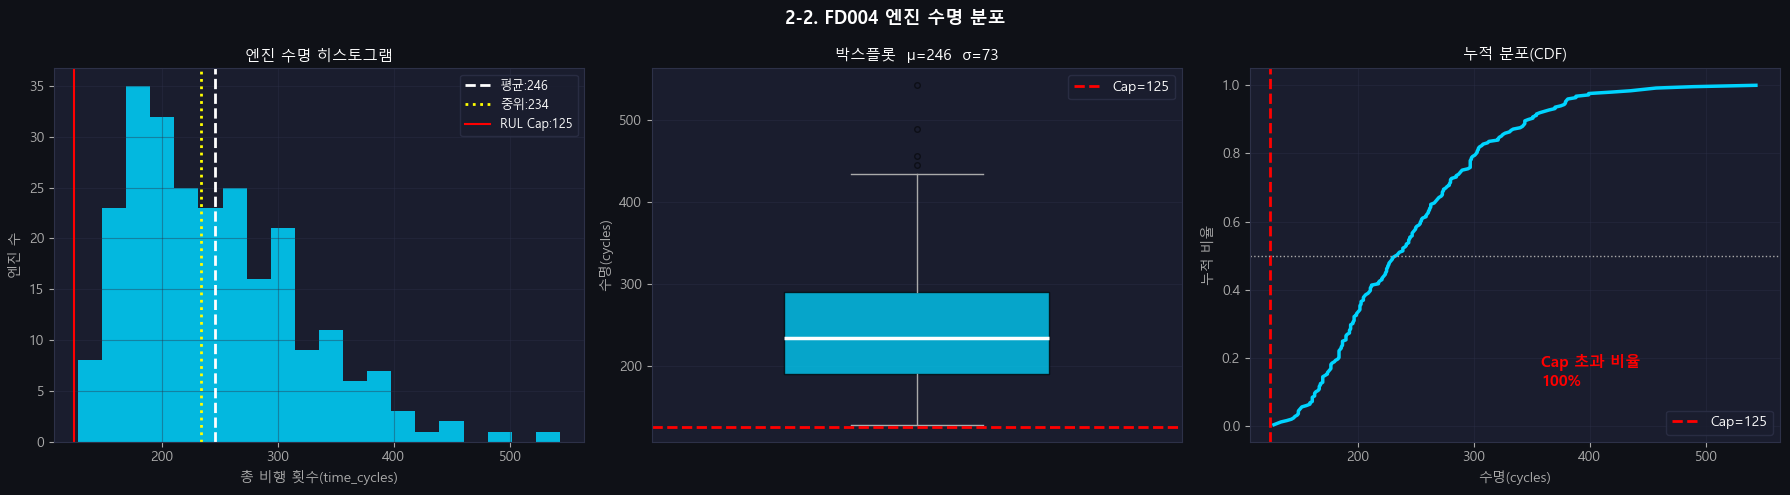


엔진 수명 통계:
  평균=246.0  중위=234.0  min=128  max=543
  Cap=125 초과 엔진: 249대 (100%)

📌 100% 엔진이 수명 125 사이클 초과 → Cap=125 설정 근거


In [4]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD004 엔진 수명 분포', fontsize=13, fontweight='bold')

# 히스토그램
ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)')
ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램')
ax.legend(fontsize=9)

# 박스플롯
ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([])
ax.legend()

# CDF
ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)')
ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 100% 엔진이 수명 {RUL_CAP} 사이클 초과 → Cap={RUL_CAP} 설정 근거')

### 📊 2-2. 엔진 수명 분포 결과

---

#### 수명 통계 요약
| 항목 | FD001 | FD002 | FD003 | FD004 |
|------|-------|-------|-------|-------|
| 평균 | 206 | 207 | 247 | **246** |
| 중위 | 199 | 199 | 220 | **234** |
| 최솟값 | 128 | 128 | 145 | **128** |
| 최댓값 | 362 | 378 | 525 | **543** |
| 표준편차 | - | - | 86 | **73** |
| Cap=125 초과 비율 | 100% | 100% | 100% | **100%** |

---

#### 수명 통계 요약
| 항목 | FD004 |
|------|-------|
| 평균 | 246 |
| 중위 | 234 |
| 최솟값 | 128 |
| 최댓값 | 543 |
| 표준편차 | 73 |
| Cap=125 초과 비율 | 100% |

---

#### 🔑 핵심 결론
> **모든 엔진(100%)의 수명이 125사이클 초과 → Cap=125 설정 근거 유지**  
> **평균 수명 246사이클로 FD002(207)보다 길고 FD003(247)과 거의 동일**  
> → 운전조건 6가지 + 고장모드 2가지 혼재로 수명 분산(σ=73)이 비교적 큰 편  
> → Cap 상향 실험(130, 135, 140)은 FD003 실험 결과와 동일하게 125가 최적으로 예상되나 베이스라인 후 확인

#### 히스토그램 해석
- 150~300 구간에 엔진이 가장 많이 분포
- 평균(246) > 중위(234) → 오른쪽으로 꼬리가 긴 분포 (우편향)
- FD002(평균 207)보다 평균 수명이 약 39사이클 더 길고 최댓값(543)도 가장 큼
- FD003(평균 247)과 거의 동일한 수명 분포 → 고장 모드 2가지 혼재의 영향으로 추정
- 빨간 수직선(Cap=125): 모든 엔진이 이 선 오른쪽에 위치

---

#### 🔑 핵심 결론
> **모든 엔진(100%)의 수명이 125사이클 초과 → Cap=125 설정 근거 유지**  
> **FD002 대비 평균 수명 39사이클 증가, 최댓값 165사이클 증가** 
> **평균 수명 246사이클로 FD002(207)보다 길고 FD003(247)과 거의 동일**  
> → 운전조건 6가지 + 고장모드 2가지 혼재로 수명 분산(σ=73)이 혼재로 열화 속도가 다양해 수명 분산이 더 큰 것으로 추정   
> **FD003과 수명 분포가 매우 유사 (평균 247 vs 246, σ 86 vs 73)**  
> → 운전조건 차이(1가지 vs 6가지)보다 고장 모드(2가지)가 수명 분포에 더 큰 영향을 미치는 것으로 추정

> → Cap 상향 실험(130, 135, 140)은 FD003 실험 결과와 동일하게 125가 최적으로 예상되나 베이스라인 후 확인  

---
## 2-3. 센서 분포 & 이상치 (전처리 전)

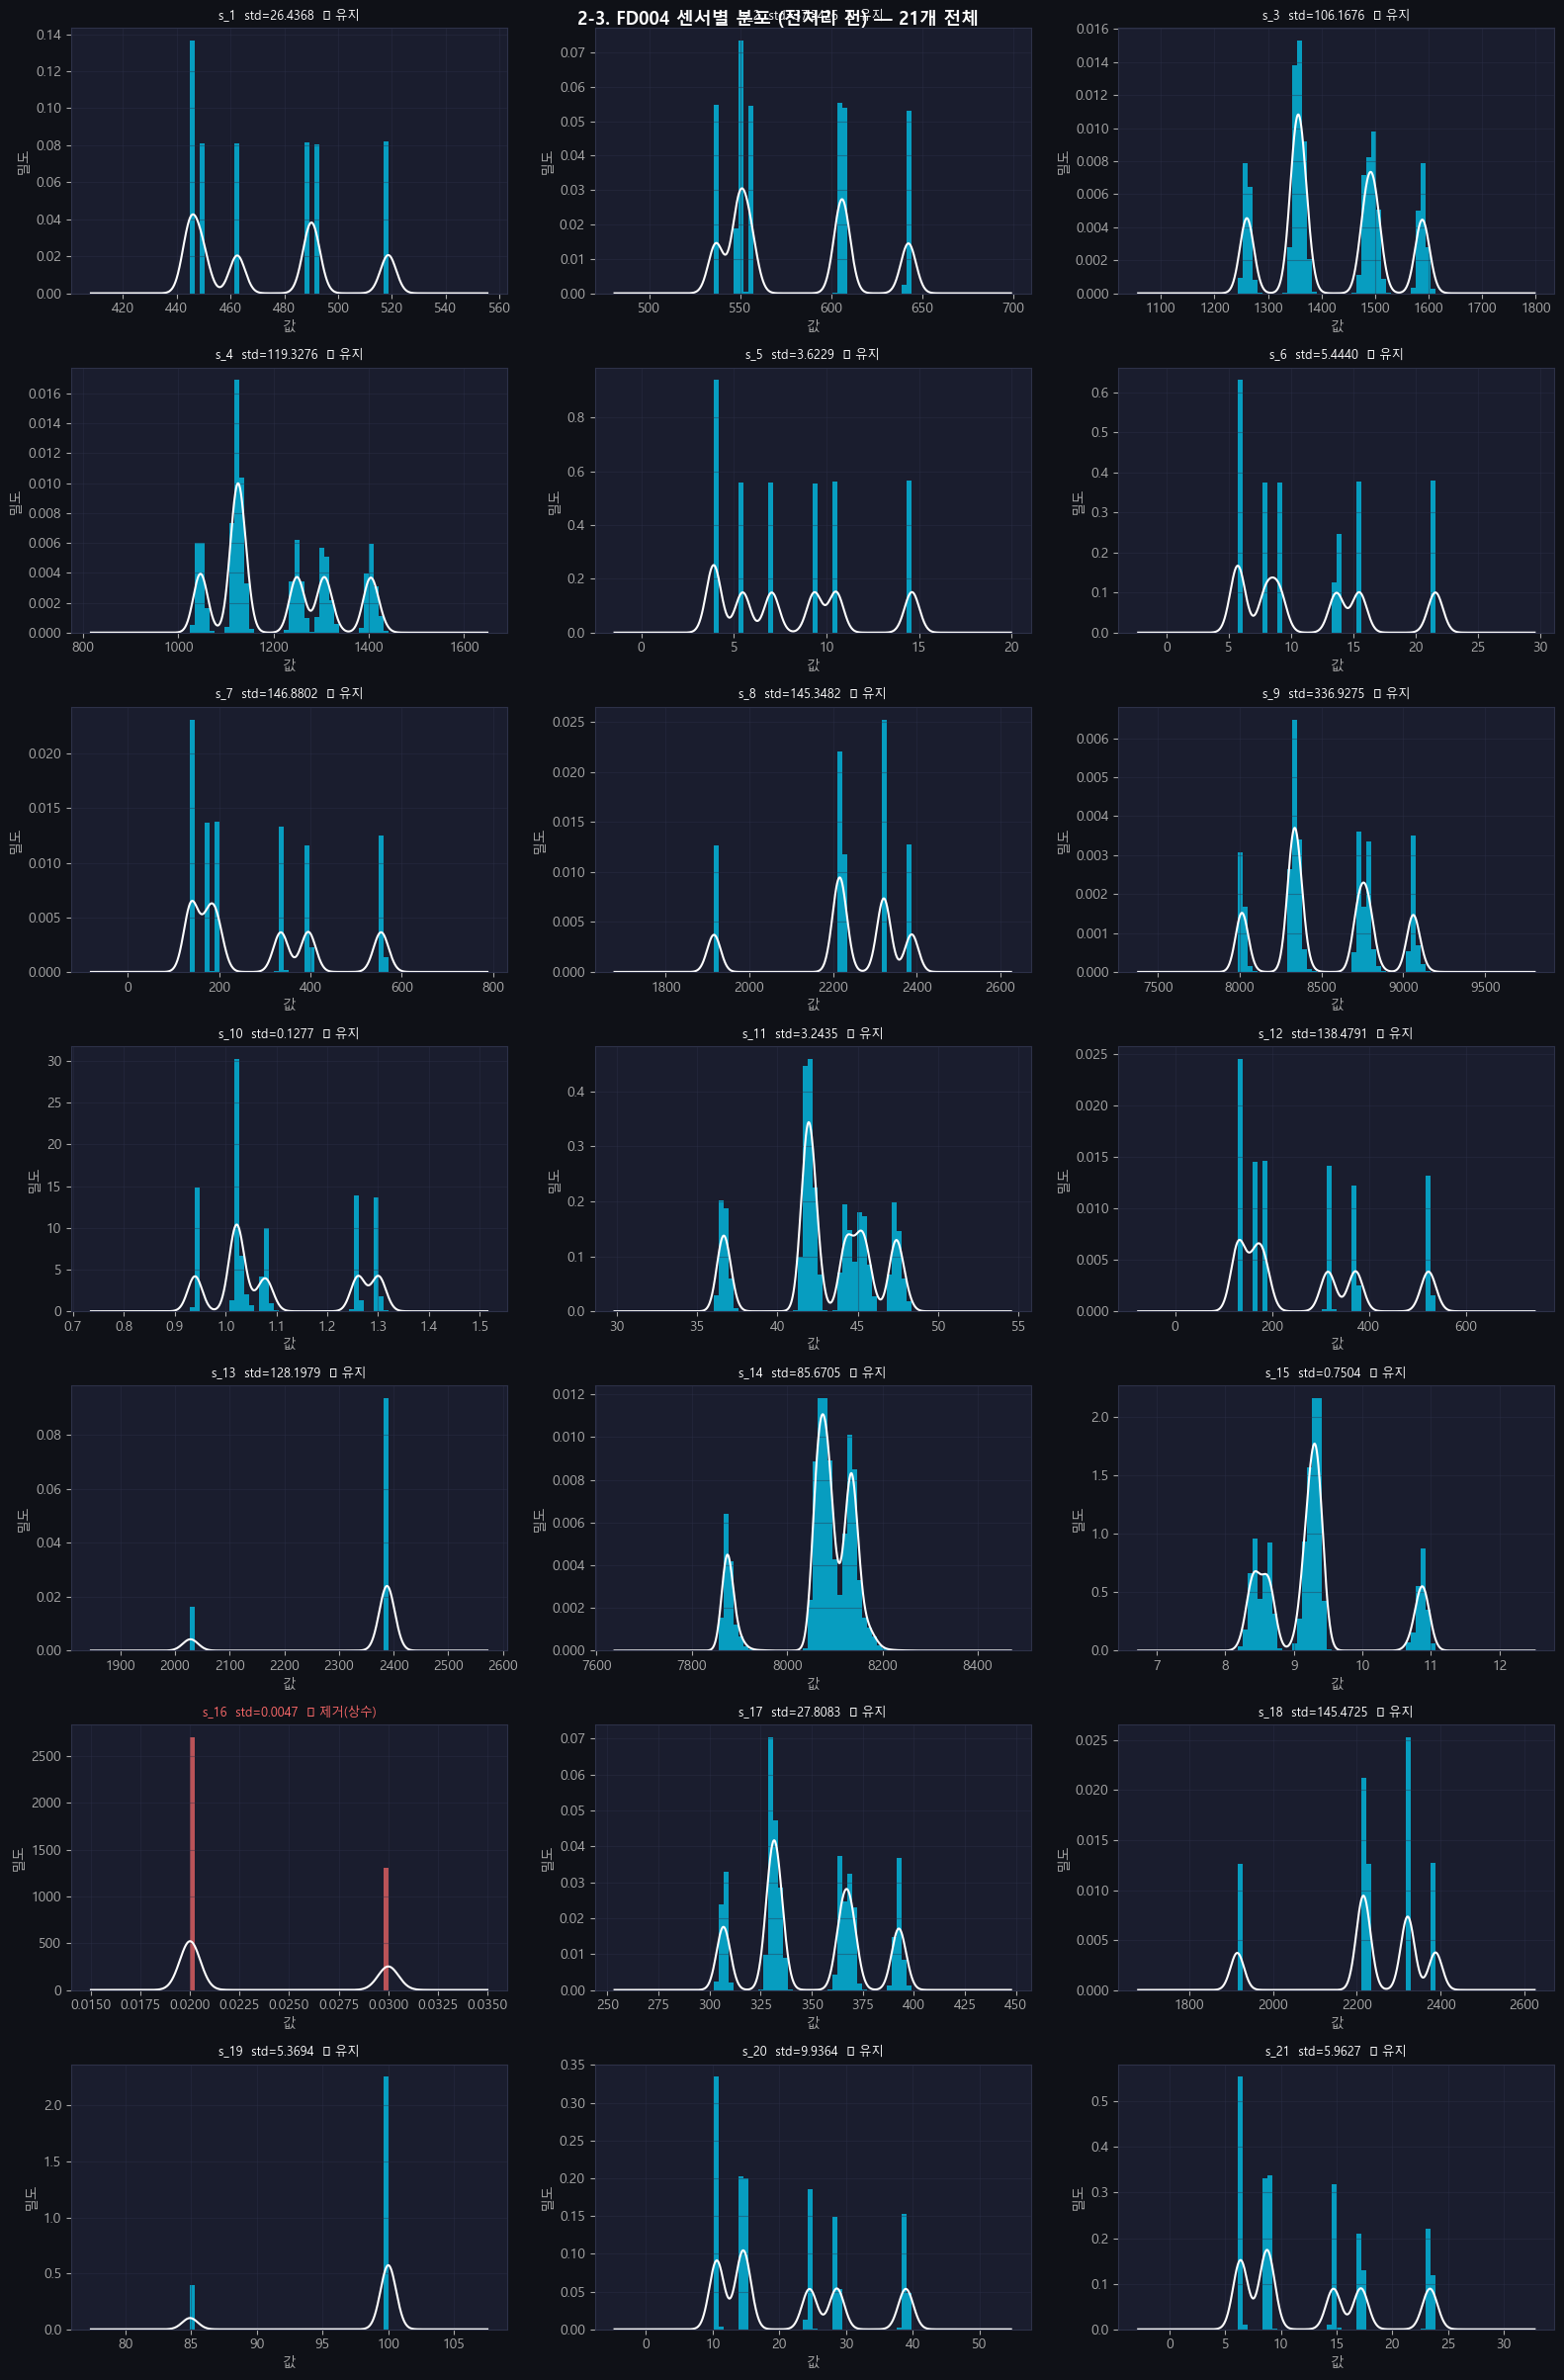

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
7,s_8,9139,14.921
10,s_11,3102,5.065
12,s_13,11546,18.851
13,s_14,9162,14.959
14,s_15,9139,14.921
17,s_18,9139,14.921
18,s_19,9139,14.921


In [5]:
# 21개 센서 분포 (히스토그램 + KDE)
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. FD004 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')
for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try:
        data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else '✅ 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# IQR 이상치 탐지
print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero):
    display(nonzero)
else:
    print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 📊 2-3. 센서별 분포 & 이상치 탐지 결과

---

#### 센서 분포 시각화 해석

**상수 센서 후보 (빨간색, std < CONST_THR)**
| 센서 | std | 판정 |
|------|-----|------|
| s_16 | 0.0047 | ⚠️ 제거 후보 (통계 검정 후 확정) |

> 📌 s_1, s_5, s_18, s_19는 std 기준 자동 제거 대상이나  
> FD004에서는 운전조건 영향으로 std > CONST_THR로 나타남 → 유지로 표시됨  
> → 3장 통계 검정에서 RUL 상관계수 및 열화 트렌드 확인 후 제거 여부 결정 예정

**주목할 분포 특이사항**
- **멀티모달 분포 확인** → 대부분 센서에서 봉우리가 여러 개 → 운전조건 6가지 혼재 영향 (FD002와 동일 패턴)
- s_5, s_6, s_7, s_12, s_20, s_21: 봉우리가 뚜렷하게 분리 → 조건 간 센서값 범위 차이 큼
- s_10: 봉우리 여러 개이나 범위 좁음 (0.7~1.5) → 운전조건 영향 포함
- s_16: 단봉 뾰족한 분포 → 완전 상수에 가까움 → 제거 후보
- s_17: 이산적 다봉분포 → 정수값으로 분포 (FD001/003과 동일 패턴)
- s_19: 단봉 뾰족한 분포 → 거의 100에 집중 → 상수 여부 결정 1에서 재확인

---

#### IQR 이상치 탐지 결과

**이상치 비율 높은 센서**
| 센서 | 이상치 수 | 비율(%) | 비고 |
|------|---------|---------|------|
| s_13 | 11,546 | 18.851 | ⚠️ 가장 높음 |
| s_14 | 9,162 | 14.959 | ⚠️ 주목 |
| s_8 | 9,139 | 14.921 | ⚠️ 주목 |
| s_15 | 9,139 | 14.921 | ⚠️ 주목 |
| s_18 | 9,139 | 14.921 | ⚠️ 주목 |
| s_19 | 9,139 | 14.921 | ⚠️ 주목 |
| s_11 | 3,102 | 5.065 | ⚠️ 주목 |

---

#### 🔑 핵심 결론
> **s_16만 std 기준 상수 센서로 탐지됨 → 제거 후보 (3장 통계 검정 후 최종 결정)**  
> **s_18, s_19는 이상치 비율 14.9%로 탐지됐으나 분포상 거의 상수에 가까움**  
> → 3장 통계 검정에서 최종 제거 여부 결정 예정 
> **IQR 이상치는 진짜 이상치가 아님**  
> → IQR이 단일 분포를 가정하기 때문에 멀티모달 분포에서 다른 조건의 정상값을 이상치로 오탐지한 것  
> → s_18, s_19처럼 상수에 가까운 센서는 IQR≈0이라 정상값도 이상치로 오탐지됨  
> → 제거 불필요, 3장 통계 검정에서 센서별 최종 제거 여부 결정 예정

---
## 2-4. 센서 간 상관관계 히트맵 (전처리 전)

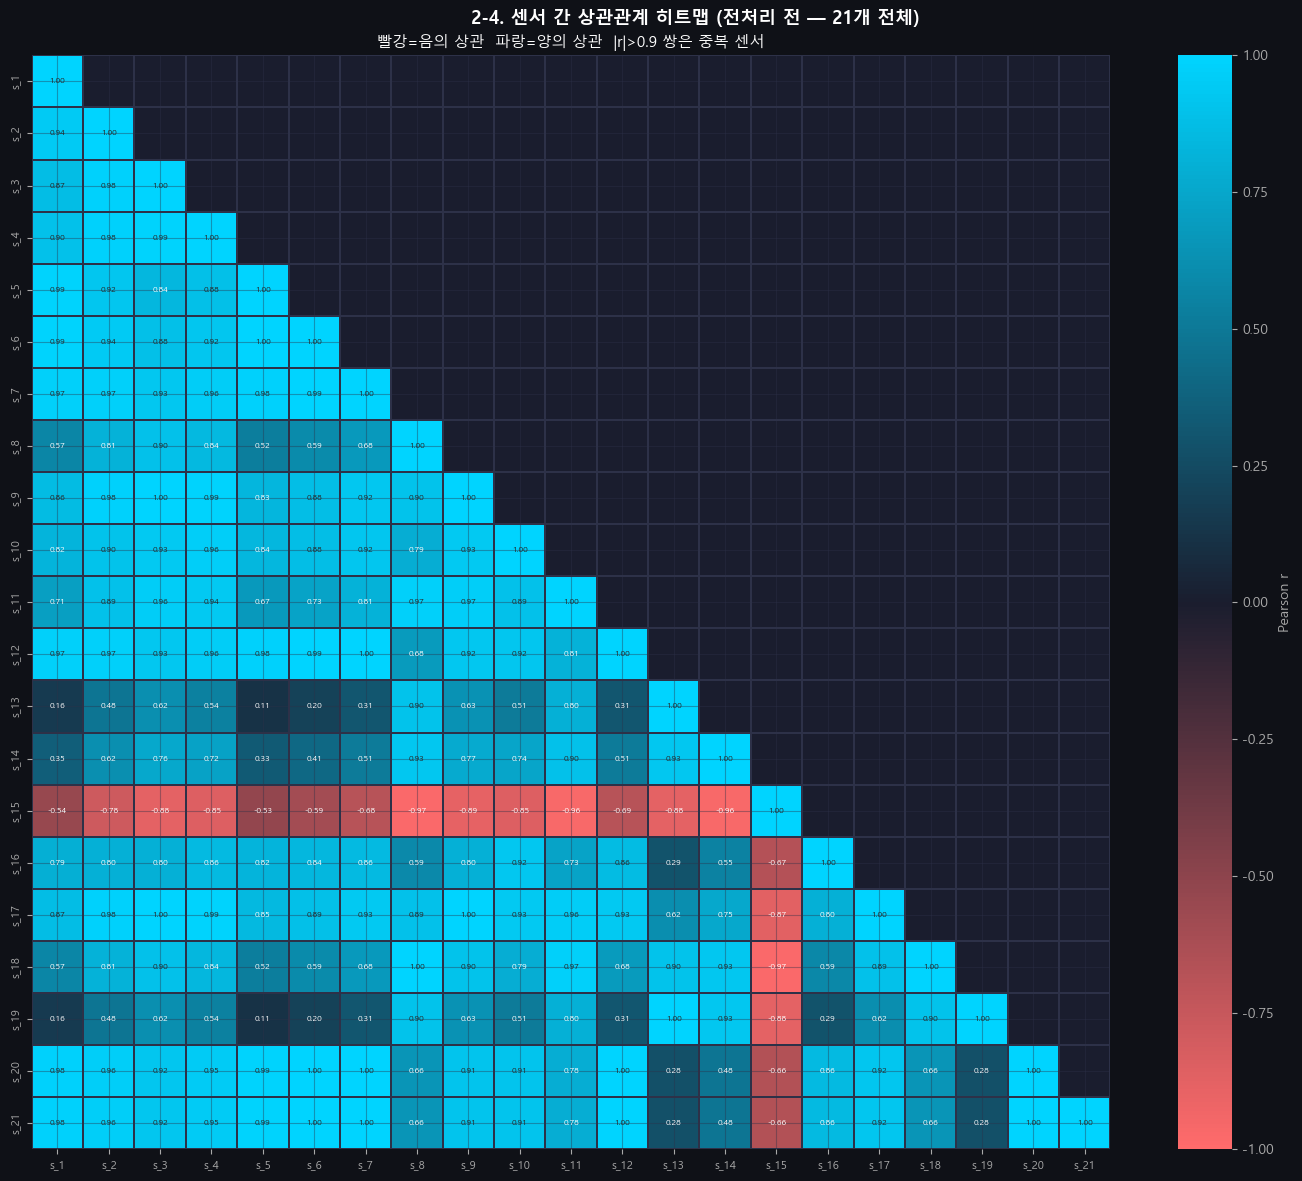

--- 고상관 센서 쌍 (|r| > 0.9) ---


,센서A,센서B,r
0,s_1,s_2,0.944
1,s_1,s_5,0.987
2,s_1,s_6,0.987
3,s_1,s_7,0.973
4,s_1,s_12,0.973
...,...,...,...
82,s_15,s_18,-0.969
83,s_17,s_20,0.919
84,s_17,s_21,0.919
85,s_18,s_19,0.903


In [6]:

cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# 고상관 쌍
print('--- 고상관 센서 쌍 (|r| > 0.9) ---')
pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
if pairs:
    display(pd.DataFrame(pairs))
else:
    print('  해당 없음')

### 📊 2-4. 센서 간 상관관계 히트맵 결과

---

#### 고상관 센서 쌍 요약
- 고상관 쌍 (|r| > 0.9): **87개**
- FD001(1개), FD003(3개) 대비 급증 → FD002(87개)와 동일한 수준

---

#### 고상관 쌍 예시 (상·하단)
| 센서A | 센서B | r | 비고 |
|-------|-------|---|------|
| s_1 | s_2 | 0.944 | 온도 센서군 공변동 |
| s_1 | s_5 | 0.987 | 운전조건 공변동 |
| s_1 | s_6 | 0.987 | 운전조건 공변동 |
| s_1 | s_7 | 0.973 | 운전조건 공변동 |
| s_1 | s_12 | 0.973 | 운전조건 공변동 |
| ... | ... | ... | ... |
| s_15 | s_18 | -0.969 | 음의 상관 |
| s_17 | s_20 | 0.919 | 블리드 엔탈피↔냉각블리드 |
| s_17 | s_21 | 0.919 | 동일 |
| s_18 | s_19 | 0.903 | 운전조건 공변동 |
| s_20 | s_21 | 1.000 | 거의 동일한 센서 |

---

#### 히트맵 패턴 해석
- 전체적으로 파란색(양의 상관) 지배 → 운전조건 변화 시 대부분 센서가 동시에 움직임
- s_15 행/열: 빨간색(음의 상관) 뚜렷 → BPR 바이패스 비율이 압력/속도 센서와 반비례
- s_20 ↔ s_21: r=1.000 → 두 센서가 완전히 동일한 정보

---

#### 🔑 핵심 결론
> **고상관 쌍 87개 → FD001(1개), FD003(3개) 대비 급증, FD002(87개)와 동일**  
> → 운전조건 6가지 혼재로 인한 조건 공변동이 원인  
> → 열화 신호가 아닌 조건 영향이므로 센서 추가 제거 불필요  
> → 클러스터별 정규화 후 조건 영향 제거 시 상관관계가 낮아질 것으로 예상  
> **s_20 ↔ s_21 r=1.000 → 완전히 동일한 정보 포함**  
> → 중복 센서이나 별도 제거 없이 모델에서 처리 (FD002와 동일 방침)

---
## 2-5. 센서별 열화 트렌드 (전처리 전)

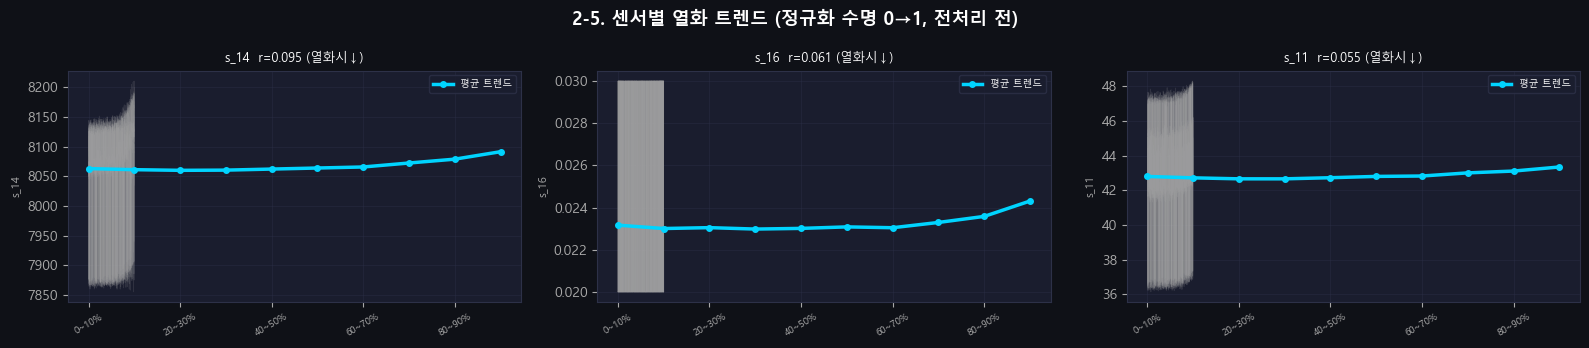

📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)


In [7]:
# 정규화 수명축(0=새것, 1=고장 직전)으로 평균 트렌드 확인
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# 유의미한 트렌드 센서만 표시 # 기준을 FD001과 다르게 0.1 → 0.05로 낮추기)
corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.05].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]

if len(trend_sensors) == 0:
    print('📌 FD004는 조건 영향으로 유의미한 트렌드 센서 없음 → 클러스터별 정규화 후 재확인 예정')
else:
    n_cols = 3
    n_rows = (len(trend_sensors)+n_cols-1)//n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
    fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

    x_pos = range(len(labels))
    sample_units = tr_trend['unit_nr'].unique()[:15]

    for ax, s in zip(axes.flat, trend_sensors):
        for u in sample_units:
            sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
            ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
        ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4, label='평균 트렌드')
        r = corr_with_life[s]
        direction = '열화시↑' if r<0 else '열화시↓'
        ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
        ax.set_xticks(x_pos[::2])
        ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
        ax.set_ylabel(s, fontsize=8)
        ax.legend(fontsize=7)

    for ax in axes.flat[len(trend_sensors):]:
        ax.set_visible(False)

    plt.tight_layout(); plt.show()
    print('📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)')

### 📊 2-5. 센서별 열화 트렌드 결과

---

#### 유의미한 트렌드 센서 (|r| > 0.05, 상위 9개 중 탐지된 것)

| 센서 | r | 방향 | 물리적 의미 | 비고 |
|------|---|------|------------|------|
| s_14 | 0.095 | 열화시↓ | NRc 보정 코어속도 | 트렌드 완만 |
| s_16 | 0.061 | 열화시↓ | farB 버너 연료공기비 | 트렌드 완만 |
| s_11 | 0.055 | 열화시↓ | Ps30 정적압력 | 트렌드 완만 |

---

#### 트렌드 패턴 해석

- **|r| 값이 전반적으로 매우 낮음 (0.05~0.10)**
  → 운전조건 6가지 + 고장모드 2가지 혼재로 트렌드가 조건 영향에 묻혀 불명확하게 나타남
  → FD002와 동일한 패턴
- **3개 센서 모두 열화시↓ 방향**
  → 수명이 다할수록 센서값이 감소하는 패턴
- **개별 궤적(회색) 분산이 매우 큼**
  → 초반 0~10% 구간에서 엔진별 산포가 극심 → 운전조건 혼재 영향
- **평균 트렌드 곡선이 거의 수평에 가까움**
  → 전처리 전 상태에서는 열화 신호가 조건 노이즈에 묻혀 있는 상태

---

#### 🔑 핵심 결론
> **전처리 전 상태에서 유의미한 트렌드 센서가 3개로 매우 적음**  
> → FD001(9개), FD003(9개)과 달리 운전조건 혼재로 트렌드 포착이 어려운 상태  
> → FD002와 동일하게 클러스터별 정규화 후 트렌드 재확인 예정  
> **r값이 낮다고 해서 해당 센서가 열화 정보가 없는 것은 아님**  
> → 조건 영향 제거 후 트렌드가 뚜렷하게 나타날 가능성 높음  
> → 8-4 열화 트렌드 전후 비교에서 정규화 효과 확인 예정

## 2-6. RUL 상관계수 (전처리 전)

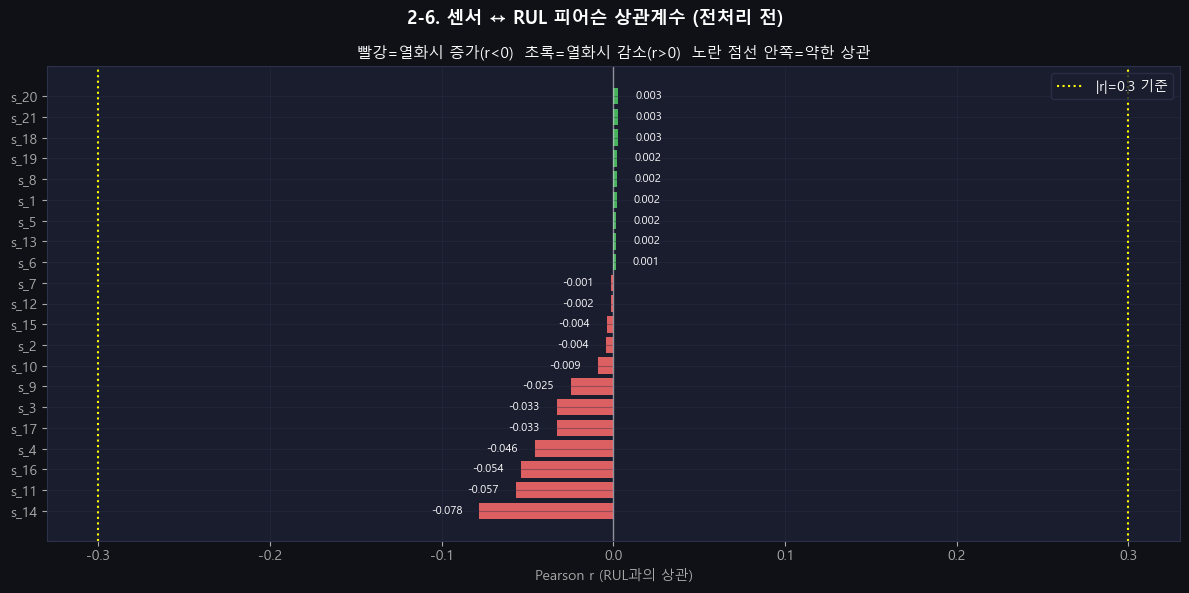

|r|>0.3 고상관 센서: 0개


In [8]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-6. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시 증가(r<0)  초록=열화시 감소(r>0)  노란 점선 안쪽=약한 상관')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s,r in high_corr.sort_values(key=abs,ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")[:30]}')

### 📊 2-6. 센서 ↔ RUL 상관계수 결과

---

#### |r| > 0.3 고상관 센서
- **해당 없음 (0개)**
- 모든 센서가 노란 점선(-0.3 ~ 0.3) 안쪽에 위치

---

#### 전체 센서 상관계수 요약

| 센서 | r | 방향 | 비고 |
|------|---|------|------|
| s_14 | -0.078 | 열화시↑ | 가장 높은 상관 |
| s_11 | -0.057 | 열화시↑ | |
| s_16 | -0.054 | 열화시↑ | 상수 센서 후보인데 미약한 상관 존재 |
| s_4 | -0.046 | 열화시↑ | |
| s_17 | -0.033 | 열화시↑ | |
| s_3 | -0.033 | 열화시↑ | |
| s_9 | -0.025 | 열화시↑ | |
| s_10 | -0.009 | 열화시↑ | |
| s_20 | 0.003 | 열화시↓ | 거의 무관 |
| s_21 | 0.003 | 열화시↓ | 거의 무관 |

---

#### FD003 대비 비교
| 항목 | FD003 | FD004 |
|------|-------|-------|
| |r|>0.3 센서 수 | 12개 | **0개** |
| 최고 상관 센서 | s_11 (r=-0.689) | s_14 (r=-0.078) |
| 전반적 상관 수준 | 강함 | **매우 약함** |

---

#### 🔑 핵심 결론
> **전처리 전 상태에서 |r|>0.3 센서가 단 한 개도 없음**  
> → FD003(12개), FD001과 비교해 상관계수가 극도로 낮음  
> → 운전조건 6가지 혼재로 인해 RUL 신호가 조건 노이즈에 완전히 묻혀있는 상태  
> → FD002와 동일한 패턴으로 클러스터별 정규화 후 상관계수가 크게 올라갈 것으로 예상  
> **s_10, s_6의 RUL 상관이 거의 0에 가까움**  
> → FD003에서 s_10 r=-0.363이었던 것과 대조적  
> → 운전조건 영향으로 열화 신호가 희석된 것으로 추정  
> → 통계 검정 및 클러스터별 분석에서 재확인 예정

---
## 2-7. 운전 조건 분포 & 군집화

FD004는 운전 조건이 6가지로 구성되어 있으며, 각 조건은 고도(setting_1), 마하수(setting_2), 스로틀 각도(TRA, setting_3) 조합으로 정의됨.

**분석 목적**
- setting 3개 컬럼의 실제 분포를 시각화하여 군집 구조 확인
- 엘보우 차트로 k=6이 적절한지 근거 확인
- K-means(k=6) 결과 시각화로 클러스터가 명확히 분리되는지 검증

**왜 중요한가**
- 2-3에서 확인한 멀티모달 분포의 원인이 운전 조건임을 증명
- 이후 전처리 단계에서 클러스터별 정규화를 적용하는 근거가 됨
- setting 컬럼은 클러스터링 도구로만 사용하고 모델 입력에서는 제외

**엘보우 차트란?** K-means는 클러스터 내 데이터들이 중심점에서 얼마나 퍼져있는지를 Inertia로 측정함. k를 늘릴수록 Inertia는 계속 줄어들지만, 어느 순간부터 줄어드는 폭이 급격히 작아지는 꺾이는 지점이 생김. 이 지점이 팔꿈치(elbow)처럼 생겼다고 해서 엘보우 차트라고 부르며, 해당 지점의 k가 최적값. FD004는 실제 조건이 6개이므로 k=6에서 꺾임이 나타날 것으로 예상.

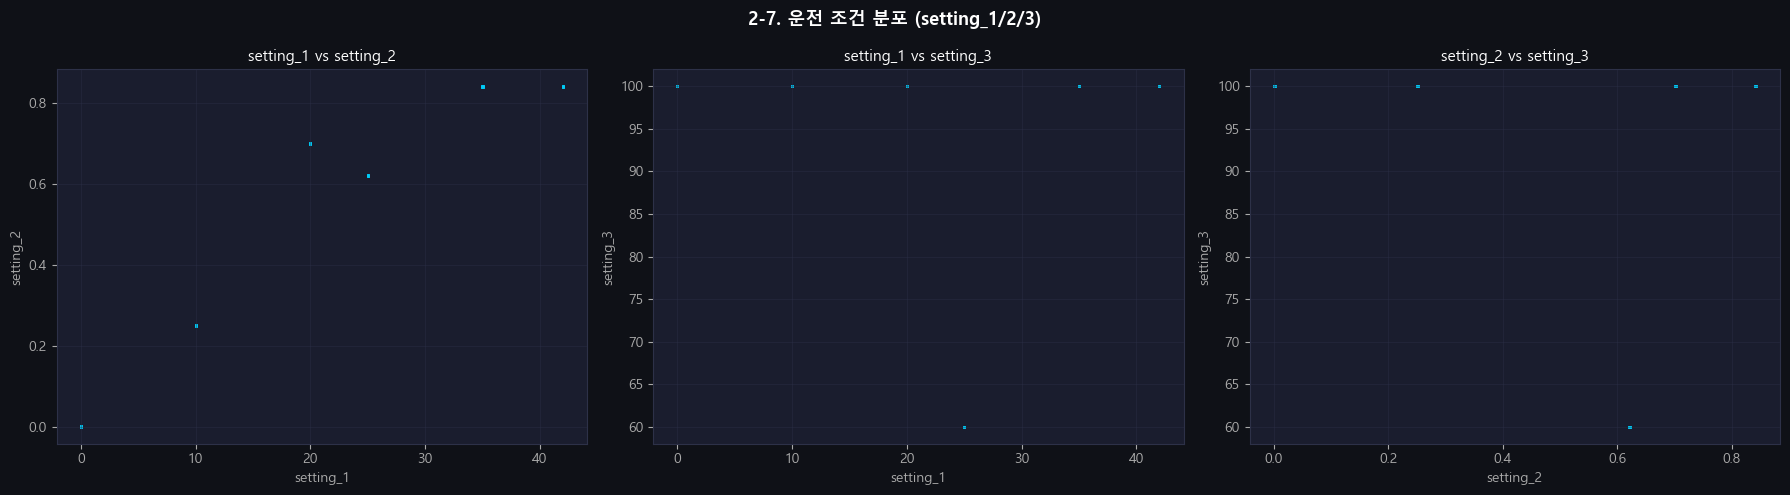

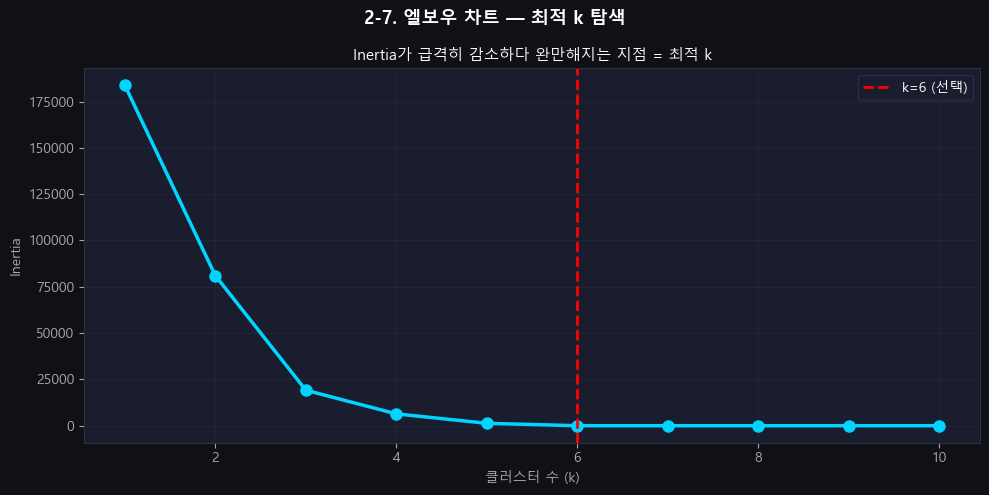

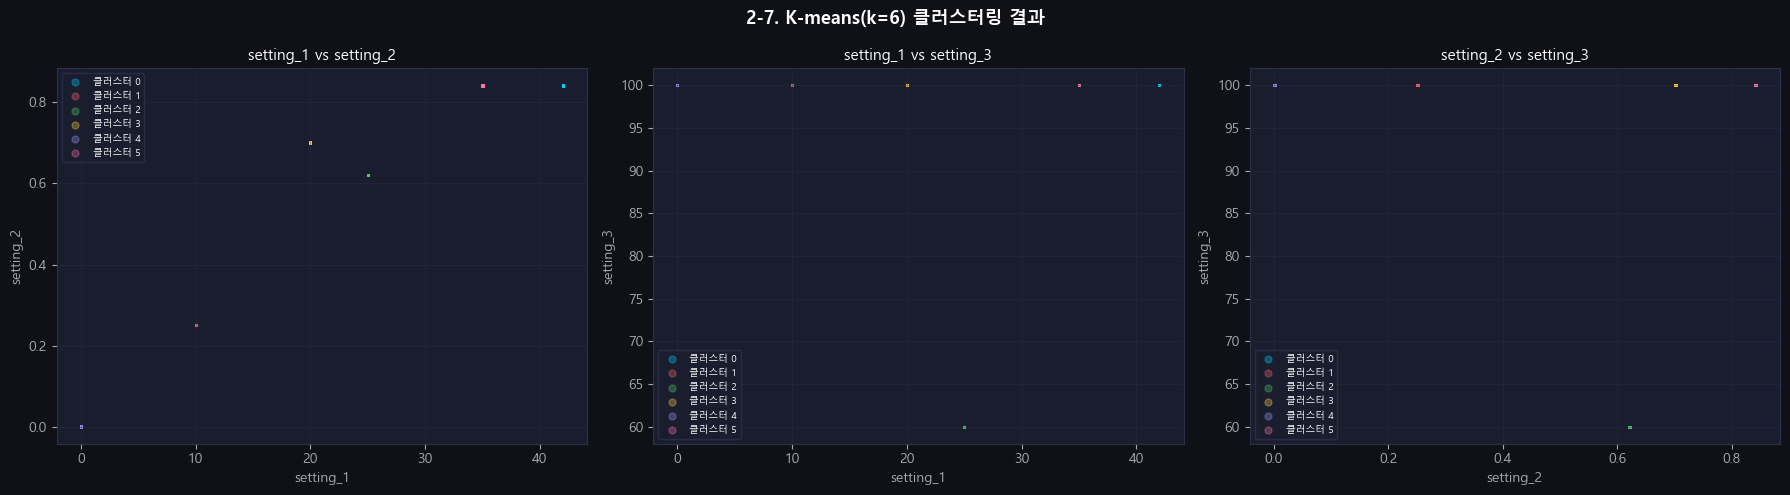

--- 클러스터별 샘플 수 ---
  클러스터 0: 15395개 (25.1%)
  클러스터 1: 9224개 (15.1%)
  클러스터 2: 9139개 (14.9%)
  클러스터 3: 9091개 (14.8%)
  클러스터 4: 9238개 (15.1%)
  클러스터 5: 9162개 (15.0%)


In [9]:
# 2-7. 운전 조건 분포 & 군집화
# (StandardScaler, KMeans는 환경설정에서 임포트 완료)

# ① setting 산점도
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-7. 운전 조건 분포 (setting_1/2/3)', fontsize=13, fontweight='bold')

pairs = [('setting_1','setting_2'), ('setting_1','setting_3'), ('setting_2','setting_3')]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(train_raw[x], train_raw[y], color=C[0], alpha=0.1, s=1)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

plt.tight_layout(); plt.show()

# ② 엘보우 차트
op_data = train_raw[OP_COLS].values
scaler_op = StandardScaler()
op_scaled = scaler_op.fit_transform(op_data)

inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(op_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('2-7. 엘보우 차트 — 최적 k 탐색', fontsize=13, fontweight='bold')
ax.plot(K_range, inertias, color=C[0], lw=2.5, marker='o', markersize=8)
ax.axvline(6, color='red', ls='--', lw=2, label='k=6 (선택)')
ax.set_xlabel('클러스터 수 (k)'); ax.set_ylabel('Inertia')
ax.set_title('Inertia가 급격히 감소하다 완만해지는 지점 = 최적 k')
ax.legend()
plt.tight_layout(); plt.show()

# ③ k=6 클러스터링 결과 시각화
km_eda = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels_eda = km_eda.fit_predict(op_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-7. K-means(k=6) 클러스터링 결과', fontsize=13, fontweight='bold')

for ax, (x, y) in zip(axes, pairs):
    for c in range(N_CLUSTERS):
        mask = cluster_labels_eda == c
        ax.scatter(train_raw[x][mask], train_raw[y][mask],
                   color=C[c], alpha=0.3, s=1, label=f'클러스터 {c}')
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
    ax.legend(fontsize=7, markerscale=5)

plt.tight_layout(); plt.show()

# 클러스터별 샘플 수
cluster_counts = pd.Series(cluster_labels_eda).value_counts().sort_index()
print('--- 클러스터별 샘플 수 ---')
for c, cnt in cluster_counts.items():
    print(f'  클러스터 {c}: {cnt}개 ({cnt/len(cluster_labels_eda)*100:.1f}%)')

### 📊 2-7. 운전 조건 분포 & 군집화 결과

---

#### ① 운전 조건 분포 산점도
- setting_1(고도) vs setting_2(마하수) 산점도에서 **6개의 점**이 명확히 분리됨
- 각 점이 하나의 운전 조건을 나타냄
- 점이 아닌 덩어리가 아니라 **이산적(discrete)** 으로 분포
  → FD004의 운전 조건은 연속적이 아니라 6가지 고정값 조합임을 의미
- FD002와 완전히 동일한 패턴 확인 ✅

---

#### ② 엘보우 차트
- k=1~5 구간: Inertia가 급격히 감소
- k=6 이후: Inertia가 거의 0에 수렴하며 완만해짐
- **k=6에서 명확한 꺾임** → k=6이 최적임을 수치로 확인
- FD004 데이터셋 설명(6가지 운전 조건)과 정확히 일치 ✅

---

#### ③ K-means(k=6) 클러스터링 결과
- 6개 클러스터가 **완벽하게 분리**됨 (겹치는 구간 없음)
- 각 클러스터가 하나의 운전 조건(고도+마하수+스로틀 조합)에 정확히 대응

---

#### ④ 클러스터별 샘플 수
| 클러스터 | 샘플 수 | 비율 |
|---------|---------|------|
| 0 | 15,395개 | 25.1% |
| 1 | 9,224개 | 15.1% |
| 2 | 9,139개 | 14.9% |
| 3 | 9,091개 | 14.8% |
| 4 | 9,238개 | 15.1% |
| 5 | 9,162개 | 15.0% |

- 클러스터 0: 25.1%로 다른 클러스터보다 약 1.7배 많음
- 클러스터 1~5: 약 15%씩 균등 분포
- FD002와 거의 동일한 비율 패턴 ✅

---

#### 🔑 핵심 결론
> **운전 조건 6개가 데이터에 명확히 존재함을 시각적·수치적으로 확인**  
> **k=6 사용 근거 확보**  
> **2-3에서 관찰한 멀티모달 분포의 원인이 이 6개 조건임이 증명됨**  
> → 전처리 단계에서 클러스터별 정규화 적용 확정  
> **FD002와 클러스터 구조 및 비율이 거의 동일**  
> → FD002의 클러스터별 MinMax 정규화 로직을 그대로 적용 가능

---
## 2-8. 클러스터별 센서 분포

**분석 목적**
- 클러스터(운전 조건)별로 센서값 범위가 얼마나 다른지 확인
- 2-3에서 관찰한 멀티모달 분포가 실제로 클러스터별로 분리되는지 검증
- 클러스터별 정규화가 필요한 이유를 시각적으로 증명

**해석 방법**
- 박스플롯으로 클러스터별 센서값 분포를 비교
- 클러스터 간 분포가 많이 다를수록 → 조건 영향이 큰 센서
- 클러스터 간 분포가 비슷할수록 → 조건 영향이 적은 센서
- 조건 영향이 큰 센서일수록 클러스터별 정규화 효과가 크게 나타남

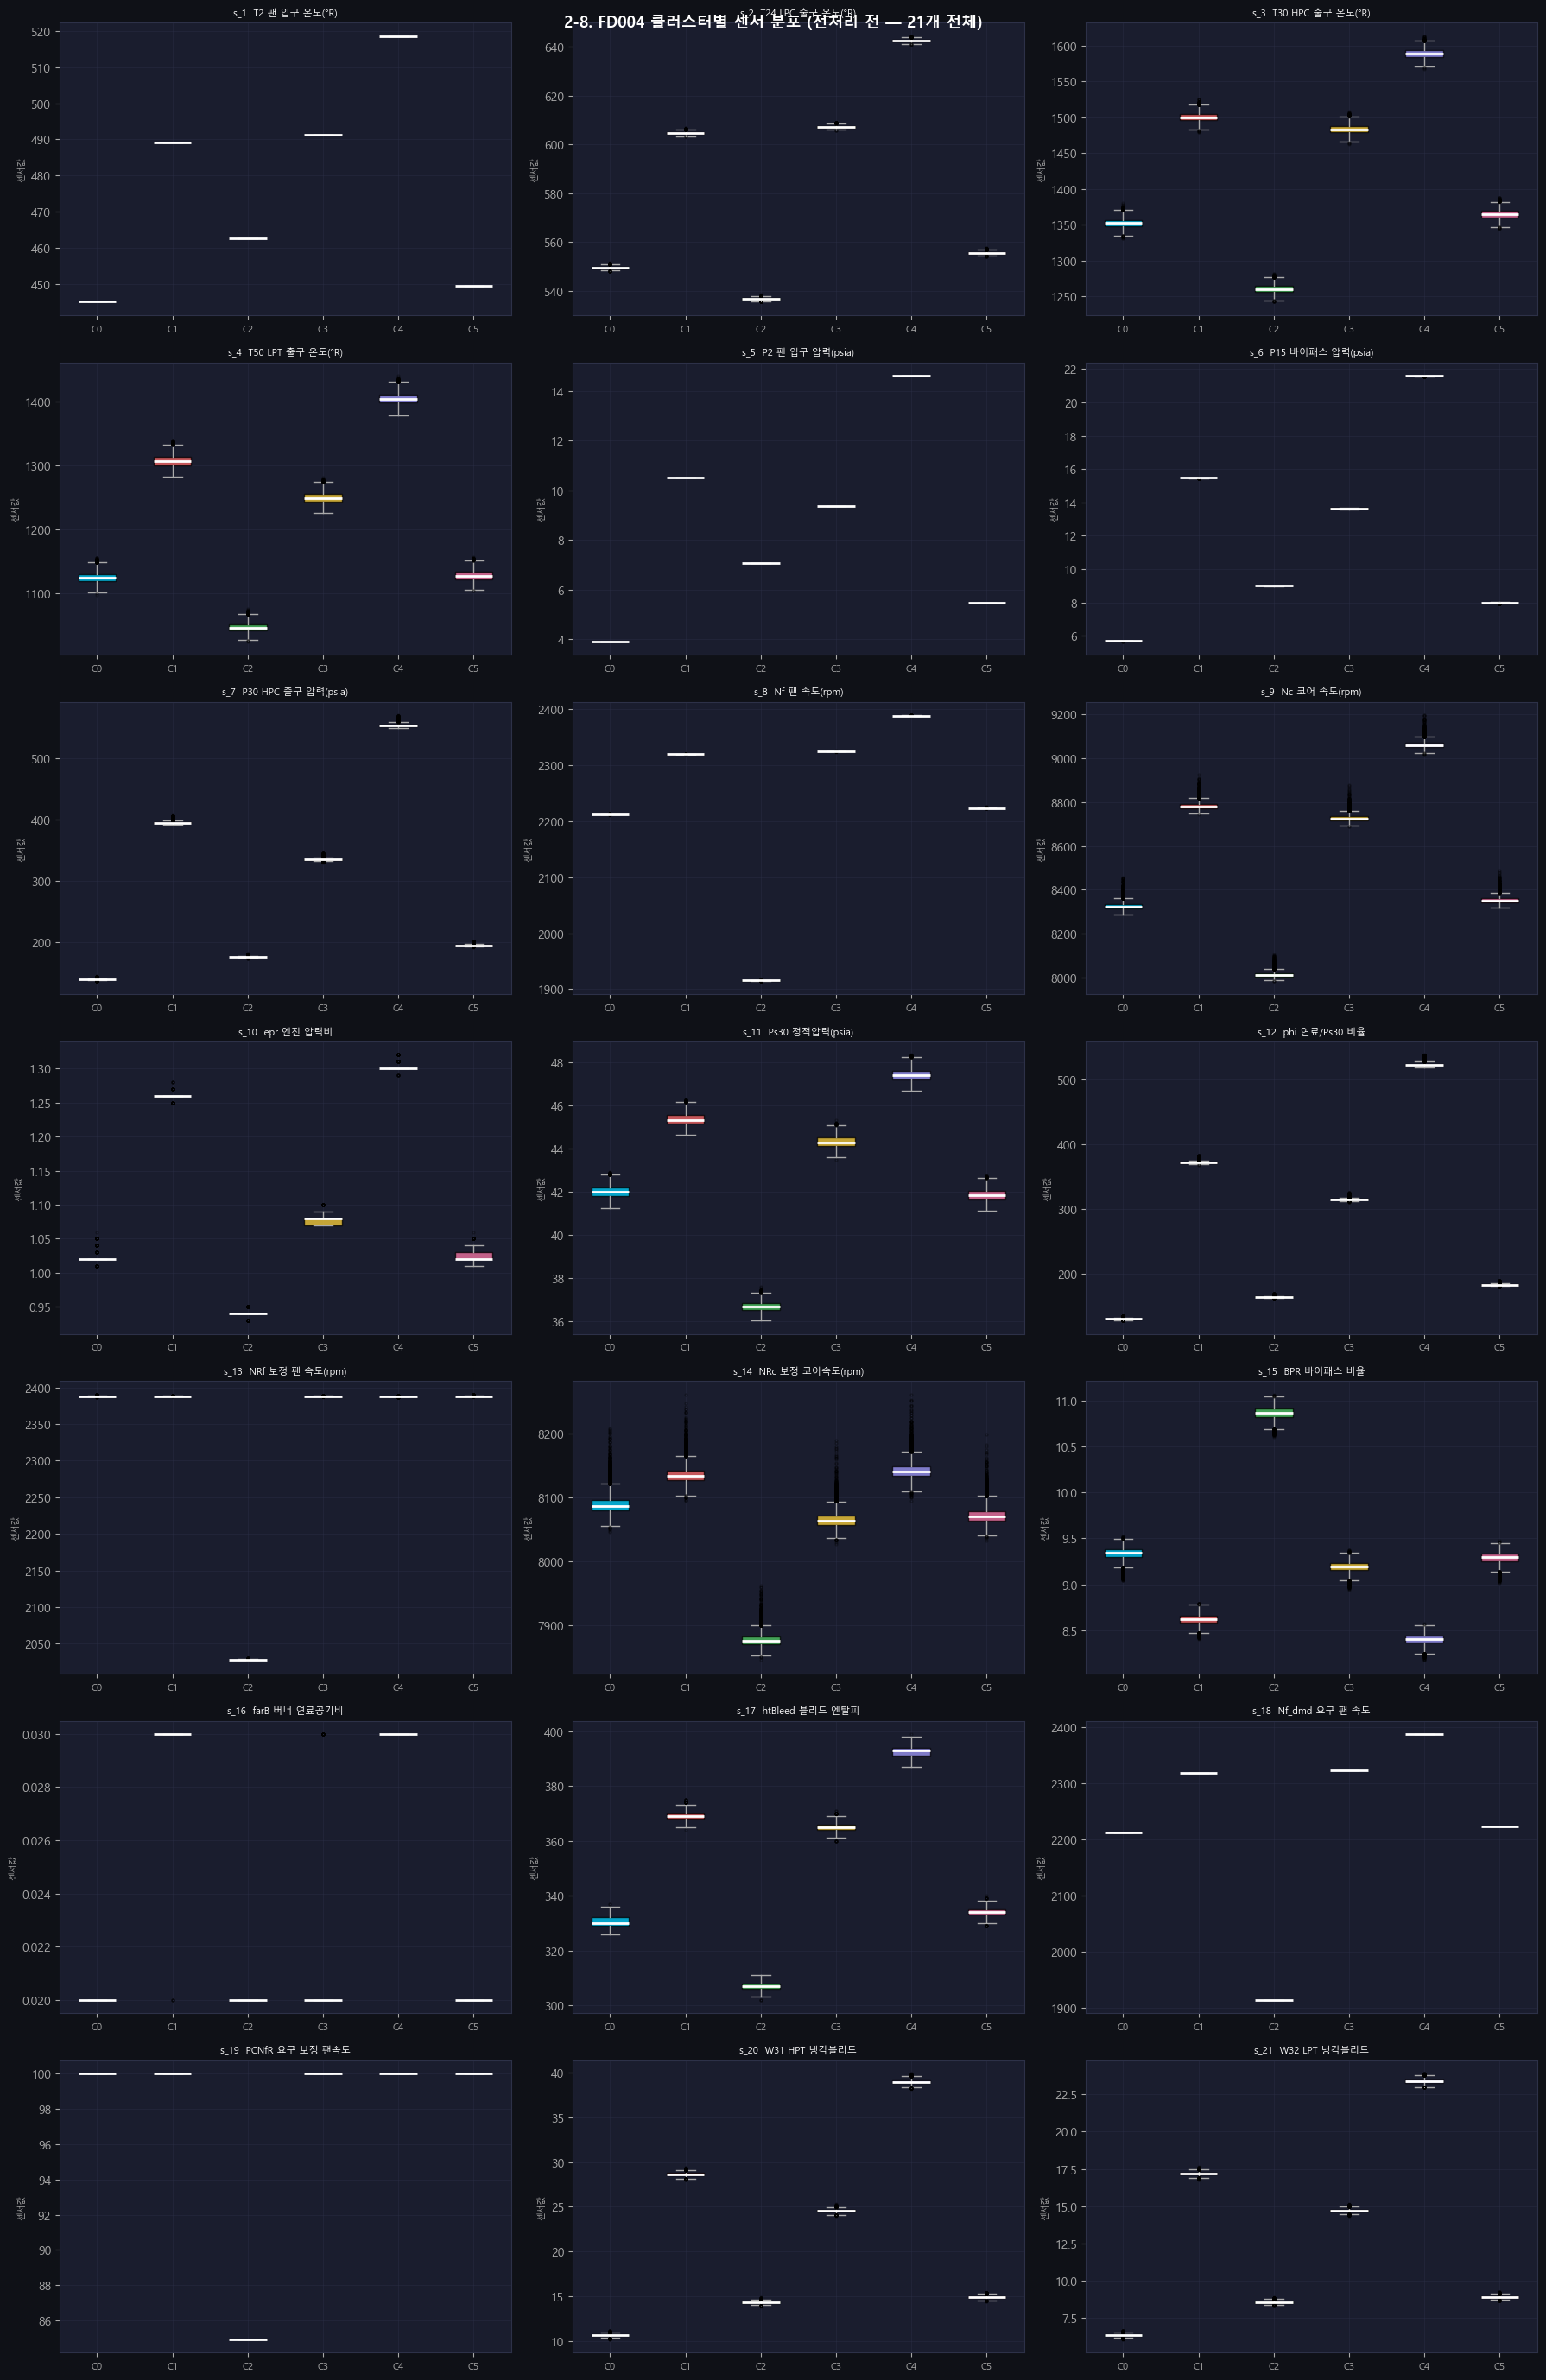

--- 클러스터 간 분포 차이 (클러스터별 평균의 std) ---
조건 영향 큰 순서 (상위 10개):


,센서,클러스터 간 평균 std,설명
0,s_9,347.7796,Nc 코어 속도(rpm)
1,s_18,153.4703,Nf_dmd 요구 팬 속도
2,s_8,153.3377,Nf 팬 속도(rpm)
3,s_7,145.9709,P30 HPC 출구 압력(psia)
4,s_12,137.6505,phi 연료/Ps30 비율
5,s_13,134.0922,NRf 보정 팬 속도(rpm)
6,s_4,122.3512,T50 LPT 출구 온도(°R)
7,s_3,109.2947,T30 HPC 출구 온도(°R)
8,s_14,88.5602,NRc 보정 코어속도(rpm)
9,s_2,37.9004,T24 LPC 출구 온도(°R)


In [10]:
# 2-8. 클러스터별 센서 분포
# EDA용 클러스터 레이블 붙이기 (전처리 전 원본 데이터 기준)
train_eda = train_raw.copy()
train_eda['cluster'] = cluster_labels_eda

# 21개 센서 전체 클러스터별 박스플롯
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
fig.suptitle('2-8. FD004 클러스터별 센서 분포 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data_by_cluster = [train_eda[train_eda['cluster']==c][s].values for c in range(N_CLUSTERS)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color='white', lw=2),
                    whiskerprops=dict(color=GRAY),
                    capprops=dict(color=GRAY),
                    flierprops=dict(marker='o', color=GRAY, markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], C[:N_CLUSTERS]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")[:20]}', fontsize=8)
    ax.set_xticklabels([f'C{c}' for c in range(N_CLUSTERS)], fontsize=8)
    ax.set_ylabel('센서값', fontsize=7)

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# 클러스터 간 분포 차이가 큰 센서 정량화
print('--- 클러스터 간 분포 차이 (클러스터별 평균의 std) ---')
diff_rows = []
for s in SENSOR_COLS:
    cluster_means = [train_eda[train_eda['cluster']==c][s].mean() for c in range(N_CLUSTERS)]
    spread = np.std(cluster_means)
    diff_rows.append({'센서': s, '클러스터 간 평균 std': round(spread, 4),
                      '설명': SENSOR_DESC.get(s, '')[:25]})
diff_df = pd.DataFrame(diff_rows).sort_values('클러스터 간 평균 std', ascending=False).reset_index(drop=True)
print('조건 영향 큰 순서 (상위 10개):')
display(diff_df.head(10))

### 📊 2-8. 클러스터별 센서 분포 결과

---

#### 클러스터별 센서 분포 박스플롯 해석
- 대부분의 센서에서 클러스터별 분포가 **완전히 다른 범위**에 위치
- 특히 s_7, s_9, s_12 등은 클러스터 간 겹치는 구간이 거의 없음
- 2-3에서 관찰한 멀티모달 분포의 봉우리 = 각 클러스터의 분포임이 확인됨
- s_16은 클러스터 간 차이가 거의 없음 → 상수 센서 후보 재확인

---

#### 클러스터 간 분포 차이 (조건 영향 큰 순서 상위 10개)

| 순위 | 센서 | 클러스터 간 평균 std | 물리적 의미 |
|------|------|-------------------|------------|
| 1 | s_9 | 347.7796 | Nc 코어 속도(rpm) |
| 2 | s_18 | 153.4703 | Nf_dmd 요구 팬 속도 |
| 3 | s_8 | 153.3377 | Nf 팬 속도(rpm) |
| 4 | s_7 | 145.9709 | P30 HPC 출구 압력(psia) |
| 5 | s_12 | 137.6505 | phi 연료/Ps30 비율 |
| 6 | s_13 | 134.0922 | NRf 보정 팬 속도(rpm) |
| 7 | s_4 | 122.3512 | T50 LPT 출구 온도(°R) |
| 8 | s_3 | 109.2947 | T30 HPC 출구 온도(°R) |
| 9 | s_14 | 88.5602 | NRc 보정 코어속도(rpm) |
| 10 | s_2 | 37.9004 | T24 LPC 출구 온도(°R) |

> 📌 FD002와 동일하게 s_9가 조건 영향 가장 큰 센서로 확인됨

---

#### 🔑 핵심 결론
> **모든 센서에서 클러스터(운전 조건)별 분포가 명확히 다름**  
> **전체 데이터를 하나의 scaler로 정규화하면 조건 영향이 그대로 남음**  
> → **클러스터별 정규화 필요성이 시각적으로 완벽하게 증명됨**  
> **FD002와 조건 영향 순위 패턴이 거의 동일 → s_9, s_18, s_8 순으로 조건 영향 강함**  
> → FD002의 클러스터별 MinMax 정규화 로직 그대로 적용 근거 확보  
> **정규화 후 8-1에서 클러스터 간 분포가 맞춰지는지 재확인 예정**

---
## 2-9. 클러스터 특성 심화 분석

FD001과 달리 FD004는 운전 조건이 6가지로 구성되어 있어 단순 센서 분포 확인을 넘어 클러스터별 특성을 더 깊이 파악해야 함.

2-8에서 클러스터별 센서값 범위가 다르다는 것을 시각적으로 확인했다면, 2-9에서는 아래 세 가지를 추가로 확인함.

**2-9-1. 3D scatter (op_settings)**
- setting_1/2/3 세 축으로 3D 공간에서 클러스터가 얼마나 명확히 분리되는지 확인
- 2-7의 2D scatter보다 입체적으로 군집 구조 파악 가능

**2-9-2. 엔진별 regime 전이 heatmap**
- 한 엔진이 비행 중 6개 조건을 어떻게 오가는지 시각화
- FD004 고유의 특성: 단일 엔진이 여러 조건을 반복적으로 경험함
- x축: time_cycles / y축: 엔진 번호 / 색: 클러스터 번호
- 조건 전환이 불규칙하다면 → window 내에 여러 조건이 섞일 수 있음 → window size 결정에도 영향을 줌

**2-9-3. regime별 수명 분포**
- 클러스터별로 엔진이 경험하는 사이클 수 분포 비교
- 특정 조건에서 많이 운행한 엔진이 수명이 짧은지 확인
- 이후 2-10 Kruskal-Wallis 검정의 시각적 근거 역할

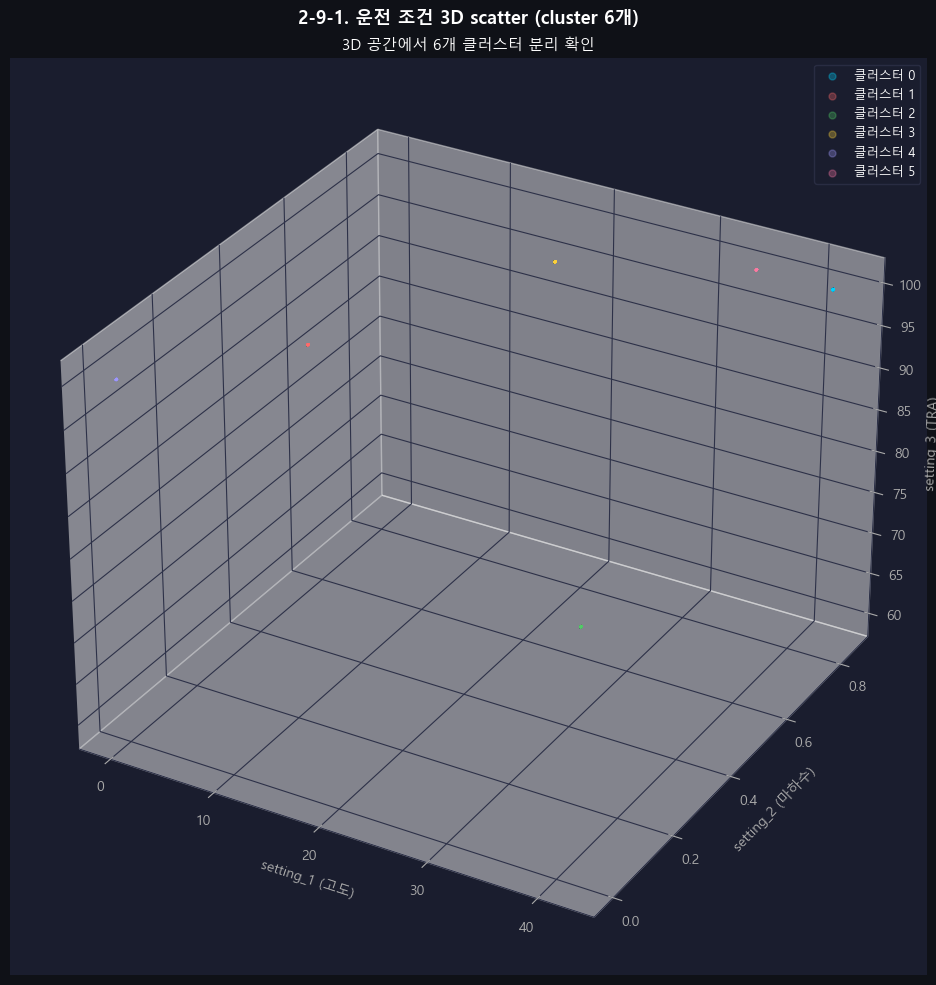

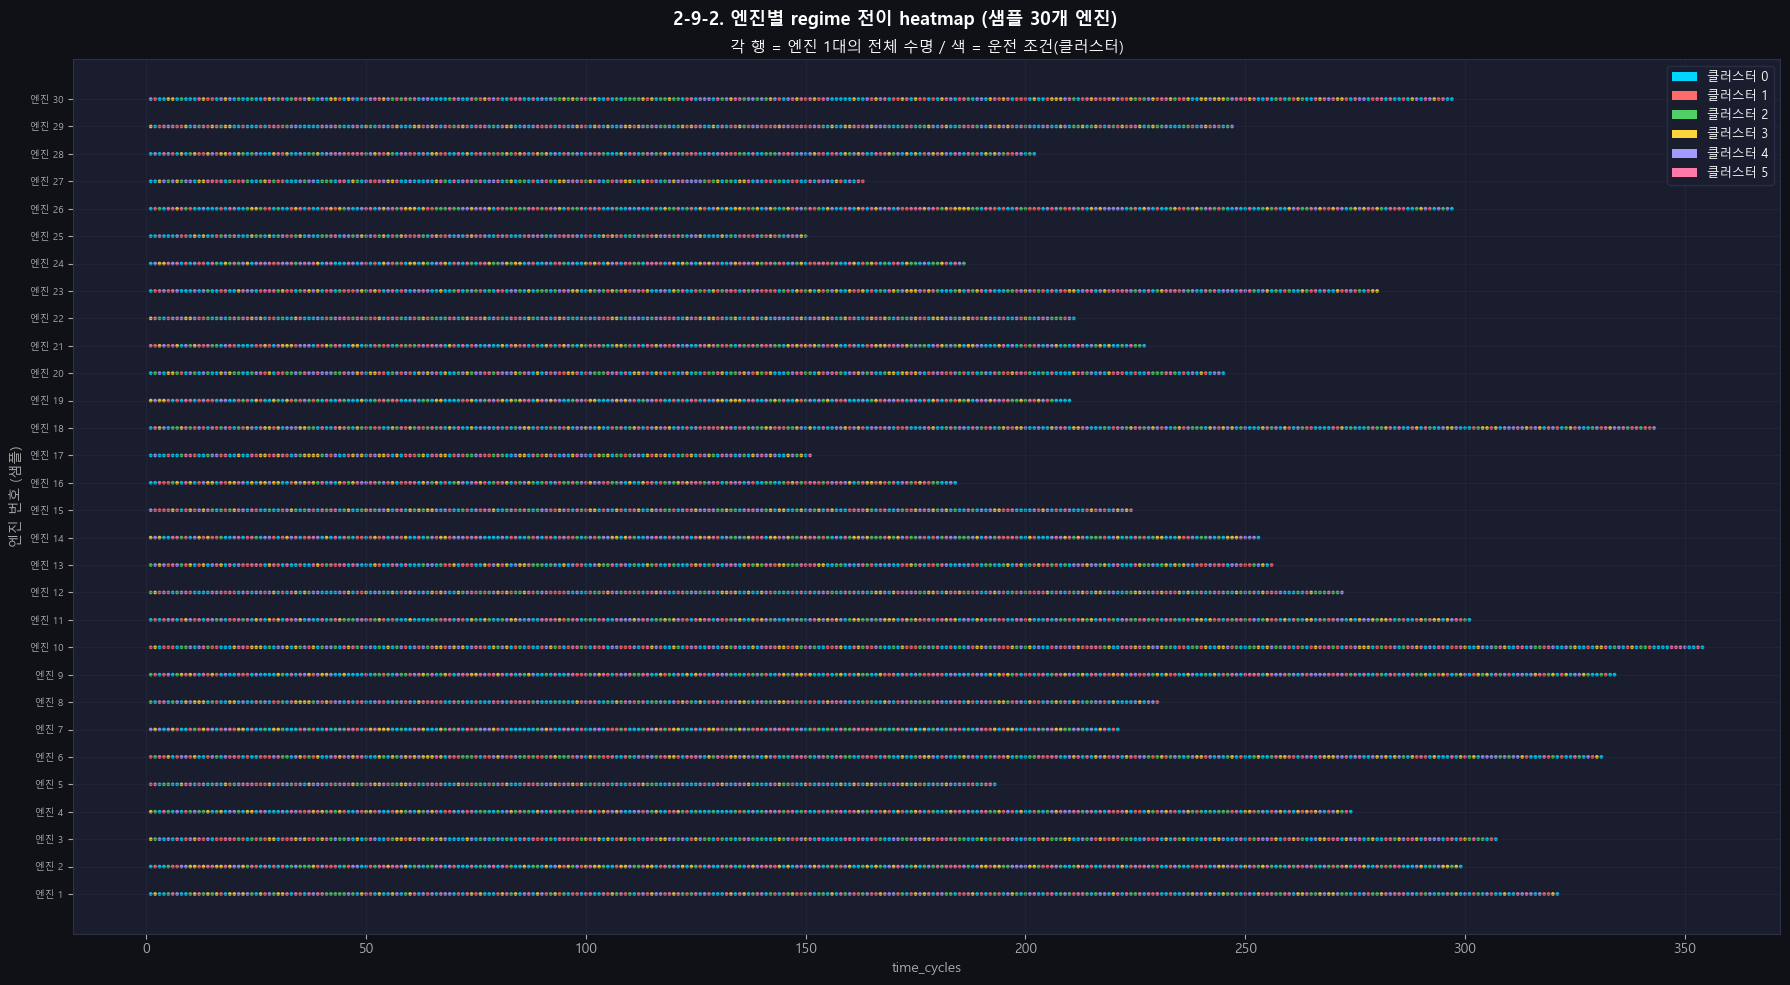

📌 한 엔진이 여러 조건을 반복적으로 경험함을 확인
   → window 내에 여러 조건이 섞일 수 있음 → window size 결정에 영향


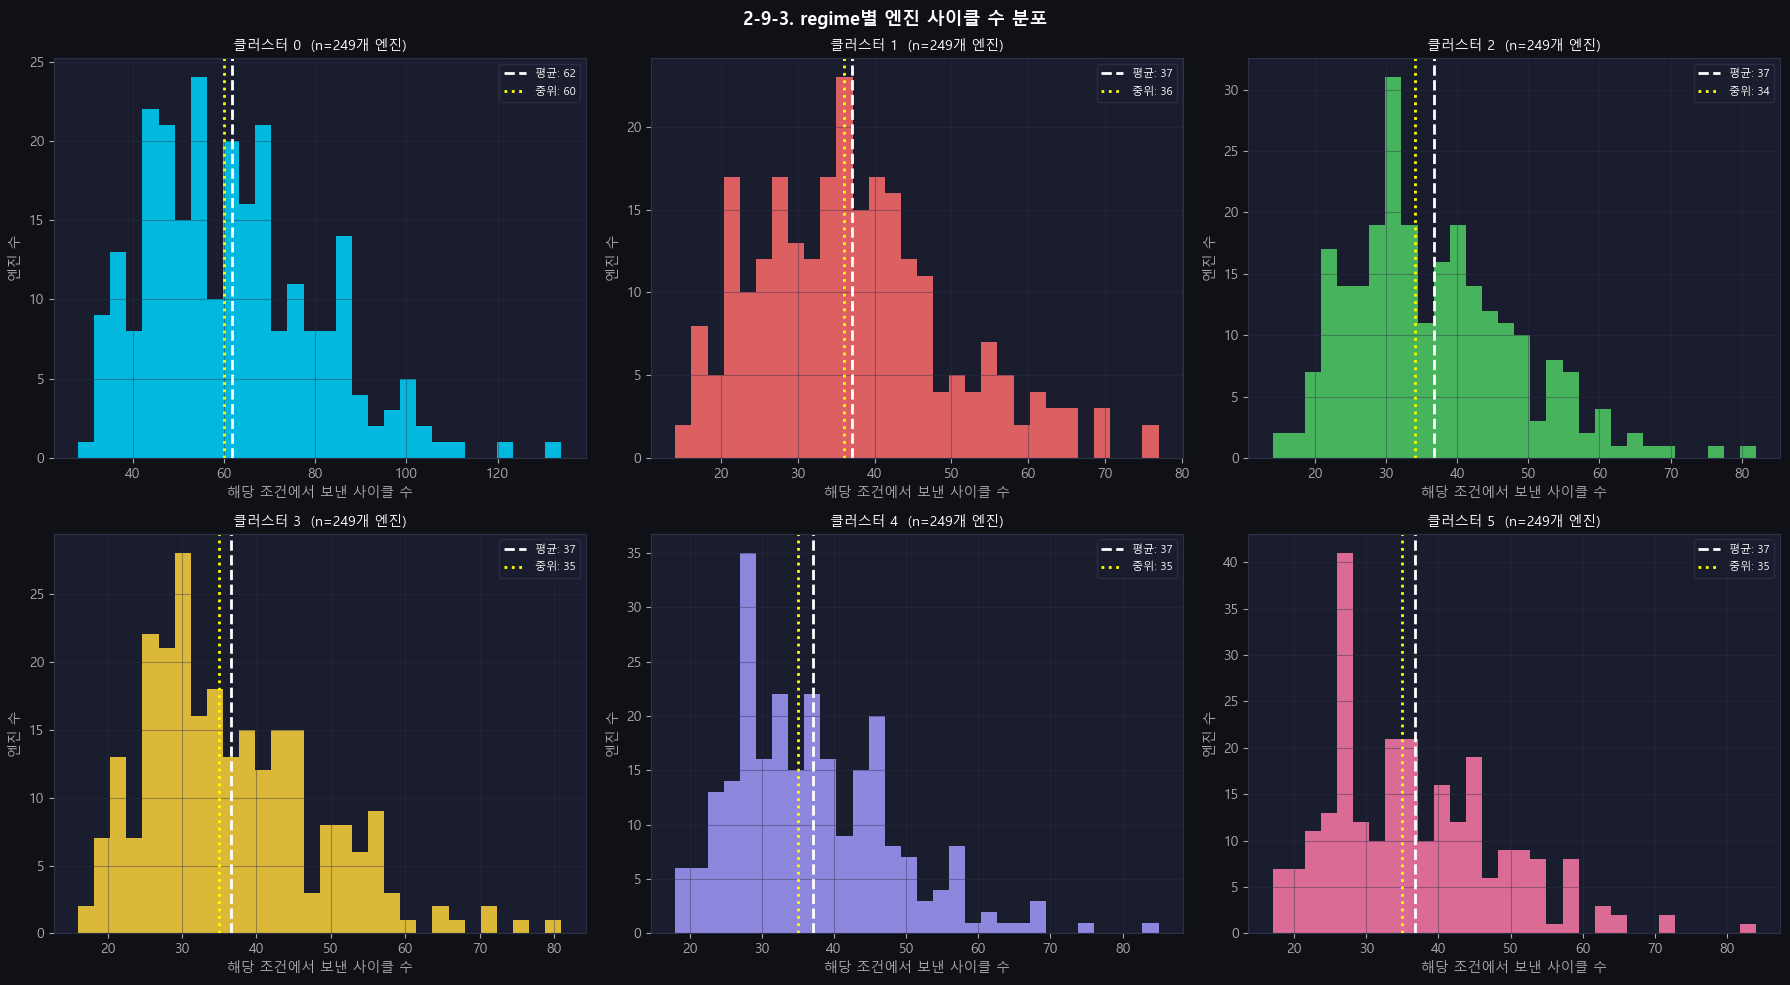

--- 클러스터별 평균 사이클 수 ---


,평균,중위,최소,최대
cluster,,,,
0,61.8,60.0,28,134
1,37.0,36.0,14,77
2,36.7,34.0,14,82
3,36.5,35.0,16,81
4,37.1,35.0,18,85
5,36.8,35.0,17,84


📌 특정 조건에서 사이클이 많다 = 해당 조건에서 많이 운행 = 열화에 더 많이 노출


In [13]:
# 2-9. 클러스터 특성 심화 분석
# EDA용 클러스터 레이블 사용 (cluster_labels_eda)
train_eda = train_raw.copy()
train_eda['cluster'] = cluster_labels_eda

# ── 2-9-1. 3D scatter ─────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle('2-9-1. 운전 조건 3D scatter (cluster 6개)', fontsize=13, fontweight='bold')

ax = fig.add_subplot(111, projection='3d')
for c in range(N_CLUSTERS):
    mask = cluster_labels_eda == c
    ax.scatter(
        train_raw[OP_COLS[0]][mask],
        train_raw[OP_COLS[1]][mask],
        train_raw[OP_COLS[2]][mask],
        color=C[c], alpha=0.3, s=1, label=f'클러스터 {c}'
    )
ax.set_xlabel('setting_1 (고도)')
ax.set_ylabel('setting_2 (마하수)')
ax.set_zlabel('setting_3 (TRA)')
ax.set_title('3D 공간에서 6개 클러스터 분리 확인')
ax.legend(fontsize=9, markerscale=5)
plt.tight_layout(); plt.show()

# ── 2-9-2. 엔진별 regime 전이 heatmap ────────────────────
sample_units = train_eda['unit_nr'].unique()[:30]  # 30개 엔진 샘플

fig, ax = plt.subplots(figsize=(18, 10))
fig.suptitle('2-9-2. 엔진별 regime 전이 heatmap (샘플 30개 엔진)', fontsize=13, fontweight='bold')

from matplotlib.colors import ListedColormap
cmap_cluster = ListedColormap(C[:N_CLUSTERS])

for i, uid in enumerate(sample_units):
    sub = train_eda[train_eda['unit_nr'] == uid].sort_values('time_cycles')
    ax.scatter(sub['time_cycles'], [i] * len(sub),
               c=sub['cluster'], cmap=cmap_cluster,
               vmin=0, vmax=N_CLUSTERS-1,
               s=3, alpha=0.8)

ax.set_xlabel('time_cycles')
ax.set_ylabel('엔진 번호 (샘플)')
ax.set_yticks(range(len(sample_units)))
ax.set_yticklabels([f'엔진 {u}' for u in sample_units], fontsize=7)
ax.set_title('각 행 = 엔진 1대의 전체 수명 / 색 = 운전 조건(클러스터)')

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=C[c], label=f'클러스터 {c}') for c in range(N_CLUSTERS)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

print('📌 한 엔진이 여러 조건을 반복적으로 경험함을 확인')
print('   → window 내에 여러 조건이 섞일 수 있음 → window size 결정에 영향')

# ── 2-9-3. regime별 수명 분포 ────────────────────────────
# 엔진별 각 클러스터에서 보낸 사이클 수 계산
cluster_cycle_counts = train_eda.groupby(['unit_nr', 'cluster']).size().reset_index(name='cycle_count')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2-9-3. regime별 엔진 사이클 수 분포', fontsize=13, fontweight='bold')

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    data = cluster_cycle_counts[cluster_cycle_counts['cluster'] == c]['cycle_count']
    ax.hist(data, bins=30, color=C[c], alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(), color='white', ls='--', lw=2, label=f'평균: {data.mean():.0f}')
    ax.axvline(data.median(), color='yellow', ls=':', lw=2, label=f'중위: {data.median():.0f}')
    ax.set_title(f'클러스터 {c}  (n={len(data)}개 엔진)', fontsize=10)
    ax.set_xlabel('해당 조건에서 보낸 사이클 수')
    ax.set_ylabel('엔진 수')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# 클러스터별 평균 사이클 수 요약
print('--- 클러스터별 평균 사이클 수 ---')
summary = cluster_cycle_counts.groupby('cluster')['cycle_count'].agg(['mean','median','min','max']).round(1)
summary.columns = ['평균', '중위', '최소', '최대']
display(summary)
print('📌 특정 조건에서 사이클이 많다 = 해당 조건에서 많이 운행 = 열화에 더 많이 노출')

### 📊 2-9. 클러스터 특성 심화 분석 결과

---

#### 2-9-1. 운전 조건 3D scatter
- 6개 클러스터가 3D 공간에서 완벽하게 분리됨
- 연속적 변화가 아닌 **6개 고정 조합**으로 존재
- 2-7의 2D 결과와 일치, 3D에서도 군집 구조 재확인 ✅

---

#### 2-9-2. 엔진별 regime 전이 heatmap
- 모든 엔진에서 수명 전체에 걸쳐 6가지 조건이 빠르게 반복됨
- 조건 전환이 매우 불규칙하고 빈번함 → FD002와 동일한 패턴
- **window=30 안에 여러 조건이 반드시 섞임**
  → window size 재검토 필요성 시각적으로 확인

> 📌 운전조건 클러스터링(setting 기반)으로는 고장 모드(HPC vs 팬) 영향은 보이지 않음  
> → 고장 모드 혼재 영향은 2-10 고장 모드 클러스터링에서 별도 확인 예정

---

#### 2-9-3. regime별 사이클 수 분포

| 클러스터 | 평균 | 중위 | 최소 | 최대 | 비고 |
|---------|------|------|------|------|------|
| 0 | 61.8 | 60.0 | 28 | 134 | 다른 클러스터의 약 1.7배 |
| 1 | 37.0 | 36.0 | 14 | 77 | |
| 2 | 36.7 | 34.0 | 14 | 82 | |
| 3 | 36.5 | 35.0 | 16 | 81 | |
| 4 | 37.1 | 35.0 | 18 | 85 | |
| 5 | 36.8 | 35.0 | 17 | 84 | |

- 클러스터 0: 평균 61.8사이클로 다른 클러스터의 약 1.7배 → 2-7의 25.1% 비율과 일치
- 클러스터 1~5: 평균 36~37사이클로 균등 분포 → FD002와 거의 동일한 패턴
- **클러스터별 최소 사이클: 14~28사이클**
  → window=30이면 클러스터 1~5에서 padding 발생 가능
  → FD002와 동일하게 window size를 20 이하로 낮추는 것 검토 필요

---

#### 🔑 핵심 결론
> **운전조건 6개가 3D 공간에서도 완벽하게 분리됨 → k=6 클러스터링 근거 재확인**  
> **모든 엔진에서 6가지 조건이 빠르게 반복 → window 내 조건 혼재 불가피**  
> **클러스터 0이 평균 61.8사이클로 가장 많음 → 가장 자주 발생하는 운전조건**  
> **클러스터 1~5 최소 사이클 14~18 → window=30 적용 시 padding 발생**  
> → window size 통계 검정에서 최적값 결정 예정  
> **운전조건 클러스터링(setting 기반)으로는 고장 모드 영향 확인 불가**  
> → 고장 모드 혼재 영향은 2-10 고장 모드 클러스터링에서 별도 분석 예정

---
## 2-10. 고장 모드 클러스터링 (FD004 전용 ★)

FD004는 HPC 열화 + 팬 열화 2가지 고장 모드가 혼재하며, 운전조건 6가지도 동시에 존재함.  
2-9에서 운전조건 클러스터링(setting 기반)으로는 고장 모드 영향이 보이지 않았음.  
따라서 엔진별 센서 열화 slope 기반으로 고장 모드 클러스터링을 별도로 수행하여  
HPC 열화 엔진과 팬 열화 엔진이 데이터 내에서 구분 가능한지 확인함.

**분석 목적**
- HPC 열화 vs 팬 열화 엔진 그룹 분리 시도
- 실루엣 스코어로 k=2가 적절한지 근거 확인
- 클러스터별 센서 트렌드 및 수명 분포 비교

**왜 중요한가**
- 고장 모드가 다르면 열화 패턴이 달라 모델 학습에 영향을 줄 수 있음
- FD003에서 실루엣 스코어 0.4076로 구분 가능했음 → FD004도 동일 여부 확인
- 구분 가능하다면 fault_mode_cluster 피처 추가 검토 가능
- 운전조건 혼재로 인해 FD003보다 고장 모드 구분이 더 어려울 수 있음

=== 2-10. 고장 모드 클러스터링 (KMeans k=2) ===
목적: HPC 열화 vs 팬 열화 엔진 그룹 분리 시도

--- 엔진별 마지막 30사이클 센서 slope 계산 ---
--- k별 실루엣 스코어 비교 ---
  k=2: silhouette score=0.4192
  k=3: silhouette score=0.3305

--- 클러스터별 엔진 수 ---
  클러스터 0: 104대 (41.8%)
  클러스터 1: 145대 (58.2%)


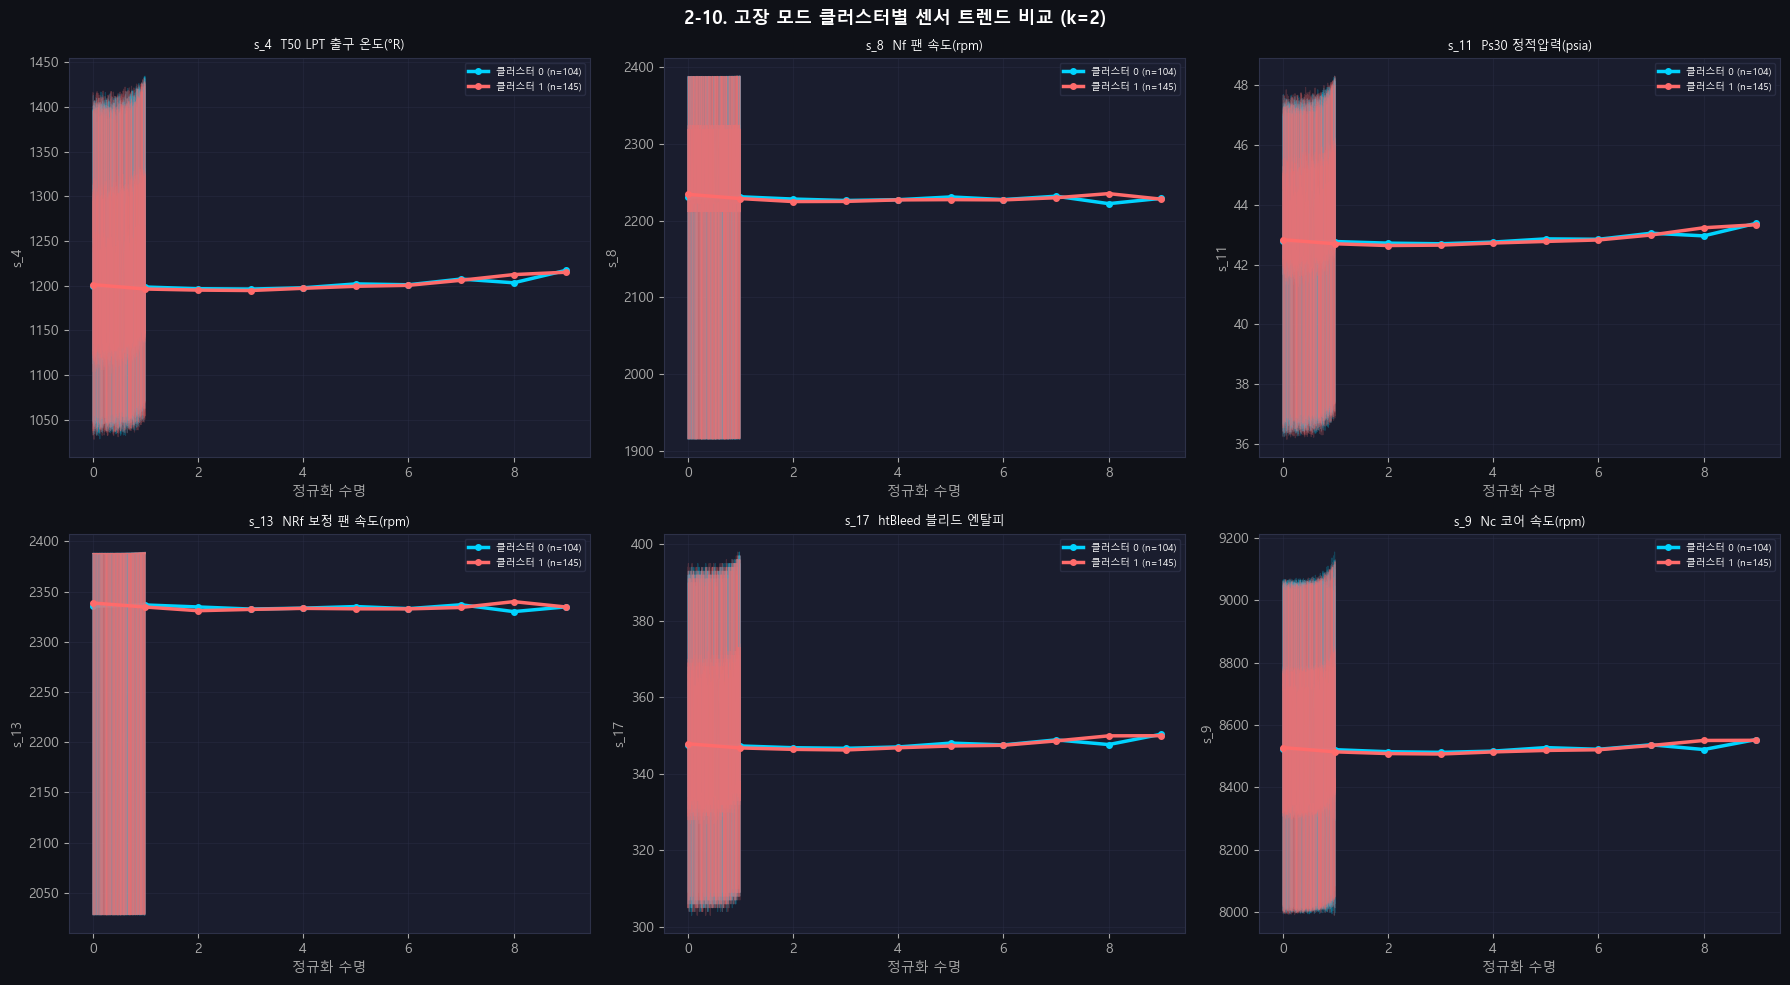

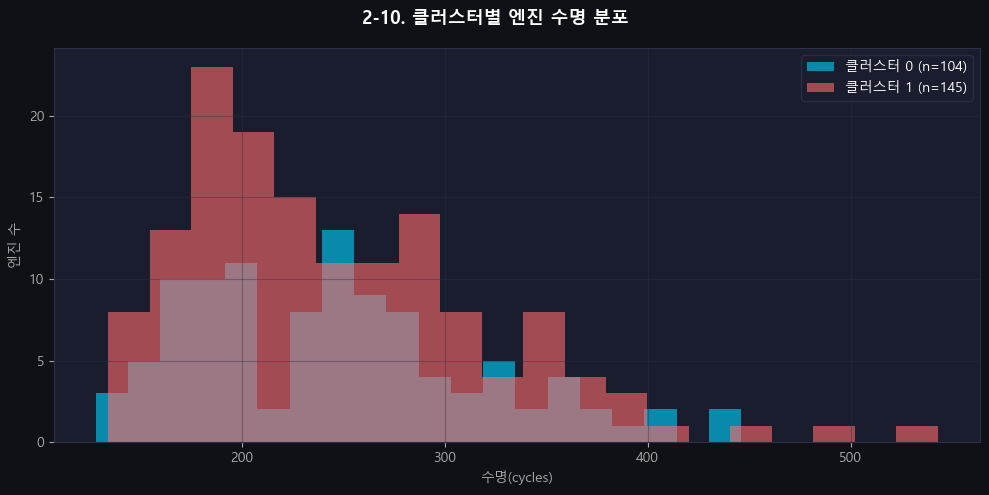


📌 실루엣 스코어 0.2 미만 → 클러스터 구분 불명확 → fault_mode 피처 없이 FD001 파이프라인 그대로
📌 실루엣 스코어 0.2 이상 → 클러스터 구분 가능 → fault_mode_cluster 피처 추가 검토


In [14]:
# 2-10. 고장 모드 클러스터링 (FD004 전용 ★)
print('=== 2-10. 고장 모드 클러스터링 (KMeans k=2) ===')
print('목적: HPC 열화 vs 팬 열화 엔진 그룹 분리 시도')
print()

# 엔진별 마지막 30사이클 센서 slope 계산
print('--- 엔진별 마지막 30사이클 센서 slope 계산 ---')
slope_rows = []
for uid in train_raw['unit_nr'].unique():
    udf = train_raw[train_raw['unit_nr'] == uid].sort_values('time_cycles').tail(30)
    row = {'unit_nr': uid}
    for s in SENSOR_COLS:
        x = np.arange(len(udf))
        y = udf[s].values
        if np.std(y) > 0:
            slope = np.polyfit(x, y, 1)[0]
        else:
            slope = 0.0
        row[f'{s}_slope'] = slope
    slope_rows.append(row)

slope_df = pd.DataFrame(slope_rows).set_index('unit_nr')
slope_features = [c for c in slope_df.columns]

# 정규화
from sklearn.preprocessing import StandardScaler
scaler_slope = StandardScaler()
slope_scaled = scaler_slope.fit_transform(slope_df)

# k=2 vs k=3 실루엣 스코어 비교
print('--- k별 실루엣 스코어 비교 ---')
for k in [2, 3]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(slope_scaled)
    score = silhouette_score(slope_scaled, labels)
    print(f'  k={k}: silhouette score={score:.4f}')

# k=2 클러스터링
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km2.fit_predict(slope_scaled)
slope_df['fault_mode_cluster'] = cluster_labels

# 클러스터별 샘플 수
print('\n--- 클러스터별 엔진 수 ---')
for c in [0, 1]:
    cnt = (cluster_labels == c).sum()
    print(f'  클러스터 {c}: {cnt}대 ({cnt/len(cluster_labels)*100:.1f}%)')

# 시각화 - 클러스터별 대표 센서 트렌드 비교
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2-10. 고장 모드 클러스터별 센서 트렌드 비교 (k=2)',
             fontsize=13, fontweight='bold')

# 클러스터별 대표 센서
show_sensors = ['s_4', 's_8', 's_11', 's_13', 's_17', 's_9']
cluster_engine_map = {c: slope_df[slope_df['fault_mode_cluster']==c].index.tolist()
                      for c in [0, 1]}

tr_trend2 = train_raw.copy()
mc = tr_trend2.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend2 = tr_trend2.join(mc, on='unit_nr')
tr_trend2['norm_life'] = tr_trend2['time_cycles'] / tr_trend2['max_c']

for ax, s in zip(axes.flat, show_sensors):
    for c, color in zip([0, 1], [C[0], C[1]]):
        units = cluster_engine_map[c][:10]
        for uid in units:
            sub = tr_trend2[tr_trend2['unit_nr']==uid].sort_values('norm_life')
            ax.plot(sub['norm_life'], sub[s],
                    color=color, alpha=0.2, lw=0.8)
        # 클러스터 평균 트렌드
        cluster_data = tr_trend2[tr_trend2['unit_nr'].isin(
            cluster_engine_map[c])].copy()
        bins = np.linspace(0, 1, 11)
        labels_bin = [f'{int(a*100)}~{int(b*100)}%'
                      for a, b in zip(bins[:-1], bins[1:])]
        cluster_data['life_bin'] = pd.cut(cluster_data['norm_life'],
                                          bins=bins, labels=labels_bin)
        trend = cluster_data.groupby('life_bin', observed=True)[s].mean()
        ax.plot(range(len(trend)), trend.values,
                color=color, lw=2.5, marker='o', markersize=4,
                label=f'클러스터 {c} (n={len(cluster_engine_map[c])})')
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")}', fontsize=9)
    ax.set_xlabel('정규화 수명')
    ax.set_ylabel(s)
    ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# 클러스터별 수명 분포 비교
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('2-10. 클러스터별 엔진 수명 분포', fontsize=13, fontweight='bold')
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()
for c, color in zip([0, 1], [C[0], C[1]]):
    units = cluster_engine_map[c]
    ax.hist(lifecycles[units], bins=20, color=color, alpha=0.6,
            label=f'클러스터 {c} (n={len(units)})')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('엔진 수')
ax.legend()
plt.tight_layout(); plt.show()

print('\n📌 실루엣 스코어 0.2 미만 → 클러스터 구분 불명확 → fault_mode 피처 없이 FD001 파이프라인 그대로')
print('📌 실루엣 스코어 0.2 이상 → 클러스터 구분 가능 → fault_mode_cluster 피처 추가 검토')

### 📊 2-10. 고장 모드 클러스터링 결과 (FD004 전용 ★)

---

#### 클러스터링 품질
| k | 실루엣 스코어 | 판정 |
|---|------------|------|
| 2 | **0.4192** | ✅ 구분 가능 (0.2 이상) |
| 3 | 0.3305 | k=2가 더 적합 |

> 📌 실루엣 스코어 0.4192 → FD003(0.4076)보다 오히려 높게 나옴  
> → 운전조건 혼재에도 불구하고 고장 모드 2가지 클러스터 구분 가능

---

#### 클러스터별 엔진 구성
| 클러스터 | 엔진 수 | 비율 | FD003 비교 |
|---------|---------|------|-----------|
| 0 (파란색) | 104대 | 41.8% | FD003 클러스터 0: 44대(44%) |
| 1 (빨간색) | 145대 | 58.2% | FD003 클러스터 1: 56대(56%) |

> 📌 FD003과 비율 패턴이 거의 동일 → 동일한 방식으로 고장 모드 분리됨

---

#### 센서 트렌드 비교 해석
- **두 클러스터 모두 트렌드 방향은 동일**하나 **기저값(초기값)이 다름**
- s_4, s_17: 클러스터 0(파랑)이 더 높은 초기값에서 시작
- s_8, s_13: 두 클러스터 초기값 차이 뚜렷 → 팬 속도 기반 구분 가능
- s_9: 클러스터 간 초기값 차이 존재
- **초반 0~10% 구간 분산이 매우 큼**
  → 운전조건 6가지 혼재로 개별 궤적이 넓게 퍼짐
  → FD003보다 초반 노이즈가 더 심함

---

#### 클러스터별 수명 분포 비교
- 두 클러스터 모두 수명 분포가 **넓게 겹침**
- 클러스터 0(파랑): 수명 분포가 전반적으로 더 넓고 긴 수명 구간(300~500)에 더 많이 분포
- 클러스터 1(빨강): 150~300 구간에 집중, 수명이 짧은 편
- FD003과 동일한 패턴 → 클러스터 1이 팬 열화로 수명이 짧은 그룹으로 추정

> 📌 두 클러스터 수명 분포가 많이 겹침 → 수명만으로는 고장 모드 구분 어려움  
> → slope 기반 클러스터링이 유효한 이유
---

#### 🔑 핵심 결론
> **실루엣 스코어 0.4192 → 고장 모드 2가지 클러스터 구분 가능**  
> **FD003(0.4076)보다 높은 스코어 → 운전조건 혼재에도 slope 기반 분리 유효**  
> **클러스터 0(104대): 높은 초기값 → HPC 열화 엔진으로 추정**  
> **클러스터 1(145대): 낮은 초기값 → 팬 열화 엔진으로 추정**  
> **fault_mode_cluster 피처 추가 여부는 팀 상의 후 결정**  
> → 옵션 A: 피처 추가 없이 FD002 파이프라인 그대로 (구현 단순)  
> → 옵션 B: fault_mode_cluster 피처 추가 (성능 향상 가능, 복잡도 증가)

---
## 2-11. 고장 모드 클러스터별 센서 분포 비교 (FD004 전용 ★)

**분석 목적**
- 고장 모드 클러스터(HPC 열화 vs 팬 열화) 간 센서 절댓값 범위 차이 확인
- 운전조건 클러스터별 MinMax는 이미 확정 → 고장 모드 클러스터 간 분포 차이는 참고용
- 범위가 겹치면 → 운전조건 클러스터별 MinMax로 충분
- 범위가 분리되면 → fault_mode_cluster 피처 추가 효과 있을 가능성

**FD003과의 차이**
- FD003은 단일 운전조건이라 고장 모드 클러스터별 MinMax 필요 여부가 핵심 판단이었음
- FD004는 운전조건 클러스터별 MinMax가 확정 → 여기서는 고장 모드 간 센서 분포 차이가 얼마나 존재하는지 파악하는 것이 목적

=== 2-11. 고장 모드 클러스터별 센서 분포 비교 ===
목적: 고장 모드 클러스터 간 센서 절댓값 범위 차이 확인
      → 운전조건 클러스터별 MinMax는 확정, 고장 모드 클러스터 간 분포 차이 참고용



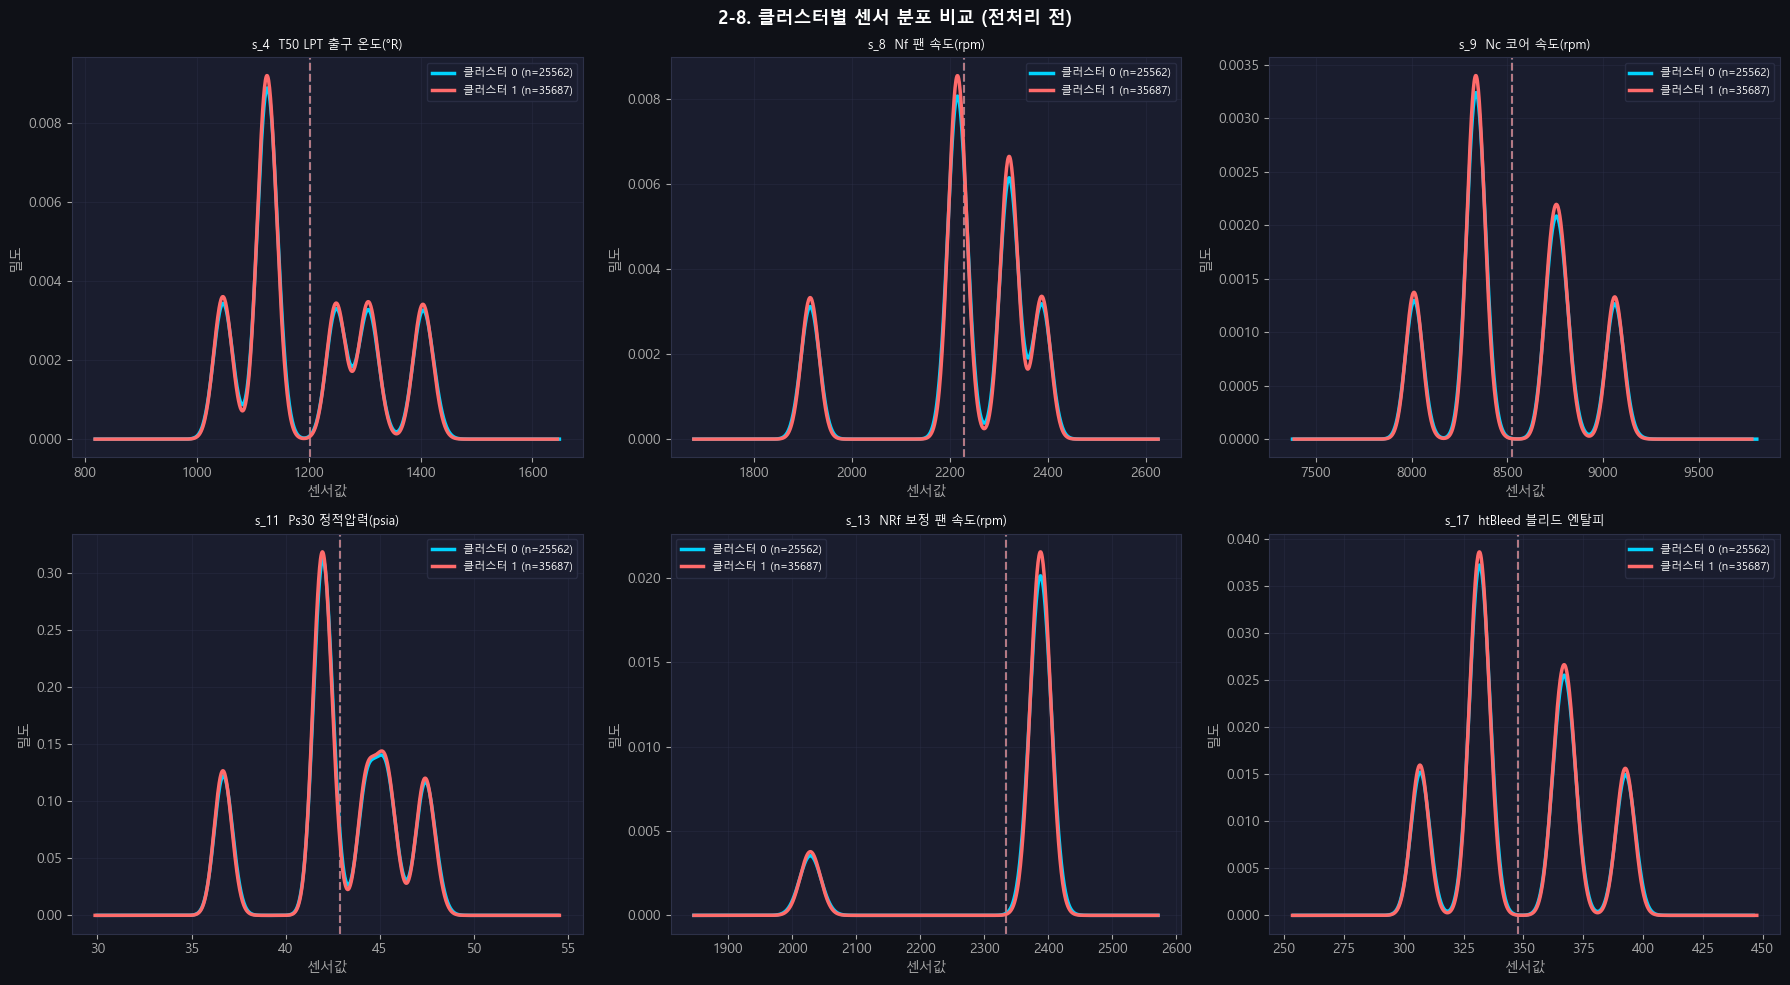


--- 클러스터별 센서 범위 비교 ---


,C0 min,C0 max,C0 mean,C1 min,C1 max,C1 mean,범위 겹침
센서,,,,,,,
s_1,445.0000,518.6700,472.8589,445.0000,518.6700,472.8993,✅ 겹침
s_2,535.5900,644.4200,579.3969,535.4800,644.2100,579.4367,✅ 겹침
s_3,1242.9800,1613.0000,1417.9746,1242.6700,1613.0000,1417.8407,✅ 겹침
s_4,1025.5200,1440.7700,1202.0148,1024.4200,1437.9700,1201.8441,✅ 겹침
s_5,3.9100,14.6200,8.0273,3.9100,14.6200,8.0347,✅ 겹침
s_6,5.6700,21.6100,11.5846,5.6800,21.6100,11.5929,✅ 겹침
s_7,136.3800,569.5800,283.1928,136.1700,570.8100,283.4259,✅ 겹침
s_8,1914.7200,2388.5900,2228.5535,1914.8000,2388.6400,2228.7810,✅ 겹침
s_9,7984.5100,9196.8100,8524.8241,7984.5900,9179.6700,8524.5653,✅ 겹침



범위 겹치는 센서: 21/21개
📌 범위 대부분 겹침 → 운전조건 클러스터별 MinMax로 충분, 고장 모드별 추가 정규화 불필요
📌 범위 분리 센서 많음 → 고장 모드 영향 존재 → fault_mode_cluster 피처 추가 검토


In [15]:
# 2-11. 고장 모드 클러스터별 센서 분포 비교 (FD004 전용 ★)
print('=== 2-11. 고장 모드 클러스터별 센서 분포 비교 ===')
print('목적: 고장 모드 클러스터 간 센서 절댓값 범위 차이 확인')
print('      → 운전조건 클러스터별 MinMax는 확정, 고장 모드 클러스터 간 분포 차이 참고용')
print()

# slope_df에서 cluster 라벨 가져오기 (train_raw 건드리지 않음)
tr_dist = train_raw.copy()
tr_dist['fault_mode_cluster'] = tr_dist['unit_nr'].map(
    slope_df['fault_mode_cluster']
)

# 클러스터별 센서 분포 비교 (유효 센서만)
show_sensors = ['s_4', 's_8', 's_9', 's_11', 's_13', 's_17']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2-8. 클러스터별 센서 분포 비교 (전처리 전)',
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, show_sensors):
    for c, color in zip([0, 1], [C[0], C[1]]):
        data = tr_dist[tr_dist['fault_mode_cluster']==c][s].dropna()
        try:
            data.plot.kde(ax=ax, color=color, lw=2.5,
                         label=f'클러스터 {c} (n={len(data)})')
        except:
            pass
        ax.axvline(data.mean(), color=color, ls='--', lw=1.5, alpha=0.7)
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")}', fontsize=9)
    ax.set_xlabel('센서값')
    ax.set_ylabel('밀도')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# 클러스터별 센서 범위 비교 (min, max, mean)
print('\n--- 클러스터별 센서 범위 비교 ---')
range_rows = []
for s in SENSOR_COLS:
    c0 = tr_dist[tr_dist['fault_mode_cluster']==0][s]
    c1 = tr_dist[tr_dist['fault_mode_cluster']==1][s]
    range_rows.append({
        '센서': s,
        'C0 min': round(c0.min(), 4),
        'C0 max': round(c0.max(), 4),
        'C0 mean': round(c0.mean(), 4),
        'C1 min': round(c1.min(), 4),
        'C1 max': round(c1.max(), 4),
        'C1 mean': round(c1.mean(), 4),
        '범위 겹침': '✅ 겹침' if c0.min() <= c1.max() and c1.min() <= c0.max() else '⚠️ 분리'
    })

range_df = pd.DataFrame(range_rows).set_index('센서')
display(range_df)

overlap_cnt = (range_df['범위 겹침'] == '✅ 겹침').sum()
print(f'\n범위 겹치는 센서: {overlap_cnt}/{len(SENSOR_COLS)}개')
print('📌 범위 대부분 겹침 → 운전조건 클러스터별 MinMax로 충분, 고장 모드별 추가 정규화 불필요')
print('📌 범위 분리 센서 많음 → 고장 모드 영향 존재 → fault_mode_cluster 피처 추가 검토')

### 📊 2-11. 고장 모드 클러스터별 센서 분포 비교 결과

---

#### 범위 동질성 요약
- 범위 겹치는 센서: **21/21개 (100%)**
- → FD003(21/21)과 동일한 결과

---

#### 시각화 해석
- 모든 센서에서 두 클러스터(파랑/빨강) KDE 곡선이 **거의 완전히 겹침**
- 멀티모달 분포의 각 봉우리 위치도 두 클러스터 간 동일
- 클러스터 간 평균값 차이도 미미 (C0 mean ≈ C1 mean)
- → 고장 모드 클러스터 간 센서 절댓값 범위 차이 없음

**FD003과 시각화 결과가 다른 이유 ★**
- FD003은 단일 운전조건이라 센서값 변동이 순수하게 열화 + 고장 모드 영향만 반영됨
  → 클러스터 간 KDE 형태가 달랐음 (초기값 및 분포 모양 차이 존재)
- FD004는 운전조건 6가지 혼재로 각 봉우리가 운전조건별로 나뉘어 있음
  → 고장 모드 클러스터 0과 1이 같은 운전조건 분포를 공유
  → KDE가 거의 완전히 겹쳐 보임
- 즉 **운전조건 영향이 워낙 커서 고장 모드 영향이 절댓값 분포에서 묻혀버린 것**
- slope 기반으로는 실루엣 스코어 0.4192로 구분이 됐으므로
  **열화 패턴(기울기) 자체는 다르지만 센서 절댓값 분포에서는 운전조건에 가려진 상태**

---

#### 🔑 핵심 결론
> **21/21개 센서 범위 겹침 → 운전조건 클러스터별 MinMax로 충분**  
> **고장 모드별 추가 정규화 불필요 → FD002 클러스터별 MinMax 그대로 적용**  
> **FD003과 범위 결론은 동일하나 시각화 패턴은 다름**  
> → FD003은 고장 모드가 분포 형태에 영향을 줬으나 FD004는 운전조건 영향에 묻혀 보이지 않음  
> **fault_mode_cluster 피처 추가 여부는 팀 상의 후 결정**  
> → 옵션 A: 피처 추가 없이 FD002 파이프라인 그대로 (구현 단순)  
> → 옵션 B: fault_mode_cluster 피처 추가 (열화 패턴 차이 정보 모델에 전달 가능)  
> ⚠️ 단, FD003 실험에서 클러스터 적용 시 RMSE가 52.48로 폭발한 사례 있음  
> → 피처 추가가 오히려 성능을 해칠 가능성 존재  
> → FD003 실험 결과를 근거로 신중하게 결정 필요

---
## 3. 통계 검정

### 검정 목적

EDA에서 시각적으로 확인한 패턴들을 **통계적으로 증명**하는 단계

| 검정 | 목적 |
|------|------|
| 3-1. 시차 상관관계 (Lag Correlation) | 몇 사이클 전 센서값이 RUL과 가장 연관있는지 확인 → 슬라이딩 윈도우 크기 결정 근거 |
| 3-2. Mann-Kendall | 센서값의 열화 트렌드가 통계적으로 유의미한지 검정 → Gaussian 스무딩 적용 근거 |
| 3-3. 대응 표본 검정 | 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정 → 유효 센서 선별 근거 |
| 3-4. RUL Cap 검증 | Cap 값에 따라 RUL 분포 균등성 차이 검정 → Cap=125 확정 근거 |
| 3-5. Gaussian σ 검증 | σ 값에 따른 노이즈 감소 효과 검정 → σ=2 확정 근거 |
| 3-6. 윈도우 크기별 RUL 상관계수 비교 | 윈도우 크기별 센서-RUL 상관계수 비교 → Window 크기 확정 근거 |
| 3-7. ANOVA | 운전조건 클러스터 간 센서값 차이 검정 → 클러스터별 정규화 필요성 통계적 증명 |
| 3-8. Kruskal-Wallis | 운전조건 클러스터별 엔진 수명 분포 차이 검정 → 클러스터별 정규화 근거 수명 관점 보강 |
| 3-9. Mann-Whitney U | 팬 관련 센서(s_8, s_13) 기준 엔진 그룹 간 RUL 분포 차이 검정 → 고장 모드 혼재 영향 확인 |
| 3-10. Levene's Test | FD002/003 대비 FD004 동일 센서 분산 동질성 검정 → 동일 전처리 적용 가능 여부 근거 |
| 3-11. Chi-square 검정 | 운전조건 클러스터 × 고장 모드 클러스터 교차 분석 → 두 클러스터링의 독립성 여부 확인 ★ FD004 전용 |

> 💡 모든 검정의 유의수준: α = 0.05 — p-value < 0.05 → H₀ 기각 → H₁ 채택

#### 3-1. 시차 상관관계 (Lag Correlation)

**3-1-1. 전체 센서 기준**
- **H₀**: 과거 센서값과 현재 RUL 사이에 상관관계가 없다
- **H₁**: 특정 시차(lag)에서 센서값과 RUL 사이에 유의미한 상관관계가 있다
- FD001(window=30), FD002(window=20), FD003(window=30)과 비교하여 FD004의 최적 window size 결정
- FD004는 운전조건 6가지 혼재로 전체 기준 lag 분석만으로는 조건별 차이를 놓칠 수 있음
  → 3-1-2 클러스터별 분석으로 보완


=== 3-1. 시차 상관관계 (Lag Correlation) ===


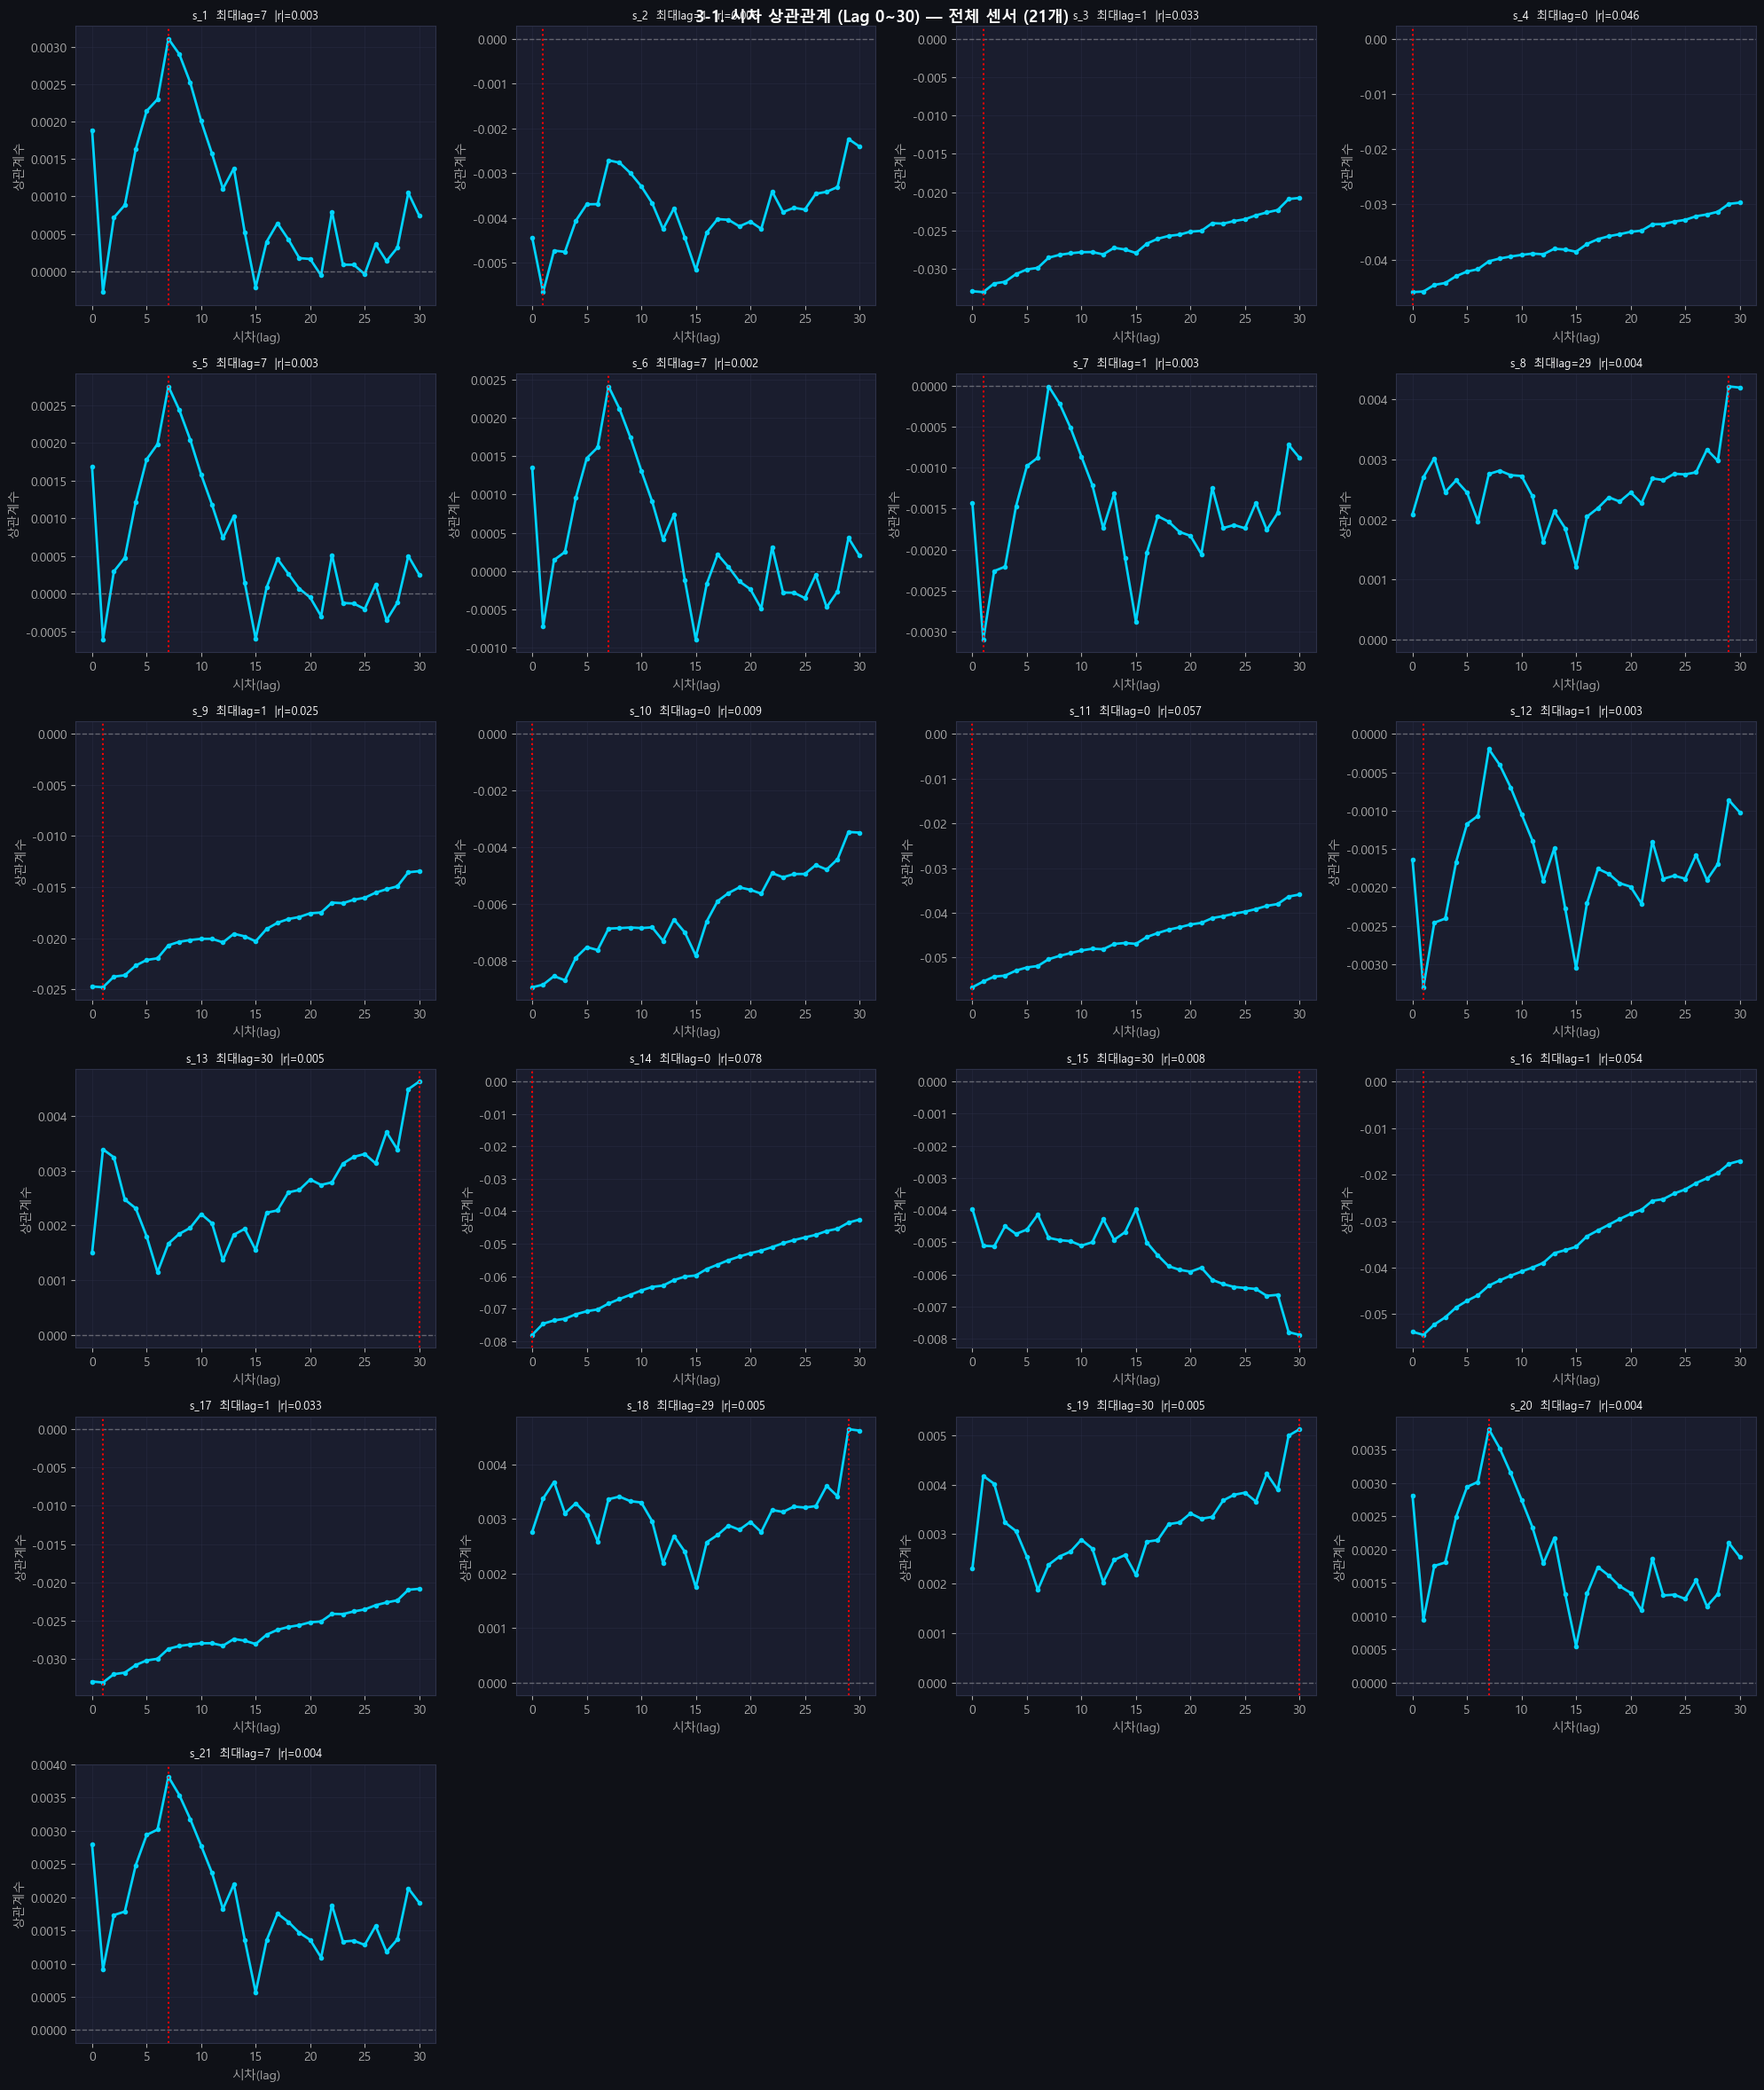


=== 센서별 최적 시차 요약 ===
  s_1: lag=7사이클에서 최대 상관 (r=0.003)
  s_2: lag=1사이클에서 최대 상관 (r=-0.006)
  s_3: lag=1사이클에서 최대 상관 (r=-0.033)
  s_4: lag=0사이클에서 최대 상관 (r=-0.046)
  s_5: lag=7사이클에서 최대 상관 (r=0.003)
  s_6: lag=7사이클에서 최대 상관 (r=0.002)
  s_7: lag=1사이클에서 최대 상관 (r=-0.003)
  s_8: lag=29사이클에서 최대 상관 (r=0.004)
  s_9: lag=1사이클에서 최대 상관 (r=-0.025)
  s_10: lag=0사이클에서 최대 상관 (r=-0.009)
  s_11: lag=0사이클에서 최대 상관 (r=-0.057)
  s_12: lag=1사이클에서 최대 상관 (r=-0.003)
  s_13: lag=30사이클에서 최대 상관 (r=0.005)
  s_14: lag=0사이클에서 최대 상관 (r=-0.078)
  s_15: lag=30사이클에서 최대 상관 (r=-0.008)
  s_16: lag=1사이클에서 최대 상관 (r=-0.054)
  s_17: lag=1사이클에서 최대 상관 (r=-0.033)
  s_18: lag=29사이클에서 최대 상관 (r=0.005)
  s_19: lag=30사이클에서 최대 상관 (r=0.005)
  s_20: lag=7사이클에서 최대 상관 (r=0.004)
  s_21: lag=7사이클에서 최대 상관 (r=0.004)


In [16]:
# 3-1. 시차 상관관계 (Lag Correlation) — 전체 센서 기준
print('=== 3-1. 시차 상관관계 (Lag Correlation) ===')

all_sensors = [f's_{i}' for i in range(1, 22)]
tr_lag = train_raw.copy()
mc = tr_lag.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_lag = tr_lag.join(mc, on='unit_nr')
tr_lag['RUL'] = tr_lag['max_c'] - tr_lag['time_cycles']

max_lag = 30  # FD001=30, FD002=20, FD003=30 → FD004 결과 보고 결정
lag_results = {}

for s in all_sensors:
    lag_corrs = []
    for lag in range(0, max_lag + 1):
        shifted = tr_lag.groupby('unit_nr')[s].shift(lag)
        valid = ~shifted.isna()
        r = tr_lag.loc[valid, 'RUL'].corr(shifted[valid])
        lag_corrs.append(r)
    lag_results[s] = lag_corrs

# 시각화
n_cols = 4
n_rows = (len(all_sensors) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('3-1. 시차 상관관계 (Lag 0~30) — 전체 센서 (21개)', 
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, all_sensors):
    lag_corrs = lag_results[s]
    best_lag = int(np.argmax(np.abs(lag_corrs)))
    best_r   = lag_corrs[best_lag]
    ax.plot(range(max_lag + 1), lag_corrs, 
            color=C[0], lw=2, marker='o', markersize=3)
    ax.axhline(0, color=GRAY, ls='--', lw=1, alpha=0.5)
    ax.axvline(best_lag, color='red', ls=':', lw=1.5)
    ax.set_title(f'{s}  최대lag={best_lag}  |r|={abs(best_r):.3f}', fontsize=9)
    ax.set_xlabel('시차(lag)')
    ax.set_ylabel('상관계수')

for ax in axes.flat[len(all_sensors):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# 결과 요약
print('\n=== 센서별 최적 시차 요약 ===')
for s in all_sensors:
    best_lag = int(np.argmax(np.abs(lag_results[s])))
    best_r   = lag_results[s][best_lag]
    print(f'  {s}: lag={best_lag}사이클에서 최대 상관 (r={best_r:.3f})')

### 📊 3-1-1. 시차 상관관계 결과 (전체 센서 기준)

---

#### 센서별 최적 시차 요약

| 센서 | 최적 lag | r | 해석 | 비고 |
|------|---------|---|------|------|
| s_1 | 7 | 0.003 | 약한 상관 | 상수 센서 후보 |
| s_2 | 1 | -0.006 | 약한 상관 | |
| s_3 | 1 | -0.033 | 약한 상관 | |
| s_4 | 0 | -0.046 | lag=0 즉시 반응 | 유효 센서 |
| s_5 | 7 | 0.003 | 약한 상관 | 상수 센서 후보 |
| s_6 | 7 | 0.002 | 약한 상관 | |
| s_7 | 1 | -0.003 | 약한 상관 | |
| s_8 | 29 | 0.004 | 지연 반응 | ⚠️ 주목 |
| s_9 | 1 | -0.025 | 약한 상관 | |
| s_10 | 0 | -0.009 | lag=0 즉시 반응 | |
| s_11 | 0 | -0.057 | lag=0 즉시 반응 | 유효 센서 |
| s_12 | 1 | -0.003 | 약한 상관 | |
| s_13 | 30 | 0.005 | 지연 반응 | ⚠️ 주목 |
| s_14 | 0 | -0.078 | lag=0 즉시 반응 | 가장 높은 상관 |
| s_15 | 30 | -0.008 | 지연 반응 | ⚠️ 주목 |
| s_16 | 1 | -0.054 | 약한 상관 | 상수 센서 후보 |
| s_17 | 1 | -0.033 | 약한 상관 | |
| s_18 | 29 | 0.005 | 지연 반응 | ⚠️ 주목 |
| s_19 | 30 | 0.005 | 지연 반응 | ⚠️ 주목 |
| s_20 | 7 | 0.004 | 약한 상관 | |
| s_21 | 7 | 0.004 | 약한 상관 | |

---

#### 핵심 패턴 분석

**전반적으로 |r| 값이 매우 낮음 (최대 0.078)**
- FD003(최대 r=-0.689)과 비교해 극도로 낮은 수준
- 운전조건 6가지 혼재로 RUL 신호가 조건 노이즈에 완전히 묻혀있는 상태
- FD002와 동일한 패턴 → 클러스터별 정규화 후 재확인 필요

**lag=0 즉시 반응 센서**
- s_4, s_10, s_11, s_14 → 현재 센서값이 바로 RUL과 연관

**지연 반응 센서 ⚠️**
- s_8, s_18: lag=29 → 운전조건 영향으로 추정
- s_13, s_15, s_19: lag=30 → 상수/약상관 센서 노이즈일 가능성 높음

---

#### ★ 윈도우 크기 결정

| 데이터셋 | 유의미한 최대 lag | 윈도우 크기 |
|---------|----------------|-----------:|
| FD001 | - | 30 |
| FD002 | - | 20 |
| FD003 | s_9=8, s_14=5 | 30 |
| FD004 | s_14=0, s_11=0 | **클러스터별 분석 후 결정** |

> 📌 전체 기준으로는 유효 센서 lag가 0~1로 매우 낮음  
> → 운전조건 노이즈에 묻혀 실제 lag 파악 어려운 상태  
> → 3-1-2 클러스터별 분석 결과와 함께 최종 window size 결정 예정

---

#### 🔑 핵심 결론
> **전체 기준 |r| 최대 0.078 → FD003(0.689) 대비 극도로 낮음**  
> → 운전조건 6가지 혼재로 RUL 신호가 완전히 묻혀있는 상태  
> **lag=29~30 지연 반응 센서(s_8, s_13, s_15, s_18, s_19)는 노이즈 가능성 높음**  
> → 유효 센서 대부분이 lag=0~1 즉시 반응  
> **클러스터별 정규화 후 lag 패턴이 FD003처럼 뚜렷해질 것으로 예상**  
> → 3-1-2 클러스터별 시차 상관관계 분석에서 재확인 예정
---


**3-1-2. 클러스터별 ★ FD004 전용**
- **H₀**: 운전조건 클러스터별로 센서-RUL 시차 상관관계에 차이가 없다
- **H₁**: 운전조건 클러스터별로 최적 lag가 다르다
- 목적: 운전조건마다 센서가 RUL에 반응하는 시차가 다른지 확인
- 클러스터별 최적 lag가 다르면 → 단일 window size로는 모든 조건을 커버하기 어려움
  → window size 결정 시 가장 큰 최적 lag를 기준으로 설정하는 근거
- 클러스터별 최적 lag가 비슷하면 → 단일 window size 적용 가능 근거

=== 3-1-2. 시차상관관계 — 클러스터별 Sensor vs RUL (lag 0~15) ===


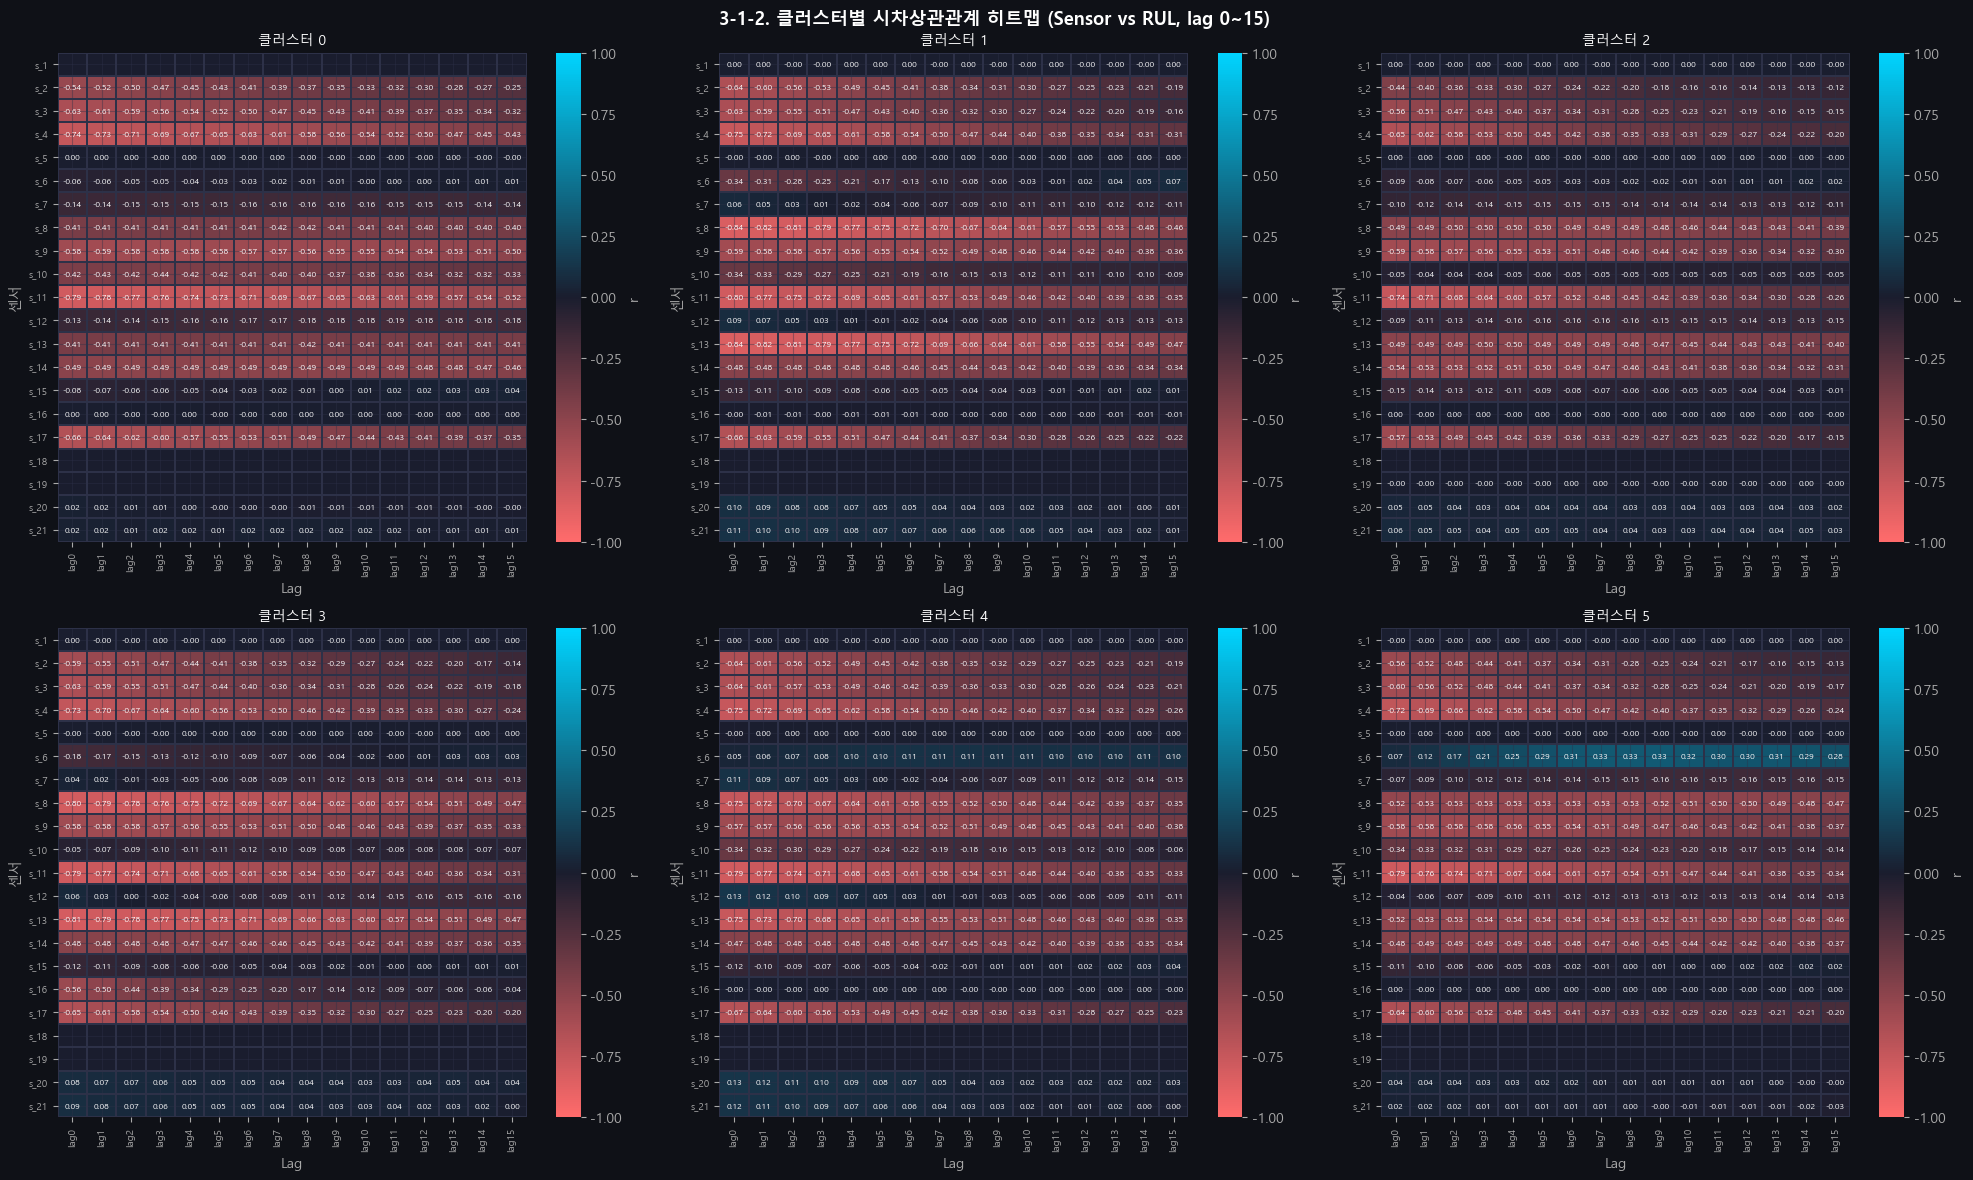


--- 클러스터별 최적 lag 분포 ---
클러스터 0: 평균 최적 lag=3.6  최대=15  최소=0
클러스터 1: 평균 최적 lag=3.2  최대=15  최소=0
클러스터 2: 평균 최적 lag=2.6  최대=12  최소=0
클러스터 3: 평균 최적 lag=2.5  최대=15  최소=0
클러스터 4: 평균 최적 lag=2.4  최대=15  최소=0
클러스터 5: 평균 최적 lag=3.6  최대=15  최소=0

📌 최대 lag = window size 하한선 근거


In [17]:
# 3-1-2. 시차상관관계 — 클러스터별 ★ FD004 전용
print('=== 3-1-2. 시차상관관계 — 클러스터별 Sensor vs RUL (lag 0~15) ===')

MAX_LAG = 15
LAGS = list(range(0, MAX_LAG + 1))

# RUL 추가
tr_lag = train_eda.copy()
mc = tr_lag.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_lag = tr_lag.join(mc, on='unit_nr')
tr_lag['RUL'] = tr_lag['max_c'] - tr_lag['time_cycles']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('3-1-2. 클러스터별 시차상관관계 히트맵 (Sensor vs RUL, lag 0~15)',
             fontsize=13, fontweight='bold')


from matplotlib.colors import LinearSegmentedColormap
cmap_lag = LinearSegmentedColormap.from_list('lag', ['#ff6b6b', '#1a1d2e', '#00d4ff'], N=256)

best_lag_summary = {}

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    sub_c = tr_lag[tr_lag['cluster'] == c]
    lag_matrix = np.full((len(SENSOR_COLS), len(LAGS)), np.nan)

    for si, s in enumerate(SENSOR_COLS):
        unit_lag_corrs = {lag: [] for lag in LAGS}
        for uid in sub_c['unit_nr'].unique():
            udf = sub_c[sub_c['unit_nr'] == uid].sort_values('time_cycles')
            sensor = udf[s].values
            rul = udf['RUL'].values
            for lag in LAGS:
                if len(sensor) > lag + 5:
                    r = np.corrcoef(sensor[:len(sensor)-lag], rul[lag:])[0, 1]
                    if np.isfinite(r):
                        unit_lag_corrs[lag].append(r)
        lag_matrix[si] = [
            np.mean(unit_lag_corrs[l]) if unit_lag_corrs[l] else np.nan
            for l in LAGS
        ]

    lag_df = pd.DataFrame(lag_matrix, index=SENSOR_COLS,
                          columns=[f'lag{l}' for l in LAGS])

    sns.heatmap(lag_df, ax=ax, cmap=cmap_lag, center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 6},
                linewidths=0.2, linecolor=GRID,
                cbar_kws={'label': 'r'})
    ax.set_title(f'클러스터 {c}', fontsize=10)
    ax.set_xlabel('Lag')
    ax.set_ylabel('센서')
    ax.tick_params(labelsize=7)

    # 최적 lag 요약
    best_lags = []
    for si, s in enumerate(SENSOR_COLS):
        row = lag_matrix[si]
        if not np.all(np.isnan(row)):
            best_lag = int(np.nanargmax(np.abs(row)))
            best_lags.append(best_lag)
    best_lag_summary[c] = best_lags

plt.tight_layout(); plt.show()

# 클러스터별 최적 lag 요약
print('\n--- 클러스터별 최적 lag 분포 ---')
for c in range(N_CLUSTERS):
    lags = best_lag_summary[c]
    print(f'클러스터 {c}: 평균 최적 lag={np.mean(lags):.1f}  '
          f'최대={max(lags)}  최소={min(lags)}')
print('\n📌 최대 lag = window size 하한선 근거')

### 📊 3-1-2. 시차 상관관계 결과 (클러스터별) ★ FD004 전용

---

#### 클러스터별 최적 lag 분포

| 클러스터 | 평균 최적 lag | 최대 | 최소 |
|---------|-------------|------|------|
| 0 | 3.6 | 15 | 0 |
| 1 | 3.2 | 15 | 0 |
| 2 | 2.6 | 12 | 0 |
| 3 | 2.5 | 15 | 0 |
| 4 | 2.4 | 15 | 0 |
| 5 | 3.6 | 15 | 0 |

---

#### 히트맵 해석

**3-1-1 전체 분석 대비 큰 변화 ★**
- 전체 기준에서는 |r| 최대 0.078로 거의 무의미했으나
- 클러스터별로 보면 **|r| 0.4~0.8 수준의 뚜렷한 상관관계 확인**
- → 운전조건 클러스터별로 분리하면 RUL 신호가 명확하게 드러남
- → 클러스터별 정규화 필요성이 시차 상관관계에서도 증명됨

**클러스터 공통 패턴**
- s_4, s_11, s_14: 모든 클러스터에서 강한 음의 상관 (열화시 증가)
- s_3, s_9, s_17: 모든 클러스터에서 음의 상관 일관성 있음
- s_5, s_16, s_18, s_19: 모든 클러스터에서 r≈0 → 상수 센서 후보 재확인

**클러스터별 차이**
- 클러스터 0, 1, 3, 4: s_8, s_13에서 상대적으로 강한 상관
- 클러스터 5: s_6에서 양의 상관이 뚜렷 → 다른 클러스터와 다른 패턴 ⚠️
- 전반적으로 클러스터 간 lag 패턴이 유사 → 단일 window size 적용 가능

---

#### ★ 윈도우 크기 최종 결정

| 근거 | 내용 |
|------|------|
| 클러스터별 평균 최적 lag | 2.4~3.6 → 매우 낮음 |
| 클러스터별 최대 lag | 12~15 |
| 클러스터별 lag 패턴 | 6개 클러스터 간 유사 → 단일 window size 적용 가능 |
| FD002 기준 (동일 운전조건 수) | window=20 |

> 📌 평균 최적 lag가 2.4~3.6으로 매우 낮아 window=10으로도 충분할 수 있음  
> 📌 단, 최대 lag=15가 존재하고 FD002(window=20)와 동일한 조건이므로  
> → **window=20 기본값으로 설정, 실험값으로 window=10, 30 추가 테스트**

---

#### 🔑 핵심 결론
> **클러스터별 분리 시 |r| 0.4~0.8로 급상승 → 클러스터별 정규화 효과 시차 상관관계에서도 증명**  
> **6개 클러스터 간 lag 패턴 유사 → 단일 window size 적용 가능**  
> **평균 최적 lag 2.4~3.6, 최대 lag 15 → window=20 기본값으로 설정**  
> **FD002(window=20)와 동일한 근거 확보**  
> → CONFIG window=20 기본, 실험값 10/30으로 설정 예정

#### 3-2. Mann-Kendall 추세 검정

**3-2-1. 전체 엔진 기준**
- **H₀**: 센서값에 단조 트렌드가 없다 (랜덤하게 변한다)
- **H₁**: 센서값에 유의미한 단조 트렌드가 있다 (열화 신호 존재)
- FD004 전체 249개 엔진 대상으로 검정
- 90% 이상의 엔진에서 유의미한 추세가 확인된 센서를 열화 신호 센서로 판정
- FD004는 운전조건 + 고장 모드 혼재로 전체 기준에서는 트렌드가 불명확할 가능성 있음
  → 3-2-2 클러스터별 분석으로 보완

### 켄달 타우(τ) 해석

- τ > 0: 시간이 지날수록 센서값 증가
- τ < 0: 시간이 지날수록 센서값 감소
- **|τ| 클수록 추세가 강함**

> 100개 엔진의 평균 τ를 사용하여 센서별 전반적인 추세 방향과 강도를 파악

=== 3-2-1. Mann-Kendall 추세 검정 (전체 엔진) ===


,유효 엔진 수,추세 있는 엔진 수,비율(%),평균 τ,추세 방향,판정
센서,,,,,,
s_11,249,209,83.9,0.1396,증가↑,추세 없음⚠️
s_14,249,206,82.7,0.1360,증가↑,추세 없음⚠️
s_15,249,203,81.5,0.0059,증가↑,추세 없음⚠️
s_13,249,202,81.1,0.3319,증가↑,추세 없음⚠️
s_4,249,200,80.3,0.1289,증가↑,추세 없음⚠️
s_9,249,167,67.1,0.0975,증가↑,추세 없음⚠️
s_8,249,153,61.4,0.0876,증가↑,추세 없음⚠️
s_17,249,133,53.4,0.0898,증가↑,추세 없음⚠️
s_12,249,132,53.0,0.0108,증가↑,추세 없음⚠️


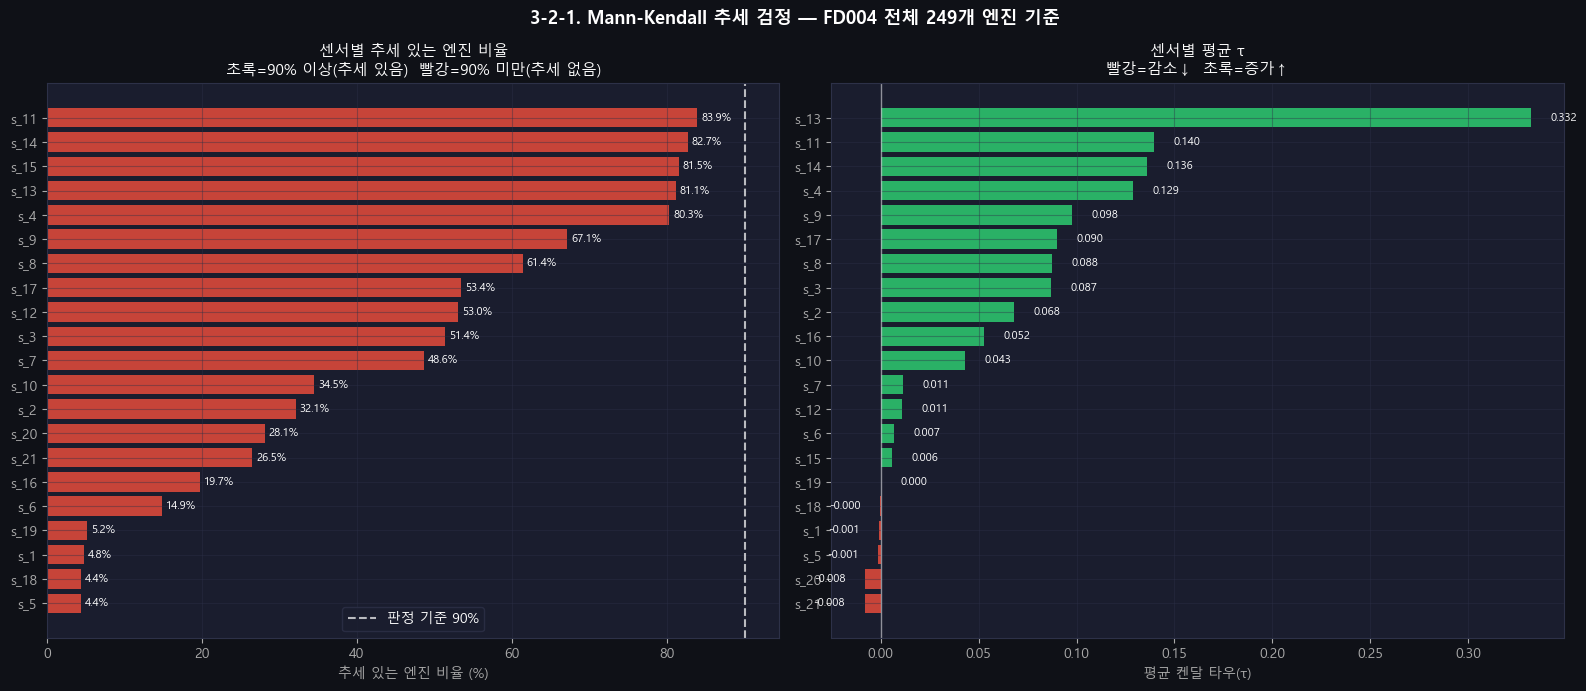


90% 이상 엔진에서 추세 있는 센서: 0/21개


In [18]:
# 3-2-1. Mann-Kendall 추세 검정 — 전체 엔진 기준
print('=== 3-2-1. Mann-Kendall 추세 검정 (전체 엔진) ===')

all_units = train_raw['unit_nr'].unique()  # 249개 엔진
results = {s: [] for s in all_sensors}

for unit in all_units:
    unit_df = train_raw[train_raw['unit_nr'] == unit].sort_values('time_cycles')
    for s in all_sensors:
        arr = unit_df[s].values
        time_idx = np.arange(len(arr))
        tau, p_val = kendalltau(time_idx, arr)
        if np.isfinite(tau):  # NaN 제외
            results[s].append({'tau': tau, 'p_val': p_val})

# 센서별 집계
mk_rows = []
for s in all_sensors:
    taus = [r['tau'] for r in results[s]]
    p_vals = [r['p_val'] for r in results[s]]
    n_valid = len(results[s])
    n_significant = sum(p < 0.05 for p in p_vals)
    
    sig_ratio = n_significant / n_valid if n_valid > 0 else np.nan
    
    mk_rows.append({
        '센서': s,
        '유효 엔진 수': n_valid,
        '추세 있는 엔진 수': n_significant,
        '비율(%)': round(sig_ratio * 100, 1) if np.isfinite(sig_ratio) else np.nan,
        '평균 τ': round(np.mean(taus), 4) if taus else np.nan,
        '추세 방향': '증가↑' if np.mean(taus) > 0 else '감소↓' if taus else '-',
        '판정': '추세 있음✅' if np.isfinite(sig_ratio) and sig_ratio >= 0.9 else '추세 없음⚠️'
    })

mk_df = pd.DataFrame(mk_rows).set_index('센서')
display(mk_df.sort_values('비율(%)', ascending=False, na_position='last'))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-2-1. Mann-Kendall 추세 검정 — FD004 전체 249개 엔진 기준',
             fontsize=13, fontweight='bold')

# 왼쪽: 추세 있는 엔진 비율
mk_sorted = mk_df.sort_values('비율(%)', ascending=True, na_position='first')
ratio_vals = mk_sorted['비율(%)'].fillna(0).values
colors_ratio = ['#e74c3c' if (pd.isna(v) or v < 90) else '#2ecc71'
                for v in mk_sorted['비율(%)']]
axes[0].barh(mk_sorted.index, ratio_vals, color=colors_ratio, alpha=0.85)
axes[0].axvline(90, color='white', lw=1.5, linestyle='--', alpha=0.7, label='판정 기준 90%')
axes[0].set_xlabel('추세 있는 엔진 비율 (%)')
axes[0].set_title('센서별 추세 있는 엔진 비율\n초록=90% 이상(추세 있음)  빨강=90% 미만(추세 없음)')
axes[0].legend()
for bar, val in zip(axes[0].patches, mk_sorted['비율(%)']):
    label = f'{val}%' if pd.notna(val) else 'NaN'
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=8)

# 오른쪽: 평균 켄달 타우
mk_sorted2 = mk_df.sort_values('평균 τ', ascending=True, na_position='first')
tau_vals = mk_sorted2['평균 τ'].fillna(0).values
colors_tau = ['#e74c3c' if (pd.isna(v) or v < 0) else '#2ecc71'
              for v in mk_sorted2['평균 τ']]
axes[1].barh(mk_sorted2.index, tau_vals, color=colors_tau, alpha=0.85)
axes[1].axvline(0, color='white', lw=1, alpha=0.5)
axes[1].set_xlabel('평균 켄달 타우(τ)')
axes[1].set_title('센서별 평균 τ\n빨강=감소↓  초록=증가↑')
for bar, val in zip(axes[1].patches, mk_sorted2['평균 τ']):
    if pd.isna(val):
        continue
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

n_trend = (mk_df['비율(%)'] >= 90).sum()
print(f'\n90% 이상 엔진에서 추세 있는 센서: {n_trend}/21개')

### 📊 3-2-1. Mann-Kendall 추세 검정 결과 (전체 엔진 기준)

---

#### 센서별 추세 검정 요약

**추세 있음 ✅ (비율 ≥ 90%)**
- **해당 없음 → 0/21개**

**추세 없음 ⚠️ (전체 21개)**
| 센서 | 비율(%) | 평균 τ | 방향 | 비고 |
|------|---------|--------|------|------|
| s_11 | 83.9 | 0.1396 | 증가↑ | 가장 높은 비율 |
| s_14 | 82.7 | 0.1360 | 증가↑ | |
| s_15 | 81.5 | 0.0059 | 증가↑ | |
| s_13 | 81.1 | 0.3319 | 증가↑ | τ값 가장 높음 |
| s_4 | 80.3 | 0.1289 | 증가↑ | |
| s_9 | 67.1 | 0.0975 | 증가↑ | |
| s_8 | 61.4 | 0.0876 | 증가↑ | |
| s_17 | 53.4 | 0.0898 | 증가↑ | |
| s_12 | 53.0 | 0.0108 | 증가↑ | |
| s_3 | 51.4 | 0.0868 | 증가↑ | |
| s_7 | 48.6 | 0.0113 | 증가↑ | |
| s_10 | 34.5 | 0.0428 | 증가↑ | |
| s_2 | 32.1 | 0.0680 | 증가↑ | |
| s_20 | 28.1 | -0.0080 | 감소↓ | |
| s_21 | 26.5 | -0.0082 | 감소↓ | |
| s_16 | 19.7 | 0.0525 | 증가↑ | 상수 센서 후보 |
| s_6 | 14.9 | 0.0069 | 증가↑ | |
| s_19 | 5.2 | 0.0001 | 증가↑ | 거의 상수 |
| s_1 | 4.8 | -0.0009 | 감소↓ | 거의 상수 |
| s_5 | 4.4 | -0.0013 | 감소↓ | 거의 상수 |
| s_18 | 4.4 | -0.0004 | 감소↓ | 거의 상수 |

---

#### FD001~003 대비 비교
| 항목 | FD001 | FD002 | FD003 | FD004 |
|------|-------|-------|-------|-------|
| 추세 있는 센서 수 | - | - | 15개 | **0개** |
| 최고 비율 센서 | - | - | s_2(100%) | **s_11(83.9%)** |
| 전반적 트렌드 수준 | 강함 | 약함 | 강함 | **매우 약함** |

---

#### 🔑 핵심 결론
> **90% 기준 추세 있는 센서 0/21개 → FD003(15개)과 극명한 대조**  
> → 운전조건 6가지 혼재로 열화 트렌드가 조건 노이즈에 완전히 묻혀있는 상태  
> → FD002와 동일한 패턴  
> **그러나 s_11, s_14, s_13, s_4는 비율 80% 이상으로 트렌드 신호 존재**  
> → 클러스터별 정규화 후 트렌드가 뚜렷해질 것으로 예상  
> **s_1, s_5, s_18, s_19는 비율 5% 미만 → 거의 상수에 가까움**  
> → 제거 후보로 추가 확인 필요  
> **Gaussian 스무딩 적용 근거는 3-2-2 클러스터별 분석에서 확보 예정**

**3-2-2. 클러스터별 ★ FD004 전용**
- **H₀**: 운전조건 클러스터별로 센서값의 열화 트렌드에 차이가 없다
- **H₁**: 운전조건 클러스터별로 열화 트렌드가 유의미하게 다르다
- 목적: 운전조건마다 열화 트렌드가 다른지 확인
- 판정 기준:
  - 유의 엔진 비율 ≥ 70% → 강한 트렌드 (파란색)
  - 유의 엔진 비율 40~70% → 약한 트렌드 (노란색)
  - 유의 엔진 비율 < 40% → 트렌드 없음 (빨간색)
- 클러스터별로 트렌드가 뚜렷하게 나타나면 → 클러스터별 정규화 후 Gaussian 스무딩 적용 근거 강화
- 클러스터별로 트렌드 패턴이 유사하면 → 동일 σ 값 적용 가능 근거

=== 3-2-2. Mann-Kendall 검정 (클러스터별) ===


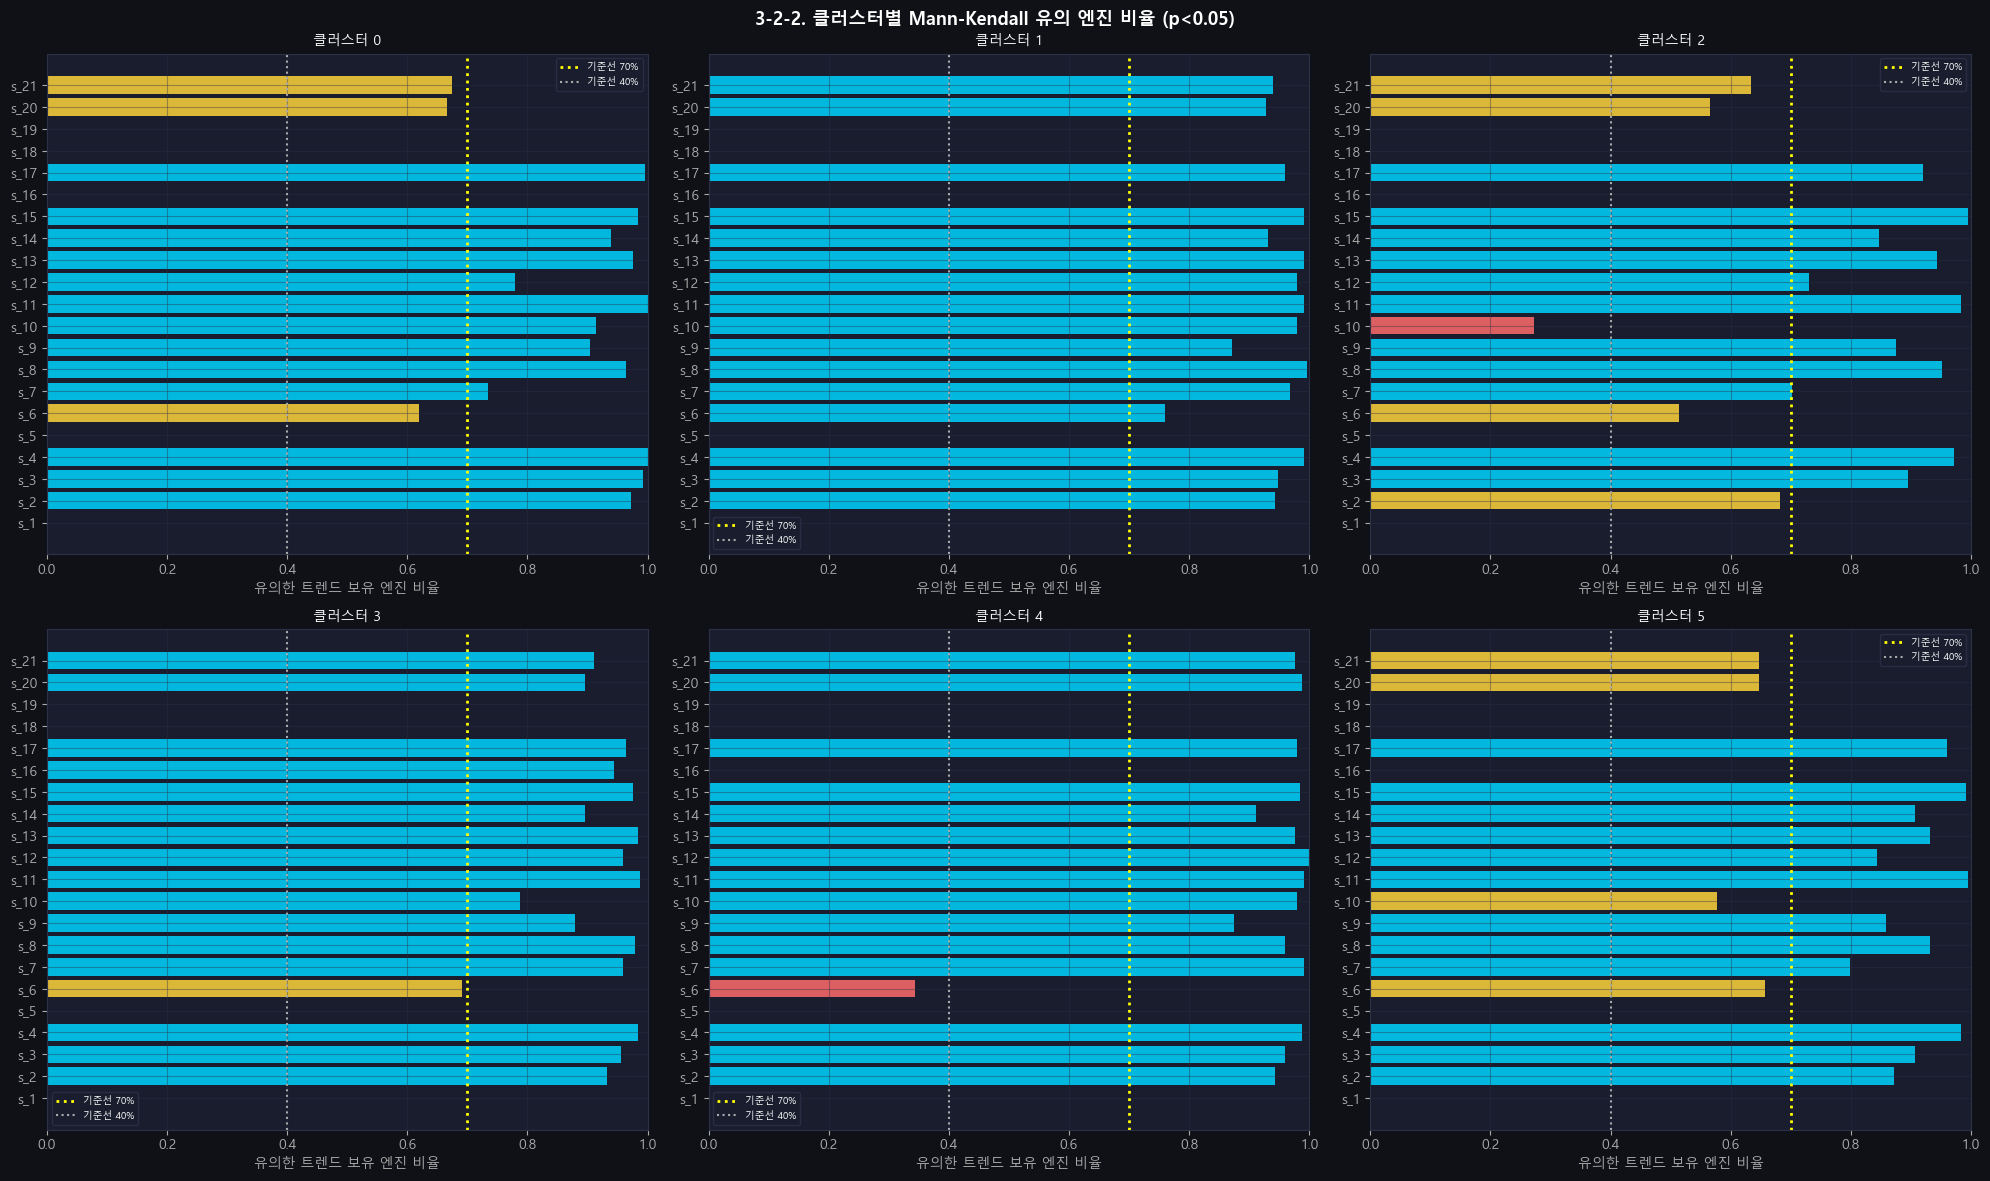


--- 클러스터별 강한 트렌드 센서 (유의 비율 ≥ 0.7) ---
클러스터 0: 13개 → ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17']
클러스터 1: 16개 → ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
클러스터 2: 11개 → ['s_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17']
클러스터 3: 16개 → ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_20', 's_21']
클러스터 4: 15개 → ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
클러스터 5: 12개 → ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17']


In [19]:
# 3-2-2. Mann-Kendall 추세 검정 — 클러스터별 ★ FD004 전용
print('=== 3-2-2. Mann-Kendall 검정 (클러스터별) ===')

def mann_kendall(series):
    t = np.arange(len(series))
    tau, p = kendalltau(t, series)
    return tau, p

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('3-2-2. 클러스터별 Mann-Kendall 유의 엔진 비율 (p<0.05)',
             fontsize=13, fontweight='bold')

mk_cluster_summary = {}

for c, ax in zip(range(N_CLUSTERS), axes.flat):
    sub_c = train_eda[train_eda['cluster'] == c]
    mk_rows = []

    for s in SENSOR_COLS:
        taus, ps = [], []
        for uid in sub_c['unit_nr'].unique():
            arr = (sub_c[sub_c['unit_nr'] == uid]
                   .sort_values('time_cycles')[s].values)
            if len(arr) >= 8:
                tau, p = mann_kendall(arr)
                if np.isfinite(tau):
                    taus.append(tau)
                    ps.append(p)

        mean_tau = np.mean(taus) if taus else np.nan
        sig_ratio = np.mean([p < 0.05 for p in ps]) if ps else np.nan
        mk_rows.append({
            '센서': s,
            '평균 τ': round(mean_tau, 4),
            '유의 엔진 비율': sig_ratio
        })

    mk_df = pd.DataFrame(mk_rows).set_index('센서')
    mk_cluster_summary[c] = mk_df

    # 시각화
    sig_vals = mk_df['유의 엔진 비율'].fillna(0).values
    bc = [C[0] if v >= 0.7 else C[3] if v >= 0.4 else C[1] for v in sig_vals]
    ax.barh(SENSOR_COLS, sig_vals, color=bc, alpha=0.85)
    ax.axvline(0.7, color='yellow', lw=2, ls=':', label='기준선 70%')
    ax.axvline(0.4, color=GRAY, lw=1.5, ls=':', label='기준선 40%')
    ax.set_title(f'클러스터 {c}', fontsize=10)
    ax.set_xlabel('유의한 트렌드 보유 엔진 비율')
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)

plt.tight_layout(); plt.show()

# 클러스터별 강한 트렌드 센서 요약
print('\n--- 클러스터별 강한 트렌드 센서 (유의 비율 ≥ 0.7) ---')
for c in range(N_CLUSTERS):
    strong = mk_cluster_summary[c][mk_cluster_summary[c]['유의 엔진 비율'] >= 0.7]
    print(f'클러스터 {c}: {len(strong)}개 → {list(strong.index)}')

### 📊 3-2-2. Mann-Kendall 추세 검정 결과 (클러스터별) ★ FD004 전용

---

#### 클러스터별 강한 트렌드 센서 (유의 비율 ≥ 0.7)

| 클러스터 | 강한 트렌드 센서 수 | 센서 목록 |
|---------|-----------------|---------|
| 0 | 13개 | s_2, s_3, s_4, s_7, s_8, s_9, s_10, s_11, s_12, s_13, s_14, s_15, s_17 |
| 1 | 16개 | s_2, s_3, s_4, s_6, s_7, s_8, s_9, s_10, s_11, s_12, s_13, s_14, s_15, s_17, s_20, s_21 |
| 2 | 11개 | s_3, s_4, s_7, s_8, s_9, s_11, s_12, s_13, s_14, s_15, s_17 |
| 3 | 16개 | s_2, s_3, s_4, s_7, s_8, s_9, s_10, s_11, s_12, s_13, s_14, s_15, s_16, s_17, s_20, s_21 |
| 4 | 15개 | s_2, s_3, s_4, s_7, s_8, s_9, s_10, s_11, s_12, s_13, s_14, s_15, s_17, s_20, s_21 |
| 5 | 12개 | s_2, s_3, s_4, s_7, s_8, s_9, s_11, s_12, s_13, s_14, s_15, s_17 |

---

#### 3-2-1 전체 분석 대비 큰 변화 ★

| 항목 | 3-2-1 전체 기준 | 3-2-2 클러스터별 |
|------|--------------|----------------|
| 강한 트렌드 센서 수 | 0개 | **11~16개** |
| 최고 비율 | 83.9% (s_11) | **대부분 100%에 가까움** |

> 📌 전체 기준에서 0개였던 강한 트렌드 센서가 클러스터별로 보면 11~16개로 급증  
> → 운전조건 클러스터별로 분리하면 열화 트렌드가 뚜렷하게 드러남  
> → 클러스터별 정규화 필요성이 Mann-Kendall 검정에서도 증명됨

---

#### 주목할 패턴

**모든 클러스터에서 공통으로 강한 트렌드 센서**
- s_3, s_4, s_7, s_8, s_9, s_11, s_12, s_13, s_14, s_15, s_17
- → 운전조건에 관계없이 열화 신호가 일관되게 존재하는 핵심 센서

**클러스터별 차이 ⚠️**
- s_6: 클러스터 1에서만 강한 트렌드 → 특정 운전조건에서만 열화 신호 존재
- s_6: 클러스터 4에서 빨간색(낮은 비율) → 조건에 따라 트렌드 반응이 다름
- s_10: 클러스터 2에서 빨간색 → 특정 조건에서 트렌드 없음
- s_16: 클러스터 3에서만 강한 트렌드 → 상수 센서 후보이나 특정 조건에서 변동
- s_20, s_21: 클러스터 1, 3, 4에서만 강한 트렌드

**s_1, s_5, s_18, s_19**
- 모든 클러스터에서 트렌드 없음 → 상수 센서 확정 근거 추가 확보

---

#### 🔑 핵심 결론
> **클러스터별 분리 시 강한 트렌드 센서 11~16개로 급증 → 클러스터별 정규화 효과 검정으로 증명**  
> **s_3, s_4, s_7, s_8, s_9, s_11, s_12, s_13, s_14, s_15, s_17 → 모든 조건에서 열화 신호 일관성 확인**  
> **s_1, s_5, s_18, s_19 → 모든 클러스터에서 트렌드 없음 → 상수 센서 제거 근거 강화**  
> **s_6은 클러스터별 트렌드 반응이 달라 수동 처리 여부 통계 검정 후 최종 결정 필요**  
> **Gaussian 스무딩 적용 근거 확보 → 클러스터별로 열화 트렌드 존재 확인됨**  
> → σ=2 기본값 유지, σ=3 실험값으로 추가 테스트 예정

---

#### 3-3. 대응 표본 검정 (Paired t / Wilcoxon)
- **H₀**: 수명 80% 이전과 이후 구간의 센서 평균에 차이가 없다
- **H₁**: 수명 80% 이후 구간에서 센서 평균이 유의미하게 달라진다
- Shapiro-Wilk 정규성 검정 후 정규분포면 Paired t-test, 아니면 Wilcoxon 적용
- 운전조건 + 고장 모드 2가지 혼재로 FD003보다 분산이 클 수 있음 → 결과 해석 시 주의

=== 3-3. 대응 표본 검정 ===
목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정



,정상구간 평균 (수명 80% 이전),열화구간 평균 (마지막 20%),평균 차이(Δ),검정 방법,p-value,변화 방향,판정
센서,,,,,,,
s_1,472.9264,472.6999,0.2265,Paired t-test,0.3807,감소↓,차이 없음⚠️
s_2,579.3690,579.7918,-0.4228,Paired t-test,0.2512,증가↑,차이 없음⚠️
s_3,1416.5254,1425.1430,-8.6176,Paired t-test,0.0000,증가↑,차이 있음✅
s_4,1199.9739,1213.0065,-13.0326,Paired t-test,0.0000,증가↑,차이 있음✅
s_5,8.0392,8.0004,0.0387,Paired t-test,0.2739,감소↓,차이 없음⚠️
s_6,11.6013,11.5498,0.0515,Paired t-test,0.3331,감소↓,차이 없음⚠️
s_7,283.1704,283.2796,-0.1092,Paired t-test,0.9401,증가↑,차이 없음⚠️
s_8,2228.4395,2229.4525,-1.0130,Paired t-test,0.4909,증가↑,차이 없음⚠️
s_9,8519.2587,8543.4006,-24.1419,Paired t-test,0.0000,증가↑,차이 있음✅


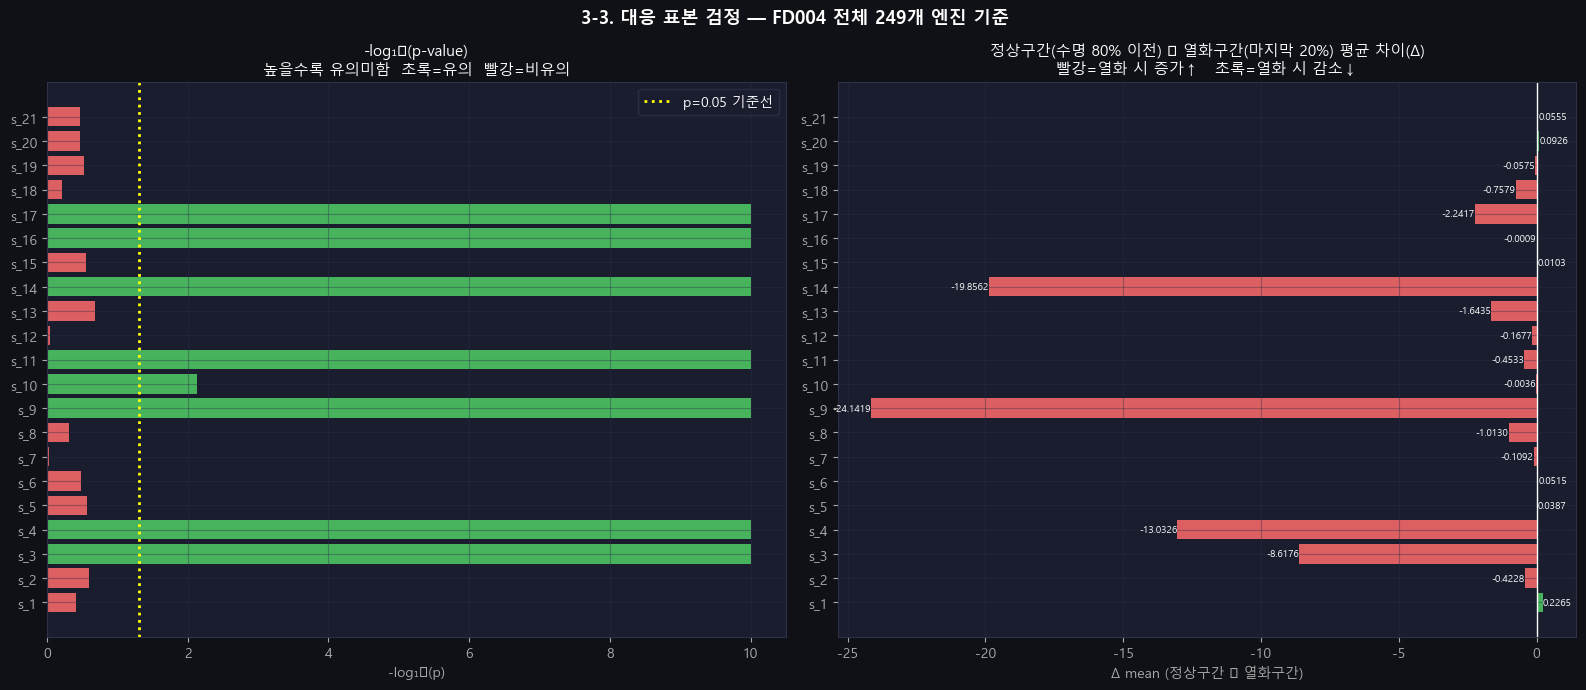


유의미한 차이 있는 센서 (p<0.05): 8/21개
사용된 검정: {'Paired t-test': 21}


In [20]:

print('=== 3-3. 대응 표본 검정 ===')
print('목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정')
print()

# RUL 임시 생성
tr_paired = train_raw.copy()
mc = tr_paired.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_paired = tr_paired.join(mc, on='unit_nr')
tr_paired['RUL'] = tr_paired['max_c'] - tr_paired['time_cycles']

ttest_rows = []
for s in all_sensors:
    before_means = []
    after_means  = []

    for unit in train_raw['unit_nr'].unique():
        sub = tr_paired[tr_paired['unit_nr'] == unit].sort_values('time_cycles')
        threshold = sub['RUL'].quantile(0.20)

        before = sub[sub['RUL'] >  threshold][s].mean()
        after  = sub[sub['RUL'] <= threshold][s].mean()

        if np.isfinite(before) and np.isfinite(after):
            before_means.append(before)
            after_means.append(after)

    diffs = np.array(before_means) - np.array(after_means)

    # Shapiro-Wilk 정규성 검정
    _, p_sw = shapiro(diffs) if len(diffs) >= 3 else (np.nan, 0.0)

    if p_sw > 0.05:
        stat, p_val = ttest_rel(before_means, after_means)
        test_name = 'Paired t-test'
    else:
        stat, p_val = wilcoxon(diffs)
        test_name = 'Wilcoxon'

    ttest_rows.append({
        '센서': s,
        '정상구간 평균 (수명 80% 이전)': round(np.mean(before_means), 4),
        '열화구간 평균 (마지막 20%)': round(np.mean(after_means), 4),
        '평균 차이(Δ)': round(float(np.mean(diffs)), 4),
        '검정 방법': test_name,
        'p-value': round(p_val, 4) if np.isfinite(p_val) else np.nan,
        '변화 방향': '증가↑' if np.mean(diffs) < 0 else '감소↓',
        '판정': '차이 있음✅' if (np.isfinite(p_val) and p_val < 0.05) else '차이 없음⚠️'
    })

ttest_df = pd.DataFrame(ttest_rows).set_index('센서')
display(ttest_df)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-3. 대응 표본 검정 — FD004 전체 249개 엔진 기준',
             fontsize=13, fontweight='bold')

# 왼쪽: -log10(p-value)
p_vals = ttest_df['p-value'].values
log_p = -np.log10(np.clip(np.nan_to_num(p_vals, nan=1.0), 1e-10, 1))
bc_p = [C[1] if (np.isnan(p) or p >= 0.05) else C[2] for p in p_vals]
axes[0].barh(ttest_df.index, log_p, color=bc_p, alpha=0.85)
axes[0].axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05 기준선')
axes[0].set_title('-log₁₀(p-value)\n높을수록 유의미함  초록=유의  빨강=비유의')
axes[0].set_xlabel('-log₁₀(p)')
axes[0].legend()

# 오른쪽: 평균 차이(Δ)
diff_vals = ttest_df['평균 차이(Δ)'].values
bc_d = [C[1] if v < 0 else C[2] for v in diff_vals]
axes[1].barh(ttest_df.index, diff_vals, color=bc_d, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].set_title('정상구간(수명 80% 이전) − 열화구간(마지막 20%) 평균 차이(Δ)\n빨강=열화 시 증가↑   초록=열화 시 감소↓')
axes[1].set_xlabel('Δ mean (정상구간 − 열화구간)')
for bar, val in zip(axes[1].patches, diff_vals):
    if val == 0:
        continue
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=7)

plt.tight_layout()
plt.show()

n_sig = (ttest_df['판정'] == '차이 있음✅').sum()
print(f'\n유의미한 차이 있는 센서 (p<0.05): {n_sig}/21개')
print(f"사용된 검정: {ttest_df['검정 방법'].value_counts().to_dict()}")

### 📊 3-3. 대응 표본 검정 결과

---

#### 검정 결과 요약
- 유의미한 차이 있는 센서 (p<0.05): **8/21개**
- 사용된 검정: Paired t-test 21개
- FD003(17/21개) 대비 크게 감소 → 운전조건 혼재로 Δ값이 희석된 것으로 해석

---

#### 차이 있음 ✅ (8개)

| 센서 | 정상구간 평균 | 열화구간 평균 | Δ | 방향 | p-value |
|------|------------|------------|---|------|---------|
| s_3 | 1416.5254 | 1425.1430 | -8.6176 | 증가↑ | 0.0000 |
| s_4 | 1199.9739 | 1213.0065 | -13.0326 | 증가↑ | 0.0000 |
| s_9 | 8519.2587 | 8543.4006 | -24.1419 | 증가↑ | 0.0000 |
| s_10 | 1.0954 | 1.0991 | -0.0036 | 증가↑ | 0.0074 |
| s_11 | 42.8050 | 43.2584 | -0.4533 | 증가↑ | 0.0000 |
| s_14 | 8063.0553 | 8082.9115 | -19.8562 | 증가↑ | 0.0000 |
| s_16 | 0.0231 | 0.0240 | -0.0009 | 증가↑ | 0.0000 |
| s_17 | 347.4059 | 349.6476 | -2.2417 | 증가↑ | 0.0000 |

#### 차이 없음 ⚠️ (13개)

| 센서 | p-value | 비고 |
|------|---------|------|
| s_1 | 0.3807 | 상수 센서 후보 |
| s_2 | 0.2512 | |
| s_5 | 0.2739 | 상수 센서 후보 |
| s_6 | 0.3331 | ⚠️ 제거 근거 추가 확보 |
| s_7 | 0.9401 | |
| s_8 | 0.4909 | |
| s_12 | 0.9026 | |
| s_13 | 0.2104 | |
| s_15 | 0.2808 | |
| s_18 | 0.6061 | 상수 센서 후보 |
| s_19 | 0.2944 | 상수 센서 후보 |
| s_20 | 0.3440 | |
| s_21 | 0.3438 | |

---

#### 주의사항 ⚠️
> FD004는 운전조건 6가지 혼재로 같은 엔진의 수명 구간별로 운전조건이 섞여있음  
> → 수명 80% 전후 비교가 순수한 열화 영향이 아닌 운전조건 변화도 포함  
> → FD003(17/21개) 대비 유의한 센서가 8/21개로 감소한 주요 원인

#### s_6 추가 분석
> s_6 p-value=0.3331 → 차이 없음  
> 2-6 RUL 상관 ≈ 0, 3-2-1 Mann-Kendall 비율 14.9%, 3-3 차이 없음  
> → **제거 근거 3개 확보** → 통계 검정 종합 후 최종 결정 예정

#### s_16 특이사항
> s_16 p=0.0000으로 유의하게 나왔으나 Δ=-0.0009로 실질적 차이 매우 미미  
> → 상수 센서에 가까워 통계적 유의성이 실제 열화 신호를 의미하지 않음  
> → 제거 후보 유지

---

#### 🔑 핵심 결론
> **유의한 센서 8/21개 → FD003(17개) 대비 감소, 운전조건 혼재 영향**  
> **s_3, s_4, s_9, s_11, s_14, s_17 → 열화 시 증가하는 핵심 센서 확인**  
> **s_10 p=0.0074로 유의 → FD003과 동일하게 유지 근거 확보**  
> **s_6 p=0.3331 차이 없음 → 제거 근거 추가 확보**  
> **s_1, s_5, s_18, s_19 차이 없음 → 상수 센서 제거 근거 재확인**  
> **s_7, s_8, s_12, s_13, s_20, s_21 차이 없음 → 운전조건 영향 희석으로 추정**  
> → 클러스터별 정규화 후 유의한 센서 수 증가 예상

---

#### 3-4. RUL Cap 검증
- **H₀**: RUL Cap 값에 따라 RUL 분포의 균등성에 차이가 없다
- **H₁**: 특정 Cap 값에서 RUL 분포가 더 균등해진다 (엔트로피 최대)
- 실험 범위: Cap = 115, 120, 125, 130, 135, 140, 145
- 판단 기준: 모든 엔진이 Cap을 초과하면서 엔트로피가 가장 높은 Cap 값을 최적값으로 선정
- FD003 결과에서 Cap=125가 최적이었음 → FD004도 동일할 것으로 예상하나 수명 분포 확인 필요

=== 3-4. RUL Cap 검증 (115 vs 120 vs 125 vs 130 vs 135 vs 140 vs 145) ===
--- cap별 초과 엔진 비율 ---
  cap=115: 100.0% 엔진 초과
  cap=120: 100.0% 엔진 초과
  cap=125: 100.0% 엔진 초과
  cap=130: 99.6% 엔진 초과
  cap=135: 98.8% 엔진 초과
  cap=140: 98.4% 엔진 초과
  cap=145: 97.6% 엔진 초과


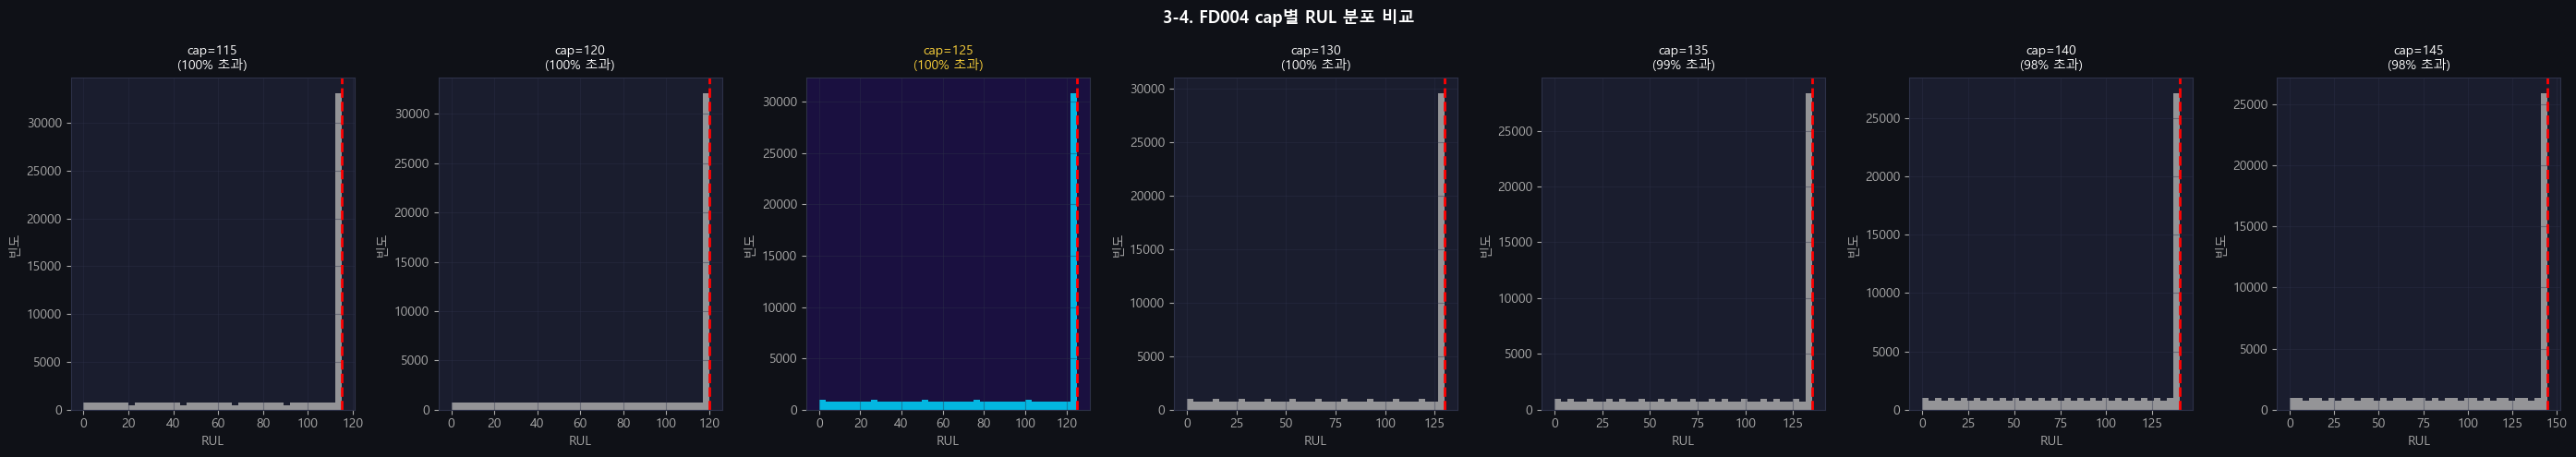


--- cap별 RUL 분포 균등성 (엔트로피, 높을수록 균등) ---
  cap=115: 엔트로피=2.4689
  cap=120: 엔트로피=2.5495
  cap=125: 엔트로피=2.6292
  cap=130: 엔트로피=2.7081
  cap=135: 엔트로피=2.7857
  cap=140: 엔트로피=2.8621
  cap=145: 엔트로피=2.9372

📌 FD004 min 수명=128 → cap=145에서 정상 구간 경계 도달
   cap=145 초과 비율 확인 후 최적 cap 결정 예정


In [21]:
# 3-4. RUL Cap 검증
print('=== 3-4. RUL Cap 검증 (115 vs 120 vs 125 vs 130 vs 135 vs 140 vs 145) ===')

tr_cap = train_raw.copy()
mc = tr_cap.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_cap = tr_cap.join(mc, on='unit_nr')
tr_cap['RUL_raw'] = tr_cap['max_c'] - tr_cap['time_cycles']

caps = [115, 120, 125, 130, 135, 140, 145]
lifecycles = tr_cap.groupby('unit_nr')['max_c'].first()

# ① cap별 초과 엔진 비율
print('--- cap별 초과 엔진 비율 ---')
for cap in caps:
    pct = (lifecycles > cap).mean() * 100
    print(f'  cap={cap}: {pct:.1f}% 엔진 초과')

# ② cap별 RUL 분포 비교
fig, axes = plt.subplots(1, 7, figsize=(28, 5), sharey=False)
fig.suptitle('3-4. FD004 cap별 RUL 분포 비교', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    rul_capped = tr_cap['RUL_raw'].clip(upper=cap)
    pct = (lifecycles > cap).mean() * 100
    ax.hist(rul_capped, bins=40, color=C[0] if cap==125 else GRAY,
            alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'cap={cap}\n({pct:.0f}% 초과)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=10)
    ax.set_xlabel('RUL')
    ax.set_ylabel('빈도')
    if cap == 125:
        ax.patch.set_facecolor('#1a1040')

plt.tight_layout(); plt.show()

# ③ cap별 RUL 분포 균등성 (엔트로피)
from scipy.stats import entropy

print('\n--- cap별 RUL 분포 균등성 (엔트로피, 높을수록 균등) ---')
for cap in caps:
    rul_capped = tr_cap['RUL_raw'].clip(upper=cap)
    hist, _ = np.histogram(rul_capped, bins=50)
    hist = hist / hist.sum()
    ent = entropy(hist + 1e-10)
    print(f'  cap={cap}: 엔트로피={ent:.4f}')

print('\n📌 FD004 min 수명=128 → cap=145에서 정상 구간 경계 도달')
print('   cap=145 초과 비율 확인 후 최적 cap 결정 예정')

### 📊 3-4. RUL Cap 검증 결과

---

#### cap별 초과 엔진 비율 & 엔트로피

| Cap | 초과 비율 | 엔트로피 | 비고 |
|-----|---------|---------|------|
| 115 | 100.0% | 2.4689 | |
| 120 | 100.0% | 2.5495 | |
| 125 | 100.0% | 2.6292 | ← 현재 기본값 |
| 130 | 99.6% | 2.7081 | ⚠️ 1개 엔진 정상구간 침범 시작 |
| 135 | 98.8% | 2.7857 | ⚠️ 3개 엔진 정상구간 침범 |
| 140 | 98.4% | 2.8621 | ⚠️ 4개 엔진 정상구간 침범 |
| 145 | 97.6% | 2.9372 | ⚠️ 6개 엔진 정상구간 침범 |

> 📌 안전한 cap 범위: 115~125 (100% 초과)  
> 📌 cap=130부터 정상구간 침범 시작 → 130 이상은 위험

---

#### FD001~003 대비 비교

| 항목 | FD002 | FD003 | FD004 |
|------|-------|-------|-------|
| 안전한 cap 범위 | 115~125 (100%) | 115~140 (100%) | **115~125 (100%)** |
| cap=130 초과 비율 | 99.6% | 100% | **99.6%** |
| cap=140 초과 비율 | - | 100% | **98.4%** |
| min 수명 | 128 | 145 | **128** |

> 📌 FD004는 min 수명=128로 FD002와 동일  
> → cap=130부터 정상구간 침범 패턴도 FD002와 동일  
> → FD003은 min 수명=145라 cap=140까지 안전했으나 FD004/FD002는 cap=125가 최대값  
> **→ cap=125 확정 근거: FD002와 동일한 패턴으로 재확인됨**

---

#### 히스토그램 해석
- cap=115~125: 왼쪽으로 치우친 분포 → cap 값에 데이터가 크게 쌓임
- cap=130 이상: cap 값 이후 구간에 실제 데이터 존재 → 정상구간 침범 확인
- cap=125(파란색): 100% 초과 유지하면서 가장 균등한 분포

---

#### 🔑 핵심 결론
> **cap=115~125만 100% 초과 → cap=125가 안전한 최대값으로 확정**  
> **cap=130부터 정상구간 침범 → FD002와 동일한 패턴 (min 수명=128 동일)**  
> → FD003은 min 수명=145라 cap=140까지 안전했으나 FD004는 FD002와 동일하게 cap=125가 한계  
> **엔트로피는 cap이 높을수록 증가하지만 정상구간 침범 리스크가 더 큼**  
> → cap=125 확정, 상향 실험 불필요  
> **FD001~004 모두 Cap=125로 공통 확정**

---
#### 3-5. Gaussian σ 검증

**3-5-1. 전체 기준**
- **H₀**: σ 값에 따라 센서 노이즈 수준에 차이가 없다
- **H₁**: σ 값이 클수록 노이즈가 유의미하게 감소한다
- 실험 범위: σ = 0, 1, 2, 3
- 판단 기준: 노이즈(std of diff) 감소 효과가 크면서 열화 트렌드가 유지되는 최적 σ 선정
- FD003(σ=2→3에서 37% 추가 감소)과 FD002(σ=2→3에서 25% 추가 감소) 결과와 비교
- FD004는 운전조건 + 고장 모드 혼재로 FD003보다 노이즈가 더 심할 수 있음
  → σ=3이 더 유리할 가능성 있음

=== 3-5-1. 가우시안 σ 검증 (전체 기준) ===


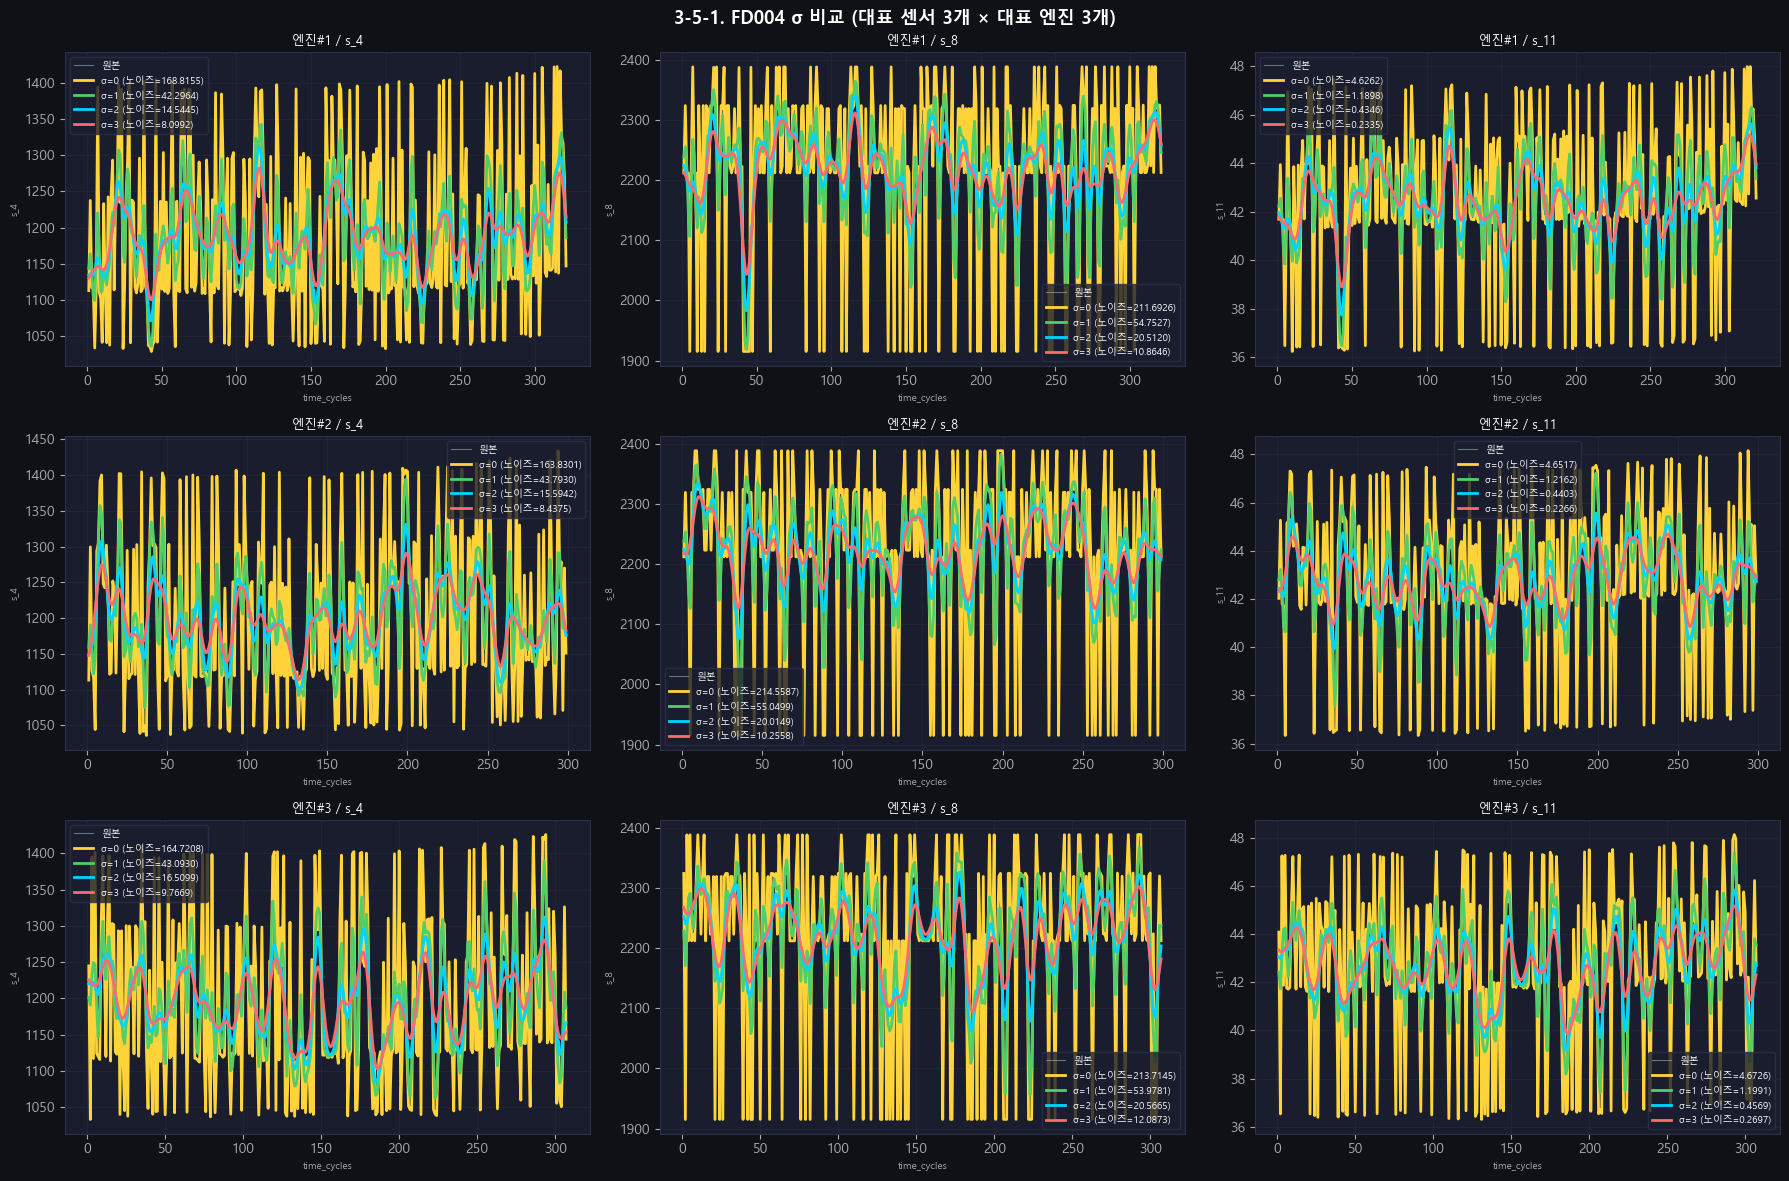


--- σ에 따른 평균 노이즈 수준 (std of diff) ---
  σ=0: 평균 노이즈=99.7858
  σ=1: 평균 노이즈=24.7268
  σ=2: 평균 노이즈=9.1161
  σ=3: 평균 노이즈=5.0762

📌 σ=2 기본값 유지, 노이즈 감소 효과 확인
   운전조건 + 고장 모드 2가지 혼재로 σ=3 추가 실험 예정


In [22]:
# 3-5-1. 가우시안 σ 검증 — 전체 기준
print('=== 3-5-1. 가우시안 σ 검증 (전체 기준) ===')

sigmas = [0, 1, 2, 3]
show_sensors = ['s_4', 's_8', 's_11']  # 대표 센서 3개 (RUL 상관 높은 것)
show_units = train_raw['unit_nr'].unique()[:3]  # 대표 엔진 3개

fig, axes = plt.subplots(len(show_units), len(show_sensors), figsize=(18, 12))
fig.suptitle('3-5-1. FD004 σ 비교 (대표 센서 3개 × 대표 엔진 3개)',
             fontsize=13, fontweight='bold')

for ri, uid in enumerate(show_units):
    udf = train_raw[train_raw['unit_nr'] == uid].sort_values('time_cycles')
    for ci, s in enumerate(show_sensors):
        ax = axes[ri, ci]
        raw = udf[s].values.astype(np.float32)
        ax.plot(udf['time_cycles'], raw,
                color=GRAY, lw=0.8, alpha=0.6, label='원본')
        for sig, color in zip(sigmas, [C[3], C[2], C[0], C[1]]):
            if sig == 0:
                smoothed = raw
            else:
                smoothed = gaussian_filter1d(raw, sigma=sig, mode='nearest')
            noise = np.std(np.diff(smoothed))
            ax.plot(udf['time_cycles'], smoothed,
                    color=color, lw=2, label=f'σ={sig} (노이즈={noise:.4f})')
        ax.set_title(f'엔진#{uid} / {s}', fontsize=9)
        ax.set_xlabel('time_cycles', fontsize=7)
        ax.set_ylabel(s, fontsize=7)
        ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# 전체 센서 노이즈 수준 비교
print('\n--- σ에 따른 평균 노이즈 수준 (std of diff) ---')
noise_by_sigma = {sig: [] for sig in sigmas}
for s in USEFUL_SENSORS if 'USEFUL_SENSORS' in dir() else SENSOR_COLS:
    for uid in train_raw['unit_nr'].unique()[:30]:
        arr = train_raw[train_raw['unit_nr']==uid].sort_values(
            'time_cycles')[s].values.astype(np.float32)
        for sig in sigmas:
            smoothed = gaussian_filter1d(arr, sigma=sig, mode='nearest') if sig > 0 else arr
            noise_by_sigma[sig].append(np.std(np.diff(smoothed)))

for sig in sigmas:
    print(f'  σ={sig}: 평균 노이즈={np.mean(noise_by_sigma[sig]):.4f}')

print('\n📌 σ=2 기본값 유지, 노이즈 감소 효과 확인')
print('   운전조건 + 고장 모드 2가지 혼재로 σ=3 추가 실험 예정')

### 📊 3-5-1. Gaussian σ 검증 결과 (전체 기준)

---

#### σ에 따른 평균 노이즈 수준 (std of diff)

| σ | 평균 노이즈 | 감소율 | 비고 |
|---|----------|--------|------|
| 0 | 99.7858 | - | 원본 |
| 1 | 24.7268 | 75.2% | 노이즈 대폭 감소 |
| 2 | 9.1161 | 90.9% | ← 현재 기본값 |
| 3 | 5.0762 | 94.9% | 추가 감소 |

---

#### 데이터셋별 σ 노이즈 감소 비교

| 구간 | FD002 | FD003 | FD004 |
|------|-------|-------|-------|
| σ=0→1 감소율 | - | 74.7% | **75.2%** |
| σ=1→2 감소율 | - | 60.0% | **63.1%** |
| σ=2→3 감소율 | 25% | 37% | **44.3%** |
| σ=0 원본 노이즈 | - | 1.2149 | **99.7858** |

> 📌 FD004 원본 노이즈(99.7858)가 FD003(1.2149)보다 압도적으로 높음  
> → 운전조건 6가지로 인한 급격한 조건 전환이 노이즈로 반영된 것

---

#### 시각화 해석
- σ=0(노란색): 운전조건 전환마다 급격한 진동 → 열화 트렌드 전혀 안 보임
- σ=1(초록색): 노이즈 크게 줄었으나 아직 조건 전환 진동 잔존
- σ=2(파란색): 트렌드가 보이기 시작하나 여전히 진동 존재
- σ=3(빨간색): σ=2 대비 추가 감소 효과 44.3% → FD003(37%)보다 효과 큼

---

#### 🔑 핵심 결론
> **FD004 원본 노이즈가 FD003 대비 약 82배 높음 → 운전조건 혼재 영향**  
> **σ=2→3 구간 감소율 44.3% → FD002(25%), FD003(37%)보다 큰 추가 감소 효과**  
> → FD004에서 σ=3이 더 유리할 가능성 높음  
> **단, σ 값 최종 결정은 클러스터별 정규화 후 열화 트렌드 유지 여부 확인 필요**  
> → σ=2 기본값 유지, σ=3 실험값으로 추가 테스트  
> → 3-5-2 클러스터별 분석에서 조건별 노이즈 수준 추가 확인 예정

**3-5-2. 클러스터별 ★ FD004 전용**
- **H₀**: 운전조건 클러스터별로 σ에 따른 노이즈 감소 효과에 차이가 없다
- **H₁**: 운전조건 클러스터별로 최적 σ가 다르다
- 실험 범위: σ = 1, 2, 3
- 목적: 운전조건마다 노이즈 수준이 다른지 확인
- 클러스터별 최적 σ가 다르면 → 조건마다 다른 σ 적용 검토 필요
- 클러스터별 최적 σ가 비슷하면 → 단일 σ 값 적용 가능 근거
- FD002에서 클러스터별 노이즈 수준 차이가 확인됐음 → FD004도 동일할 것으로 예상

=== 3-5-2. 가우시안 σ 검증 (클러스터별) ===


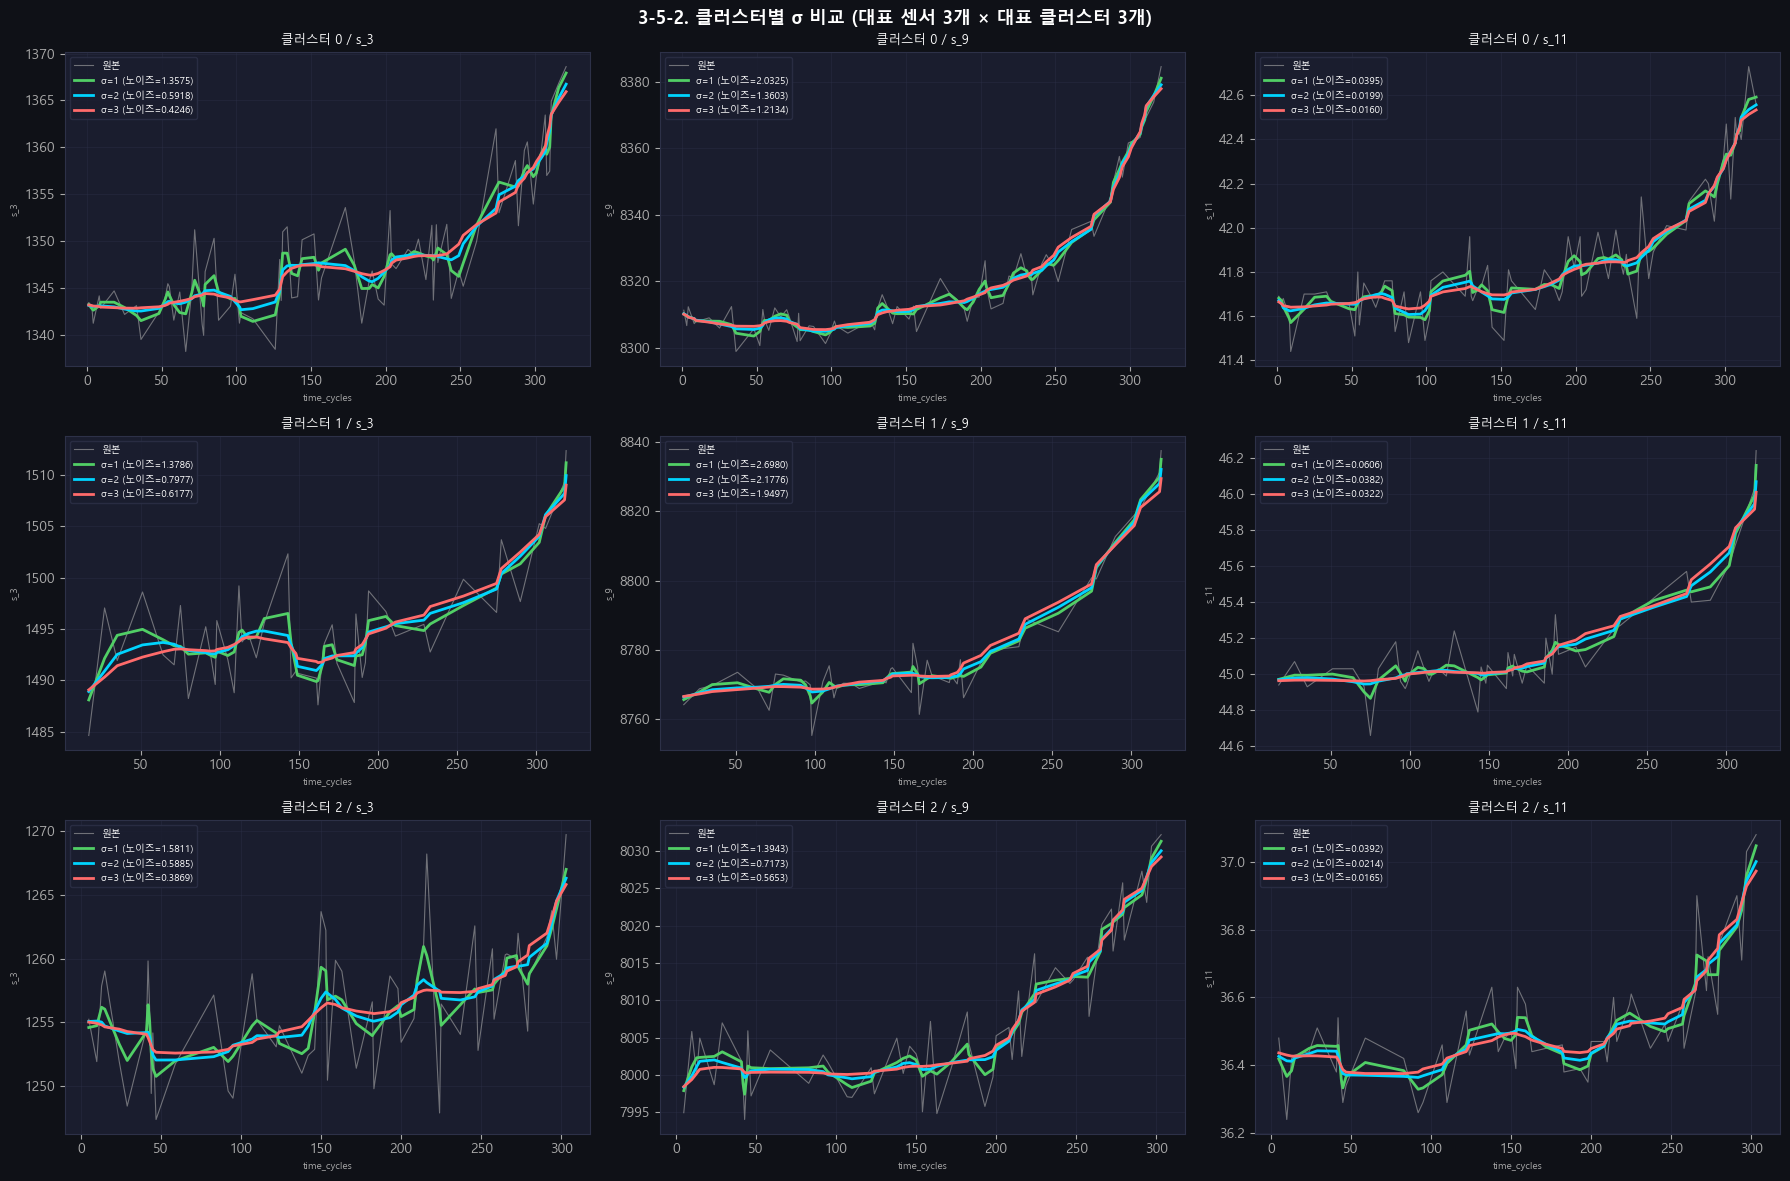


--- 클러스터별 σ에 따른 평균 노이즈 수준 (std of diff) ---
클러스터 0: σ=1: 0.3496  σ=2: 0.1799  σ=3: 0.1365  
클러스터 1: σ=1: 0.3822  σ=2: 0.2211  σ=3: 0.1744  
클러스터 2: σ=1: 0.3417  σ=2: 0.1738  σ=3: 0.1280  
클러스터 3: σ=1: 0.3706  σ=2: 0.2011  σ=3: 0.1534  
클러스터 4: σ=1: 0.4050  σ=2: 0.2344  σ=3: 0.1851  
클러스터 5: σ=1: 0.3778  σ=2: 0.2115  σ=3: 0.1607  

📌 클러스터별 노이즈 수준 차이 확인
   클러스터 간 σ 최적값이 비슷하면 단일 σ 적용 가능
   운전조건 + 고장 모드 혼재로 σ=3 효과가 FD003보다 클 것으로 예상


In [23]:
# 3-5-2. 가우시안 σ 검증 — 클러스터별 ★ FD004 전용
print('=== 3-5-2. 가우시안 σ 검증 (클러스터별) ===')

sigmas = [1, 2, 3]
show_sensors = ['s_3', 's_9', 's_11']  # 대표 센서 3개
show_clusters = [0, 1, 2]  # 대표 클러스터 3개

fig, axes = plt.subplots(len(show_clusters), len(show_sensors),
                          figsize=(18, 12))
fig.suptitle('3-5-2. 클러스터별 σ 비교 (대표 센서 3개 × 대표 클러스터 3개)',
             fontsize=13, fontweight='bold')

noise_summary = {}

for ri, c in enumerate(show_clusters):
    sub_c = train_eda[train_eda['cluster'] == c]
    uid_sample = sub_c['unit_nr'].unique()[0]
    udf = sub_c[sub_c['unit_nr'] == uid_sample].sort_values('time_cycles')

    for ci, s in enumerate(show_sensors):
        ax = axes[ri, ci]
        raw = udf[s].values.astype(np.float32)

        ax.plot(udf['time_cycles'], raw,
                color=GRAY, lw=0.8, alpha=0.6, label='원본')

        for sig, color in zip(sigmas, [C[2], C[0], C[1]]):
            smoothed = gaussian_filter1d(raw, sigma=sig, mode='nearest')
            noise = np.std(np.diff(smoothed))
            ax.plot(udf['time_cycles'], smoothed,
                    color=color, lw=2, label=f'σ={sig} (노이즈={noise:.4f})')

        ax.set_title(f'클러스터 {c} / {s}', fontsize=9)
        ax.set_xlabel('time_cycles', fontsize=7)
        ax.set_ylabel(s, fontsize=7)
        ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# 클러스터별 전체 센서 노이즈 수준 비교
print('\n--- 클러스터별 σ에 따른 평균 노이즈 수준 (std of diff) ---')
for c in range(N_CLUSTERS):
    sub_c = train_eda[train_eda['cluster'] == c]
    noise_by_sigma = {sig: [] for sig in sigmas}
    for s in SENSOR_COLS: 
        for uid in sub_c['unit_nr'].unique()[:30]:
            arr = sub_c[sub_c['unit_nr']==uid].sort_values(
                'time_cycles')[s].values.astype(np.float32)
            for sig in sigmas:
                smoothed = gaussian_filter1d(arr, sigma=sig, mode='nearest')
                noise_by_sigma[sig].append(np.std(np.diff(smoothed)))
    print(f'클러스터 {c}: ', end='')
    for sig in sigmas:
        print(f'σ={sig}: {np.mean(noise_by_sigma[sig]):.4f}  ', end='')
    print()

print('\n📌 클러스터별 노이즈 수준 차이 확인')
print('   클러스터 간 σ 최적값이 비슷하면 단일 σ 적용 가능')
print('   운전조건 + 고장 모드 혼재로 σ=3 효과가 FD003보다 클 것으로 예상')

### 📊 3-5-2. Gaussian σ 검증 결과 (클러스터별) ★ FD004 전용

---

#### 클러스터별 σ에 따른 평균 노이즈 수준 (std of diff)

| 클러스터 | σ=1 | σ=2 | σ=3 | σ=2→3 감소율 |
|---------|-----|-----|-----|------------|
| 0 | 0.3496 | 0.1799 | 0.1365 | 24.1% |
| 1 | 0.3822 | 0.2211 | 0.1744 | 21.1% |
| 2 | 0.3417 | 0.1738 | 0.1280 | 26.4% |
| 3 | 0.3706 | 0.2011 | 0.1534 | 23.7% |
| 4 | 0.4050 | 0.2344 | 0.1851 | 21.0% |
| 5 | 0.3778 | 0.2115 | 0.1607 | 24.0% |

---

#### 3-5-1 전체 기준 대비 비교 ★

| 항목 | 3-5-1 전체 기준 | 3-5-2 클러스터별 |
|------|--------------|----------------|
| σ=0 노이즈 | 99.7858 | - |
| σ=1 노이즈 | 24.7268 | 0.34~0.41 |
| σ=2 노이즈 | 9.1161 | 0.17~0.23 |
| σ=3 노이즈 | 5.0762 | 0.13~0.19 |
| σ=2→3 감소율 | 44.3% | **21~26%** |

> 📌 클러스터별로 분리하면 노이즈 수준이 전체 기준보다 훨씬 낮음  
> → 운전조건 클러스터별로 분리하면 조건 전환 노이즈가 제거되는 효과  
> → 클러스터별 정규화가 σ 효과보다 더 강력한 노이즈 제거 수단임을 확인

---

#### 시각화 해석
- 클러스터별로 분리하면 σ=1~3 모두 열화 트렌드가 뚜렷하게 보임
- σ=2(파란색)와 σ=3(빨간색) 트렌드 형태 차이 거의 없음
- 모든 클러스터에서 우상향 열화 트렌드 일관성 있게 확인

**클러스터 간 노이즈 수준 비교**
- 클러스터 4: σ=1 노이즈 0.4050으로 가장 높음
- 클러스터 0: σ=1 노이즈 0.3496으로 가장 낮음
- 클러스터 간 차이 미미 → 단일 σ 값 적용 가능 근거

---

#### 🔑 핵심 결론
> **클러스터별 분리 시 σ=2→3 감소율 21~26% → 전체 기준(44.3%)보다 낮음**  
> → 클러스터별 정규화 자체가 노이즈를 크게 제거하기 때문  
> **6개 클러스터 간 노이즈 수준 차이 미미 → 단일 σ 값 적용 가능**  
> **σ=2와 σ=3의 트렌드 형태 차이 거의 없음**  
> → σ=2 기본값 유지, σ=3 실험값으로 추가 테스트  
> **FD002(25%), FD003(37%) 대비 클러스터별 기준으로는 21~26%로 유사**  
> → 전체 데이터셋 간 σ 효과가 클러스터별 정규화 후 수렴하는 것으로 해석

---

#### 3-6. 윈도우 크기별 RUL 상관계수 비교
- **H₀**: 윈도우 크기에 따라 센서값과 RUL 간 상관계수에 차이가 없다
- **H₁**: 특정 윈도우 크기에서 센서값과 RUL 간 상관계수가 유의미하게 높아진다
- 실험 범위: window = 10, 15, 20, 25, 30
- 판단 기준: 윈도우 내 센서 rolling mean과 RUL 간 평균 |r|이 최대가 되는 윈도우 크기를 최적값으로 선정
- FD001=30, FD002=20, FD003=30과 비교하여 FD004의 데이터 특성에 맞는 최적 윈도우 크기 결정


=== 3-6. 윈도우 크기별 RUL 예측 상관계수 비교 ===
목적: 윈도우 내 센서 평균값과 RUL 상관계수가 최대가 되는 윈도우 크기 선택

  window=10: 평균 |r| = 0.0514
  window=15: 평균 |r| = 0.0579
  window=20: 평균 |r| = 0.0616
  window=25: 평균 |r| = 0.0634
  window=30: 평균 |r| = 0.0644


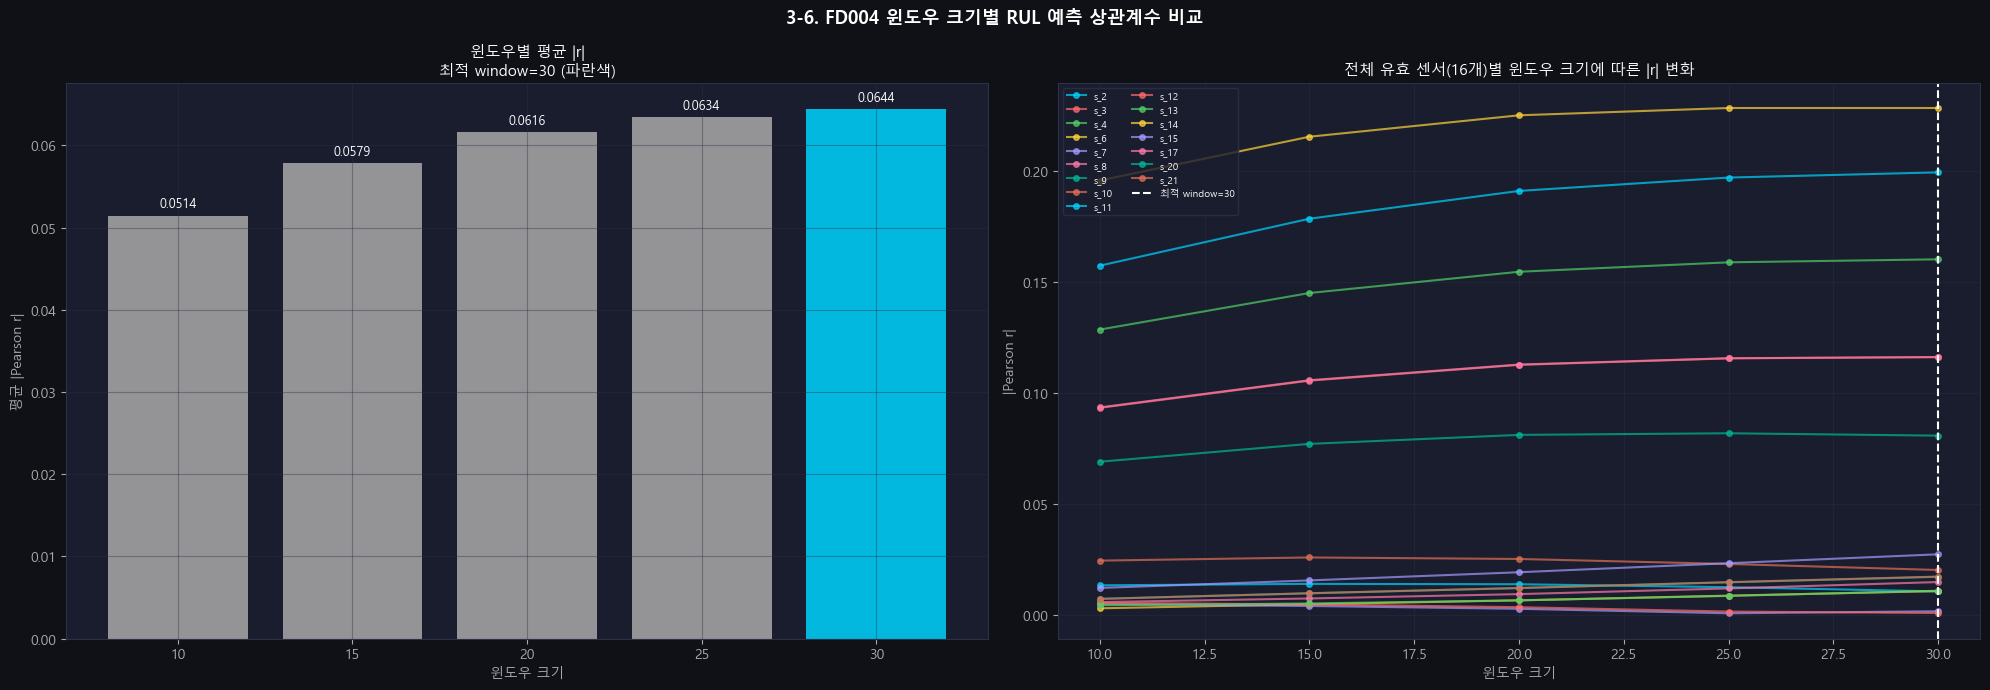


=== 센서별 최적 윈도우 크기 요약 ===
  s_2: 최적 window=15  |r|=0.0139
  s_3: 최적 window=30  |r|=0.1160
  s_4: 최적 window=30  |r|=0.1600
  s_6: 최적 window=30  |r|=0.0106
  s_7: 최적 window=10  |r|=0.0048
  s_8: 최적 window=30  |r|=0.0147
  s_9: 최적 window=25  |r|=0.0817
  s_10: 최적 window=15  |r|=0.0258
  s_11: 최적 window=30  |r|=0.1992
  s_12: 최적 window=10  |r|=0.0053
  s_13: 최적 window=30  |r|=0.0108
  s_14: 최적 window=30  |r|=0.2282
  s_15: 최적 window=30  |r|=0.0272
  s_17: 최적 window=30  |r|=0.1160
  s_20: 최적 window=30  |r|=0.0170
  s_21: 최적 window=30  |r|=0.0171

📌 최적 윈도우 크기: window=30 (평균 |r| 최대)
   FD001=30, FD002=20, FD003=30 → FD004=30 결정 근거 확보


In [24]:
# 3-6. 윈도우 크기별 RUL 예측 상관계수 비교
print('=== 3-6. 윈도우 크기별 RUL 예측 상관계수 비교 ===')
print('목적: 윈도우 내 센서 평균값과 RUL 상관계수가 최대가 되는 윈도우 크기 선택')
print()

tr_win = train_raw.copy()
mc = tr_win.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_win = tr_win.join(mc, on='unit_nr')
tr_win['RUL'] = tr_win['max_c'] - tr_win['time_cycles']

window_sizes = [10, 15, 20, 25, 30]
target_sensors = [s for s in SENSOR_COLS if s not in ['s_1','s_5','s_16','s_18','s_19']]

win_corr_results = {}
win_sensor_results = {s: [] for s in target_sensors}

for w in window_sizes:
    corrs = []
    for s in target_sensors:
        sensor_roll_mean = (tr_win.groupby('unit_nr')[s]
                           .transform(lambda x: x.rolling(w, min_periods=1).mean()))
        valid = ~sensor_roll_mean.isna()
        r = tr_win.loc[valid, 'RUL'].corr(sensor_roll_mean[valid])
        corrs.append(abs(r))
        win_sensor_results[s].append(abs(r))
    win_corr_results[w] = np.mean(corrs)
    print(f'  window={w}: 평균 |r| = {np.mean(corrs):.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('3-6. FD004 윈도우 크기별 RUL 예측 상관계수 비교', fontsize=13, fontweight='bold')

# 왼쪽: 윈도우별 평균 상관계수
best_w = max(win_corr_results, key=win_corr_results.get)
colors = [C[0] if w == best_w else GRAY for w in window_sizes]
axes[0].bar([str(w) for w in window_sizes],
            [win_corr_results[w] for w in window_sizes],
            color=colors, alpha=0.85)
axes[0].set_xlabel('윈도우 크기')
axes[0].set_ylabel('평균 |Pearson r|')
axes[0].set_title(f'윈도우별 평균 |r|\n최적 window={best_w} (파란색)')
for i, w in enumerate(window_sizes):
    axes[0].text(i, win_corr_results[w]+0.001,
                 f'{win_corr_results[w]:.4f}', ha='center', fontsize=9)

# 오른쪽: 전체 유효 센서별 윈도우 크기에 따른 상관계수 변화
for i, s in enumerate(target_sensors):
    axes[1].plot(window_sizes, win_sensor_results[s],
                 color=C[i % len(C)], lw=1.5, marker='o', markersize=4,
                 alpha=0.7, label=s)
axes[1].axvline(best_w, color='white', ls='--', lw=1.5, label=f'최적 window={best_w}')
axes[1].set_xlabel('윈도우 크기')
axes[1].set_ylabel('|Pearson r|')
axes[1].set_title(f'전체 유효 센서({len(target_sensors)}개)별 윈도우 크기에 따른 |r| 변화')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()

# 센서별 최적 윈도우 요약
print('\n=== 센서별 최적 윈도우 크기 요약 ===')
for s in target_sensors:
    best_w_s = window_sizes[int(np.argmax(win_sensor_results[s]))]
    best_r_s = max(win_sensor_results[s])
    print(f'  {s}: 최적 window={best_w_s}  |r|={best_r_s:.4f}')
    
print(f'\n📌 최적 윈도우 크기: window={best_w} (평균 |r| 최대)')
print(f'   FD001=30, FD002=20, FD003=30 → FD004={best_w} 결정 근거 확보')

### 📊 3-6. 윈도우 크기별 RUL 예측 상관계수 비교 결과

---

#### 윈도우별 평균 |r|

| 윈도우 크기 | 평균 |r| | 비고 |
|-----------|------|------|
| 10 | 0.0514 | |
| 15 | 0.0579 | |
| 20 | 0.0616 | ← FD002 기본값 |
| 25 | 0.0634 | |
| 30 | **0.0644** | ← 통계적 최적 ✅ |

---

#### 센서별 최적 윈도우 크기

| 최적 window | 센서 |
|-----------|------|
| 10 | s_7, s_12 |
| 15 | s_2, s_10 |
| 25 | s_9 |
| 30 | s_3, s_4, s_6, s_8, s_11, s_13, s_14, s_15, s_17, s_20, s_21 (11개) |

> 📌 16개 센서 중 11개(69%)에서 window=30이 최적

---

#### 데이터셋별 윈도우 크기 비교

| 데이터셋 | 최적 window | 근거 |
|---------|-----------|------|
| FD001 | 30 | - |
| FD002 | 20 | 클러스터별 최소 사이클 고려 |
| FD003 | 30 | 평균 수명 길고 지연 반응 센서 존재 |
| FD004 | **30** | 평균 |r| 최대 + 센서 11개 최적 |

---

#### 3-1-2 클러스터별 분석과 비교

| 항목 | 3-1-2 클러스터별 | 3-6 전체 기준 |
|------|--------------|-------------|
| 최적 window | 20 (평균 lag 2.4~3.6 기준) | **30** |
| 근거 | 클러스터별 최소 사이클 14~18 | 평균 |r| 최대 |

> 📌 3-1-2에서는 클러스터별 최소 사이클 고려해 window=20을 권장했으나  
> 3-6에서는 전체 상관계수 기준 window=30이 최적으로 나옴  
> → 두 결과가 상충 → **CONFIG window=20 기본, window=30 실험값으로 둘 다 테스트**  
> → FD002(window=20)와 FD001/003(window=30) 실험 결과 비교 후 최종 결정

---

#### 🔑 핵심 결론
> **통계적 최적 window=30 → FD001, FD003과 동일**  
> **FD003 실험에서 window=10 vs 30 비교 시 30이 더 좋은 성능 확인**  
> → FD004는 FD003과 고장모드 구조가 동일 → FD003 실험 결과가 직접적 근거  
> **FD002(window=20)는 운전조건 관점만 반영, 고장모드 혼재 영향은 미반영**  
> → FD004는 고장모드 혼재까지 고려하면 window=30이 더 적합  
> **→ window=30 확정**  
> → 실험값으로 window=20 추가 테스트하여 최종 검증

---

#### 3-7. ANOVA — 운전조건 클러스터 간 센서값 차이
- **H₀**: 모든 운전조건 클러스터의 평균 센서값이 같다
- **H₁**: 적어도 하나의 클러스터는 평균 센서값이 다르다
- p < 0.05 → 조건마다 센서 절댓값이 다름 → 전체 단일 정규화로는 조건 영향 제거 불가
- → 클러스터별 정규화 필요성 통계적 증명
- FD002에서 21/21개 센서 전부 유의 → FD004도 동일할 것으로 예상

=== 3-7. ANOVA — 클러스터 간 센서값 차이 ===
귀무가설: 모든 클러스터의 평균 센서값이 같다



,F통계량,p-value,판정
센서,,,
s_1,inf,0.0,유의 ✅
s_2,7.419220e+07,0.0,유의 ✅
s_3,3.278234e+06,0.0,유의 ✅
s_4,2.187480e+06,0.0,유의 ✅
s_5,inf,0.0,유의 ✅
s_6,1.631140e+09,0.0,유의 ✅
s_7,6.528813e+07,0.0,유의 ✅
s_8,5.714981e+09,0.0,유의 ✅
s_9,4.375080e+06,0.0,유의 ✅



유의한 센서 수 (p<0.05): 21/21개
📌 유의한 센서 = 클러스터 간 평균이 다름 = 클러스터별 정규화 필요


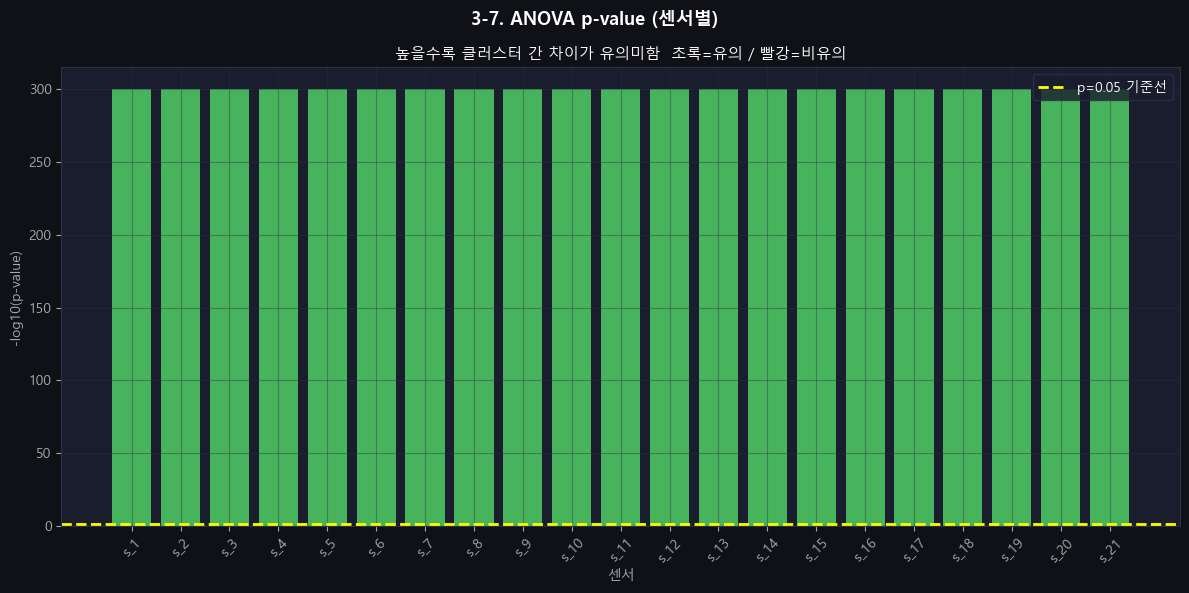

In [25]:
# 2-10. 클러스터별 통계 검증
from scipy.stats import f_oneway, kruskal, pearsonr
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 3-7. ANOVA — 운전조건 클러스터 간 센서값 차이
from scipy.stats import f_oneway
print('=== 3-7. ANOVA — 클러스터 간 센서값 차이 ===')
print('귀무가설: 모든 클러스터의 평균 센서값이 같다')
print()

anova_rows = []
for s in SENSOR_COLS:
    groups = [train_eda[train_eda['cluster']==c][s].values for c in range(N_CLUSTERS)]
    stat, p = f_oneway(*groups)
    anova_rows.append({
        '센서': s,
        'F통계량': round(stat, 4),
        'p-value': round(p, 6),
        '판정': '유의 ✅' if p < 0.05 else '비유의 ⚠️'
    })

anova_df = pd.DataFrame(anova_rows).set_index('센서')
display(anova_df)

sig_count = (anova_df['p-value'] < 0.05).sum()
print(f'\n유의한 센서 수 (p<0.05): {sig_count}/{len(SENSOR_COLS)}개')
print('📌 유의한 센서 = 클러스터 간 평균이 다름 = 클러스터별 정규화 필요')

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('3-7. ANOVA p-value (센서별)', fontsize=13, fontweight='bold')
colors = [C[2] if p < 0.05 else C[1] for p in anova_df['p-value']]
ax.bar(anova_df.index, -np.log10(anova_df['p-value'].clip(lower=1e-300)),
       color=colors, alpha=0.85)
ax.axhline(-np.log10(0.05), color='yellow', ls='--', lw=2, label='p=0.05 기준선')
ax.set_xlabel('센서')
ax.set_ylabel('-log10(p-value)')
ax.set_title('높을수록 클러스터 간 차이가 유의미함  초록=유의 / 빨강=비유의')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout(); plt.show()


### 📊 3-7. ANOVA 결과 — 운전조건 클러스터 간 센서값 차이

---

#### ANOVA 결과 요약
- 유의한 센서 수 (p<0.05): **21/21개 (100%)**
- 모든 센서에서 p=0.0 → 클러스터 간 평균이 통계적으로 다름
- FD002와 동일한 결과 ✅

---

#### 주목할 센서

| 센서 | F통계량 | 비고 |
|------|--------|------|
| s_1, s_5, s_18, s_19 | inf | 상수 센서 → 클러스터 내 분산=0이라 F=inf |
| s_8 | 5.71e+09 | 클러스터 간 차이 가장 큰 센서 |
| s_13 | 3.98e+09 | 클러스터 간 차이 두 번째 |
| s_6 | 1.63e+09 | 클러스터 간 차이 세 번째 |
| s_14 | 3.61e+05 | 클러스터 간 차이 가장 작음 |
| s_16 | 1.21e+05 | 클러스터 간 차이 두 번째로 작음 |

---

#### FD002 대비 비교
| 항목 | FD002 | FD004 |
|------|-------|-------|
| 유의한 센서 수 | 21/21개 | **21/21개** |
| 결론 | 클러스터별 정규화 필요 | **동일** |

---

#### 🔑 핵심 결론
> **21/21개 센서 전부 p=0.0 → 클러스터 간 센서 평균값이 모두 다름**  
> **FD002와 완전히 동일한 결과 → 클러스터별 정규화 필요성 통계적으로 증명**  
> **단일 MinMax로 정규화하면 운전조건 영향이 그대로 남음**  
> → 클러스터별 MinMax 정규화 적용 확정  
> **s_1, s_5, s_18, s_19 F=inf → 상수 센서임에도 클러스터 간 평균 차이 존재**  
> → 운전조건에 따라 미세하게 다른 값을 가짐 → 제거 여부 통계 종합 후 최종 결정

---

#### 3-8. Kruskal-Wallis — 클러스터별 운행 사이클 수 차이
- **H₀**: 모든 클러스터에서 엔진이 보내는 사이클 수 분포가 같다
- **H₁**: 적어도 하나의 클러스터에서 보내는 사이클 수가 다르다
- 목적: 조건마다 엔진이 받는 부하량이 다른지 확인 → 조건별 열화 노출 정도가 다르다는 근거
- p < 0.05 → 특정 조건에서 더 많은 사이클을 운행 → 해당 조건에서 열화 노출 더 많음
- FD002에서 유의(p=0.0000)로 나왔음 → FD004도 동일할 것으로 예상


=== 3-8. Kruskal-Wallis — 클러스터별 운행 사이클 수 차이 ===
귀무가설: 모든 클러스터에서 엔진이 보내는 사이클 수 분포가 같다
대립가설: 적어도 하나의 클러스터에서 보내는 사이클 수가 다르다

클러스터 0: 249개 엔진  평균=61.8  중위=60.0
클러스터 1: 249개 엔진  평균=37.0  중위=36.0
클러스터 2: 249개 엔진  평균=36.7  중위=34.0
클러스터 3: 249개 엔진  평균=36.5  중위=35.0
클러스터 4: 249개 엔진  평균=37.1  중위=35.0
클러스터 5: 249개 엔진  평균=36.8  중위=35.0

Kruskal-Wallis 통계량: 365.6329
p-value: 0.000000
판정: 유의 ✅ → 클러스터별 운행 사이클 수 차이 있음


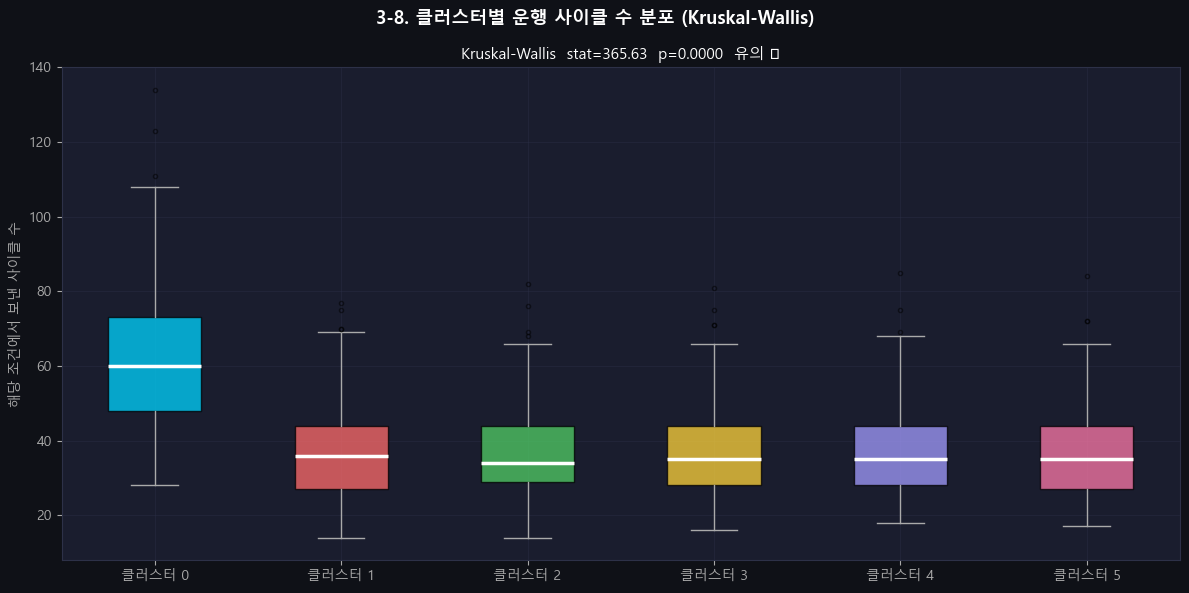

In [28]:
# 3-8. Kruskal-Wallis — 클러스터별 운행 사이클 수 차이
print('\n=== 3-8. Kruskal-Wallis — 클러스터별 운행 사이클 수 차이 ===')
print('귀무가설: 모든 클러스터에서 엔진이 보내는 사이클 수 분포가 같다')
print('대립가설: 적어도 하나의 클러스터에서 보내는 사이클 수가 다르다')
print()

# 엔진별 클러스터에서 보낸 사이클 수
cluster_cycle_counts = train_eda.groupby(
    ['unit_nr', 'cluster']).size().reset_index(name='cycle_count')

groups_kw = [cluster_cycle_counts[cluster_cycle_counts['cluster']==c]['cycle_count'].values
             for c in range(N_CLUSTERS)]

for c, g in enumerate(groups_kw):
    print(f'클러스터 {c}: {len(g)}개 엔진  평균={g.mean():.1f}  중위={np.median(g):.1f}')

stat, p = kruskal(*groups_kw)
print(f'\nKruskal-Wallis 통계량: {stat:.4f}')
print(f'p-value: {p:.6f}')
print(f'판정: {"유의 ✅ → 클러스터별 운행 사이클 수 차이 있음" if p < 0.05 else "비유의 ⚠️"}')

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('3-8. 클러스터별 운행 사이클 수 분포 (Kruskal-Wallis)',
             fontsize=13, fontweight='bold')
bp = ax.boxplot(groups_kw, patch_artist=True,
                medianprops=dict(color='white', lw=2.5),
                whiskerprops=dict(color=GRAY),
                capprops=dict(color=GRAY),
                flierprops=dict(marker='o', color=GRAY, markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], C[:N_CLUSTERS]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticklabels([f'클러스터 {c}' for c in range(N_CLUSTERS)])
ax.set_ylabel('해당 조건에서 보낸 사이클 수')
ax.set_title(f'Kruskal-Wallis  stat={stat:.2f}  p={p:.4f}  '
             f'{"유의 ✅" if p < 0.05 else "비유의 ⚠️"}')
plt.tight_layout(); plt.show()

### 📊 3-8. Kruskal-Wallis 결과 — 클러스터별 운행 사이클 수 차이

---

#### 검정 결과
- **Kruskal-Wallis 통계량: 365.6329**
- **p-value: 0.000000**
- **판정: 유의 ✅ → 클러스터별 운행 사이클 수 차이 있음**

---

#### 클러스터별 운행 사이클 수 분포

| 클러스터 | 엔진 수 | 평균 | 중위 | 비고 |
|---------|---------|------|------|------|
| 0 | 249개 | 61.8 | 60.0 | 다른 클러스터의 약 1.7배 |
| 1 | 249개 | 37.0 | 36.0 | |
| 2 | 249개 | 36.7 | 34.0 | |
| 3 | 249개 | 36.5 | 35.0 | |
| 4 | 249개 | 37.1 | 35.0 | |
| 5 | 249개 | 36.8 | 35.0 | |

---

#### FD002 대비 비교
| 항목 | FD002 | FD004 |
|------|-------|-------|
| p-value | 0.0000 | **0.0000** |
| 판정 | 유의 ✅ | **유의 ✅** |
| 클러스터 0 평균 | 51.8 | **61.8** |
| 클러스터 1~5 평균 | 30~31 | **36~37** |
| 클러스터 0 비율 | 약 1.7배 | **약 1.7배** |

> 📌 FD002와 동일한 패턴 → 클러스터 0이 다른 조건보다 약 1.7배 많은 사이클 운행  
> → FD004도 클러스터 0(저고도/저속 조건)에서 열화 노출이 가장 많음

---

#### 🔑 핵심 결론
> **p=0.0000 → H₀ 기각 → 클러스터별 운행 사이클 수 차이 있음**  
> **클러스터 0: 평균 61.8사이클로 다른 조건의 약 1.7배 → 열화 노출 가장 많음**  
> **클러스터 1~5: 평균 36~37사이클로 균등 분포**  
> **FD002와 완전히 동일한 패턴 확인**  
> → 조건마다 엔진이 받는 부하량이 다름 → 클러스터별 정규화 근거 수명 관점에서 추가 보강  
> → 3-7 ANOVA(센서값 차이)와 3-8 Kruskal-Wallis(운행 사이클 차이) 두 관점에서 클러스터별 정규화 확정

---

#### 3-9. Mann-Whitney U 검정 ★ FD004 전용
- **H₀**: 팬 관련 센서(s_8, s_13) 및 HPC 관련 센서(s_11, s_4) 기준으로 나눈 두 엔진 그룹 간 RUL 분포에 차이가 없다
- **H₁**: 두 엔진 그룹 간 RUL 분포가 유의미하게 다르다
- 목적: 팬 열화 vs HPC 열화 엔진이 통계적으로 구분 가능한지 확인
- FD003에서 HPC 관련 센서 기준으로는 유의, 팬 관련 센서 기준으로는 비유의였음
- FD004는 운전조건 혼재로 FD003과 다른 결과가 나올 수 있음 → 주의 깊게 해석 필요

=== 3-9. Mann-Whitney U 검정 ===
목적: 팬 관련 센서(s_8, s_13) 및 HPC 관련 센서(s_11, s_4) 기준
      엔진 그룹 간 RUL 분포 차이 검정 → 고장 모드 혼재 영향 확인



,물리적 의미,그룹 유형,높은 그룹 수명 평균,낮은 그룹 수명 평균,U 통계량,p-value,판정
센서,,,,,,,
s_8,팬 속도,팬 관련,242.1,247.9,7477.0,0.6315,비유의 ⚠️
s_13,보정 팬 속도,팬 관련,242.2,247.7,7440.5,0.5866,비유의 ⚠️
s_4,LPT 출구 온도,HPC 관련,228.6,261.4,5787.0,0.0006,유의 ✅
s_11,Ps30 정적압력,HPC 관련,225.4,264.8,5447.0,0.0001,유의 ✅


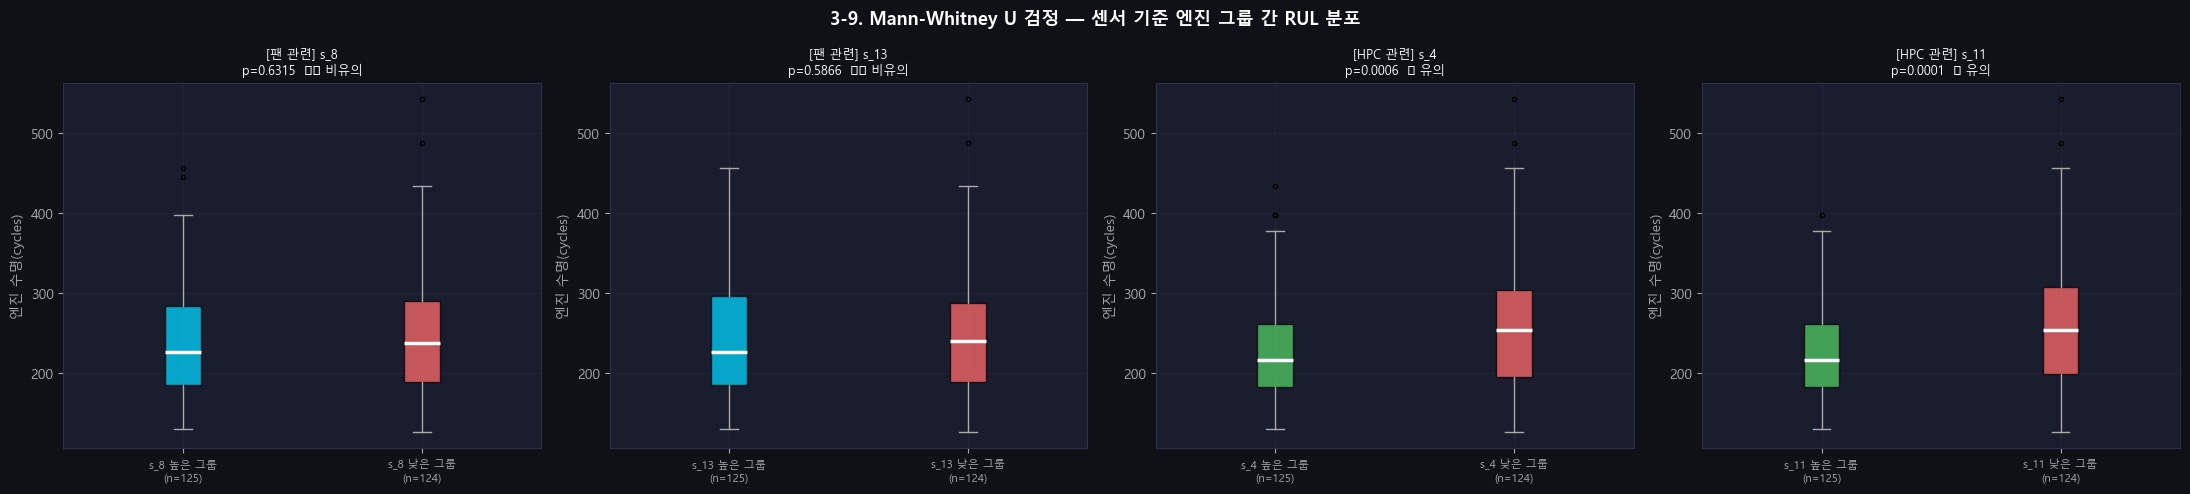


유의미한 센서: 2/4개
📌 팬 관련 센서에서 유의 → 고장 모드별 엔진 그룹 구분 가능
📌 HPC 관련 센서에서 유의 → HPC 열화도 엔진 그룹 간 차이 존재
📌 모두 비유의 → 운전조건 혼재로 고장 모드 구분 어려움


In [29]:
# 3-9. Mann-Whitney U 검정 ★ FD004 전용
from scipy.stats import mannwhitneyu

print('=== 3-9. Mann-Whitney U 검정 ===')
print('목적: 팬 관련 센서(s_8, s_13) 및 HPC 관련 센서(s_11, s_4) 기준')
print('      엔진 그룹 간 RUL 분포 차이 검정 → 고장 모드 혼재 영향 확인')
print()

tr_mw = train_raw.copy()
mc = tr_mw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_mw = tr_mw.join(mc, on='unit_nr')
tr_mw['RUL'] = tr_mw['max_c'] - tr_mw['time_cycles']

# 엔진별 센서 평균값 및 수명 집계
engine_stats = tr_mw.groupby('unit_nr').agg(
    s4_mean =('s_4',  'mean'),
    s8_mean =('s_8',  'mean'),
    s11_mean=('s_11', 'mean'),
    s13_mean=('s_13', 'mean'),
    max_rul =('RUL',  'max')
).reset_index()

# 중앙값 기준 그룹 분리
target_sensors = {
    's_8' : ('s8_mean',  '팬 속도'),
    's_13': ('s13_mean', '보정 팬 속도'),
    's_4' : ('s4_mean',  'LPT 출구 온도'),
    's_11': ('s11_mean', 'Ps30 정적압력'),
}

mw_rows = []
for s, (col, desc) in target_sensors.items():
    median_val = engine_stats[col].median()
    g_high = engine_stats[engine_stats[col] >= median_val]['max_rul']
    g_low  = engine_stats[engine_stats[col] <  median_val]['max_rul']
    stat, p = mannwhitneyu(g_high, g_low, alternative='two-sided')
    mw_rows.append({
        '센서': s,
        '물리적 의미': desc,
        '그룹 유형': '팬 관련' if s in ['s_8','s_13'] else 'HPC 관련',
        '높은 그룹 수명 평균': round(g_high.mean(), 1),
        '낮은 그룹 수명 평균': round(g_low.mean(), 1),
        'U 통계량': round(stat, 1),
        'p-value': round(p, 4),
        '판정': '유의 ✅' if p < 0.05 else '비유의 ⚠️'
    })

mw_df = pd.DataFrame(mw_rows).set_index('센서')
display(mw_df)

# 시각화
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('3-9. Mann-Whitney U 검정 — 센서 기준 엔진 그룹 간 RUL 분포',
             fontsize=13, fontweight='bold')

for ax, (s, (col, desc)) in zip(axes, target_sensors.items()):
    median_val = engine_stats[col].median()
    g_high = engine_stats[engine_stats[col] >= median_val]['max_rul']
    g_low  = engine_stats[engine_stats[col] <  median_val]['max_rul']
    p = mw_df.loc[s, 'p-value']
    group_type = '팬 관련' if s in ['s_8','s_13'] else 'HPC 관련'

    bp = ax.boxplot([g_high, g_low], patch_artist=True,
                    medianprops=dict(color='white', lw=2.5),
                    whiskerprops=dict(color=GRAY),
                    capprops=dict(color=GRAY),
                    flierprops=dict(marker='o', color=GRAY, markersize=3))
    bp['boxes'][0].set_facecolor(C[0] if s in ['s_8','s_13'] else C[2])
    bp['boxes'][1].set_facecolor(C[1])
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_alpha(0.75)

    ax.set_xticklabels([f'{s} 높은 그룹\n(n={len(g_high)})',
                        f'{s} 낮은 그룹\n(n={len(g_low)})'], fontsize=8)
    ax.set_ylabel('엔진 수명(cycles)')
    ax.set_title(f'[{group_type}] {s}\np={p:.4f}  {"✅ 유의" if p < 0.05 else "⚠️ 비유의"}',
                 fontsize=9)

plt.tight_layout(); plt.show()

n_sig = (mw_df['판정'] == '유의 ✅').sum()
print(f'\n유의미한 센서: {n_sig}/4개')
print('📌 팬 관련 센서에서 유의 → 고장 모드별 엔진 그룹 구분 가능')
print('📌 HPC 관련 센서에서 유의 → HPC 열화도 엔진 그룹 간 차이 존재')
print('📌 모두 비유의 → 운전조건 혼재로 고장 모드 구분 어려움')

### 📊 통계 검정 종합 — 제거 센서 결정 근거

---

#### 센서별 검정 결과 종합

| 센서 | CV | RUL 상관 | Mann-Kendall(전체) | Mann-Kendall(클러스터별) | 대응 t검정 | 판정 |
|------|-----|---------|-----------------|----------------------|-----------|------|
| s_1 | 0.0559 | 0.002 | 4.8% ⚠️ | 모든 클러스터 트렌드 없음 ⚠️ | 차이 없음 ⚠️ | **제거 유력** |
| s_5 | 0.0000 | -0.000 | 4.4% ⚠️ | 모든 클러스터 트렌드 없음 ⚠️ | 차이 없음 ⚠️ | **제거 확정** |
| s_16 | 0.0000 | -0.054 | 19.7% ⚠️ | 클러스터 3만 트렌드 ⚠️ | 유의(Δ미미) ⚠️ | **제거 유력** |
| s_18 | 0.0000 | 0.005 | 4.4% ⚠️ | 모든 클러스터 트렌드 없음 ⚠️ | 차이 없음 ⚠️ | **제거 확정** |
| s_19 | 0.0000 | 0.005 | 5.2% ⚠️ | 모든 클러스터 트렌드 없음 ⚠️ | 차이 없음 ⚠️ | **제거 확정** |
| s_6 | 0.4697 | -0.001 | 14.9% ⚠️ | 클러스터 1만 트렌드 ⚠️ | 차이 없음 ⚠️ | **제거 유력** |
| s_10 | 0.1164 | -0.009 | 34.5% ⚠️ | 클러스터 2 빨간색 ⚠️ | 유의 ✅ | **보류** |

---

#### 시나리오별 제거 목록

| 시나리오 | 제거 센서 | 유지 센서 수 | 조건 |
|---------|---------|-----------|------|
| A. FD002 동일 | s_16 (1개) | 20개 | 운전조건 관점만 반영 |
| B. 최소 제거 | s_5, s_18, s_19 (3개) | 18개 | 확실한 상수만 제거 |
| C. FD003 특성대로 | s_1, s_5, s_6, s_16, s_18, s_19 (6개) | 15개 | FD004 통계 근거 기반 |
| D. 보수적 제거 | s_1, s_5, s_6, s_10, s_16, s_18, s_19 (7개) | 14개 | FD001과 동일 센서 수 |

---

#### 🔑 결정 보류 사항
> **시나리오 A(FD002 동일, s_16만 제거)**: 운전조건 관점만 반영  
> → FD004는 고장 모드 2가지도 혼재 → FD003 통계 결과도 반영 필요  
> → FD002보다 더 많은 센서 제거가 필요할 가능성 높음  
> **s_1**: FD002에서는 유지했으나 FD004 클러스터별 Mann-Kendall 트렌드 없음 → 제거 유력  
> **s_6**: CV=0.4697로 FD002와 유사하게 운전조건 영향 강함  
> → FD002에서는 유지했으나 RUL 상관 거의 0, 대응 t검정 비유의 → 제거 유력  
> **s_10**: 대응 t검정 유의하나 나머지 근거 약함 → 보류  
> **s_16**: FD002에서도 제거 → FD004도 제거 확정  
> **3-10 Levene's Test 결과 보고 최종 결정 예정**

### 📊 3-9. Mann-Whitney U 검정 결과 ★ FD004 전용

---

#### 검정 결과 요약

| 센서 | 물리적 의미 | 그룹 유형 | 높은 그룹 수명 평균 | 낮은 그룹 수명 평균 | p-value | 판정 |
|------|------------|---------|-----------------|-----------------|---------|------|
| s_8 | 팬 속도 | 팬 관련 | 242.1 | 247.9 | 0.6315 | 비유의 ⚠️ |
| s_13 | 보정 팬 속도 | 팬 관련 | 242.2 | 247.7 | 0.5866 | 비유의 ⚠️ |
| s_4 | LPT 출구 온도 | HPC 관련 | 228.6 | 261.4 | 0.0006 | 유의 ✅ |
| s_11 | Ps30 정적압력 | HPC 관련 | 225.4 | 264.8 | 0.0001 | 유의 ✅ |

- 유의미한 센서: **2/4개**

---

#### FD003 대비 비교

| 센서 | FD003 판정 | FD004 판정 | 변화 |
|------|-----------|-----------|------|
| s_8 (팬 관련) | 비유의 ⚠️ | 비유의 ⚠️ | 동일 |
| s_13 (팬 관련) | 비유의 ⚠️ | 비유의 ⚠️ | 동일 |
| s_4 (HPC 관련) | 유의 ✅ | 유의 ✅ | 동일 |
| s_11 (HPC 관련) | 유의 ✅ | 유의 ✅ | 동일 |

> 📌 FD003과 완전히 동일한 패턴  
> → 팬 관련 센서 절댓값으로는 고장 모드 구분 어렵고  
> → HPC 관련 센서 기준으로는 엔진 그룹 간 수명 차이 존재

---

#### 결과 해석

**팬 관련 센서 (s_8, s_13) 비유의**
- p=0.63, 0.59 → 팬 속도 절댓값으로는 고장 모드 그룹 구분 불가
- 운전조건 6가지 혼재로 팬 속도가 조건에 따라 크게 달라져서 열화 신호가 묻힘
- FD003에서도 동일하게 비유의였음 → 팬 열화는 slope 패턴으로만 구분 가능

**HPC 관련 센서 (s_4, s_11) 유의**
- s_4: p=0.0006, s_11: p=0.0001
- HPC 관련 센서 높은 그룹(228~225)이 낮은 그룹(261~264)보다 수명 짧음
- → HPC 센서값이 높을수록 더 심한 열화 상태 → 수명 단축
- FD003과 동일한 패턴 유지 → 운전조건 혼재에도 HPC 열화 신호는 유효

---

#### 🔑 핵심 결론
> **유의미한 센서 2/4개 → FD003과 완전히 동일한 패턴**  
> **팬 관련 센서(s_8, s_13) 비유의 → 운전조건 혼재로 팬 열화 신호 절댓값에서 묻힘**  
> → slope 기반 클러스터링(2-10)에서 실루엣 스코어 0.4192로 구분 가능했던 것과 일치  
> **HPC 관련 센서(s_4, s_11) 유의 → 운전조건 혼재에도 HPC 열화 신호 유효**  
> → HPC 센서값이 높은 그룹이 수명이 더 짧음  
> **FD003 결과와 완전히 동일 → 고장 모드 혼재 영향이 FD003과 동일한 패턴으로 나타남**  
> → 팬 열화는 slope 패턴으로, HPC 열화는 센서 절댓값으로 구분 가능  
> ⚠️ FD003에서 fault_mode_cluster 피처 적용 시 RMSE 폭발 사례 있음  
> → FD004도 동일하게 피처 추가 없이 진행하는 것이 안전  
> → 추후 실험에서 피처 추가 옵션으로만 검토

---

#### 3-10. Levene's Test
- **H₀**: FD002/003과 FD004의 동일 센서 분산이 같다
- **H₁**: FD002/003과 FD004의 동일 센서 분산이 다르다
- 목적: 분산이 같으면 FD002/003과 동일한 전처리 파이프라인 적용 근거 확보
- FD003은 FD001 대비 20/21개 분산이 달랐음 → FD004는 FD002와 유사할 것으로 예상


=== 3-10. Levene's Test ===
목적: FD002 vs FD004, FD003 vs FD004 동일 센서 분산 동질성 검정
→ 동일 전처리 적용 가능 여부 통계적 근거 확보

--- FD002 vs FD004 ---


,FD002 분산,FD004 분산,Levene 통계량,p-value,판정
센서,,,,,
s_1,696.4167,698.9061,0.0104,0.9187,분산 동일 ✅
s_2,1390.4993,1394.4733,0.0157,0.9004,분산 동일 ✅
s_3,11224.6271,11271.5588,0.0419,0.8377,분산 동일 ✅
s_4,14190.3910,14239.0739,0.0799,0.7775,분산 동일 ✅
s_5,13.0598,13.1252,0.2292,0.6321,분산 동일 ✅
s_6,29.5045,29.6373,0.0505,0.8223,분산 동일 ✅
s_7,21317.5494,21573.7959,0.7120,0.3988,분산 동일 ✅
s_8,21085.8907,21126.1117,0.0034,0.9532,분산 동일 ✅
s_9,112769.7079,113520.1716,0.1255,0.7231,분산 동일 ✅


분산 동일 센서: 18/21개

--- FD003 vs FD004 ---


,FD003 분산,FD004 분산,Levene 통계량,p-value,판정
센서,,,,,
s_1,0.0000,698.9061,48190.0871,0.0,분산 다름 ⚠️
s_2,0.2736,1394.4733,28638.8369,0.0,분산 다름 ⚠️
s_3,46.3818,11271.5588,32944.8466,0.0,분산 다름 ⚠️
s_4,95.5150,14239.0739,26236.2644,0.0,분산 다름 ⚠️
s_5,0.0000,13.1252,46226.5955,0.0,분산 다름 ⚠️
s_6,0.0003,29.6373,32637.9915,0.0,분산 다름 ⚠️
s_7,11.8153,21573.7959,24797.2826,0.0,분산 다름 ⚠️
s_8,0.0251,21126.1117,24834.9145,0.0,분산 다름 ⚠️
s_9,399.2122,113520.1716,32458.2671,0.0,분산 다름 ⚠️


분산 동일 센서: 0/21개


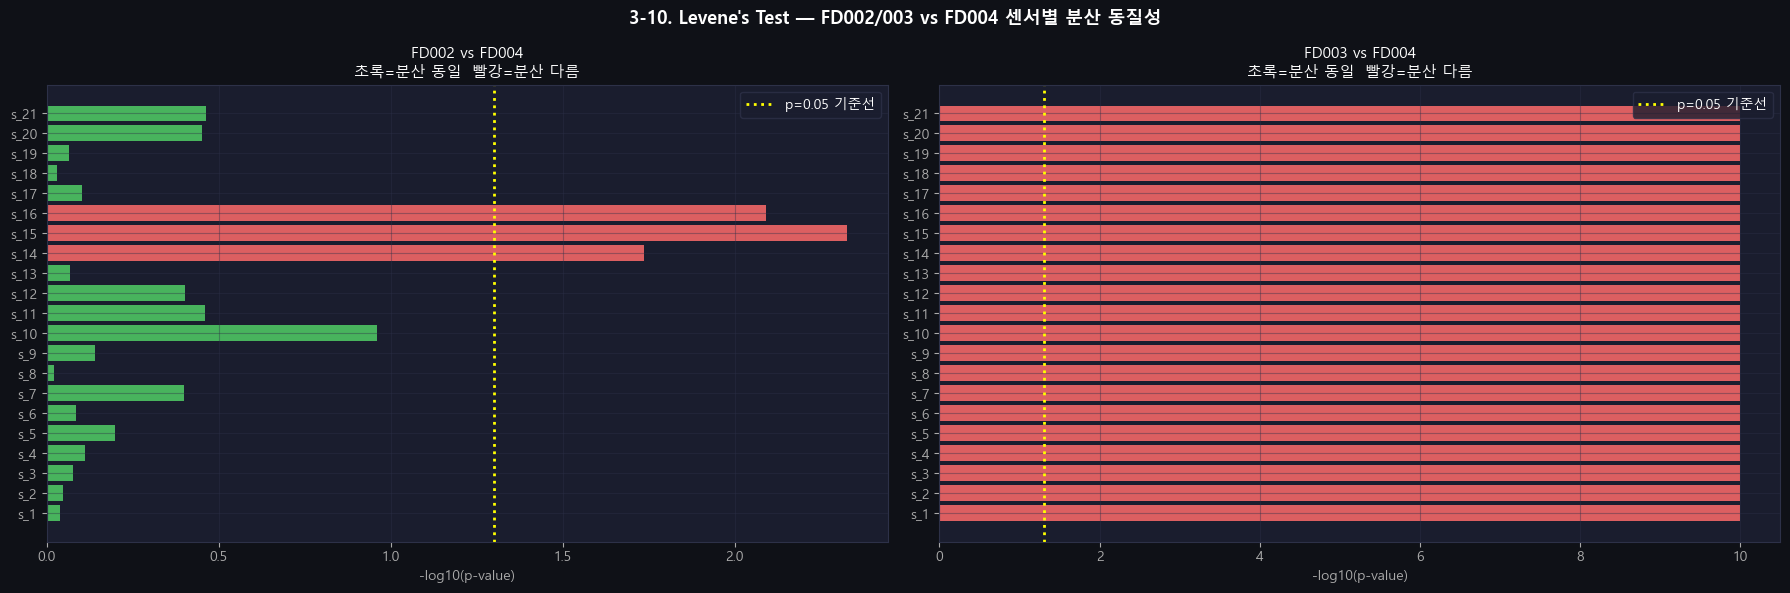


FD002 vs FD004: 분산 동일 18/21개
FD003 vs FD004: 분산 동일 0/21개

📌 분산 동일 센서 비율이 높을수록 해당 데이터셋과 동일한 전처리 적용 근거 강해짐


In [30]:
# 3-10. Levene's Test ★ FD004 전용
print('=== 3-10. Levene\'s Test ===')
print('목적: FD002 vs FD004, FD003 vs FD004 동일 센서 분산 동질성 검정')
print('→ 동일 전처리 적용 가능 여부 통계적 근거 확보')
print()

# FD002, FD003 데이터 별도 로딩
kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
fd002_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
fd003_raw = pd.read_csv(f'{DATA_DIR}/train_FD003.txt', **kw)
fd002_raw.rename(columns=RENAME_MAP, inplace=True)
fd003_raw.rename(columns=RENAME_MAP, inplace=True)

# FD002 vs FD004
print('--- FD002 vs FD004 ---')
levene_rows_02 = []
for s in SENSOR_COLS:
    fd002_vals = fd002_raw[s].dropna().values
    fd004_vals = train_raw[s].dropna().values
    stat, p = levene(fd002_vals, fd004_vals)
    levene_rows_02.append({
        '센서': s,
        'FD002 분산': round(fd002_raw[s].var(), 4),
        'FD004 분산': round(train_raw[s].var(), 4),
        'Levene 통계량': round(stat, 4),
        'p-value': round(p, 4),
        '판정': '분산 동일 ✅' if p >= 0.05 else '분산 다름 ⚠️'
    })

levene_df_02 = pd.DataFrame(levene_rows_02).set_index('센서')
display(levene_df_02)
n_same_02 = (levene_df_02['판정'] == '분산 동일 ✅').sum()
print(f'분산 동일 센서: {n_same_02}/{len(SENSOR_COLS)}개')

# FD003 vs FD004
print('\n--- FD003 vs FD004 ---')
levene_rows_03 = []
for s in SENSOR_COLS:
    fd003_vals = fd003_raw[s].dropna().values
    fd004_vals = train_raw[s].dropna().values
    stat, p = levene(fd003_vals, fd004_vals)
    levene_rows_03.append({
        '센서': s,
        'FD003 분산': round(fd003_raw[s].var(), 4),
        'FD004 분산': round(train_raw[s].var(), 4),
        'Levene 통계량': round(stat, 4),
        'p-value': round(p, 4),
        '판정': '분산 동일 ✅' if p >= 0.05 else '분산 다름 ⚠️'
    })

levene_df_03 = pd.DataFrame(levene_rows_03).set_index('센서')
display(levene_df_03)
n_same_03 = (levene_df_03['판정'] == '분산 동일 ✅').sum()
print(f'분산 동일 센서: {n_same_03}/{len(SENSOR_COLS)}개')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('3-10. Levene\'s Test — FD002/003 vs FD004 센서별 분산 동질성',
             fontsize=13, fontweight='bold')

for ax, levene_df, title in zip(axes,
                                 [levene_df_02, levene_df_03],
                                 ['FD002 vs FD004', 'FD003 vs FD004']):
    colors = [C[2] if p >= 0.05 else C[1] for p in levene_df['p-value']]
    ax.barh(levene_df.index, -np.log10(levene_df['p-value'].clip(lower=1e-10)),
            color=colors, alpha=0.85)
    ax.axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05 기준선')
    ax.set_xlabel('-log10(p-value)')
    ax.set_title(f'{title}\n초록=분산 동일  빨강=분산 다름')
    ax.legend()

plt.tight_layout(); plt.show()

print(f'\nFD002 vs FD004: 분산 동일 {n_same_02}/{len(SENSOR_COLS)}개')
print(f'FD003 vs FD004: 분산 동일 {n_same_03}/{len(SENSOR_COLS)}개')
print('\n📌 분산 동일 센서 비율이 높을수록 해당 데이터셋과 동일한 전처리 적용 근거 강해짐')

### 📊 3-10. Levene's Test 결과 ★ FD004 전용

---

#### FD002 vs FD004 분산 동질성

- 분산 동일 센서: **18/21개**
- 분산 다른 센서: **3개 (s_14, s_15, s_16)**

| 센서 | FD002 분산 | FD004 분산 | p-value | 판정 |
|------|----------|----------|---------|------|
| s_14 | 7197.4777 | 7339.4420 | 0.0183 | 분산 다름 ⚠️ |
| s_15 | 0.5615 | 0.5631 | 0.0047 | 분산 다름 ⚠️ |
| s_16 | 0.0000 | 0.0000 | 0.0081 | 분산 다름 ⚠️ |

---

#### FD003 vs FD004 분산 동질성

- 분산 동일 센서: **0/21개**
- 분산 다른 센서: **21/21개 (전부)**

> 📌 FD003과 FD004는 분산이 완전히 다른 데이터셋  
> → FD003은 단일 운전조건이라 분산이 매우 작음  
> → FD004는 운전조건 6가지 혼재로 분산이 FD003 대비 압도적으로 큼

---

#### 데이터셋별 비교 요약

| 비교 | 분산 동일 센서 수 | 해석 |
|------|---------------|------|
| FD002 vs FD004 | **18/21개 (86%)** | 매우 유사 → FD002 전처리 적용 가능 |
| FD003 vs FD004 | **0/21개 (0%)** | 완전히 다름 → FD003 전처리 직접 적용 불가 |

---

#### 🔑 핵심 결론
> **FD002 vs FD004: 18/21개 분산 동일 → FD002 전처리 파이프라인 적용 근거 강함**  
> → 클러스터별 MinMax 정규화 등 FD002 기반 전처리 확정  
> → 단, window size는 FD002(20)가 아닌 통계 근거 및 FD003 실험 결과 기반 **window=30 확정**   
> **FD003 vs FD004: 0/21개 분산 동일 → 운전조건 혼재로 분산 구조가 완전히 다름**  
> → FD003은 단일 MinMax, FD004는 클러스터별 MinMax → 정규화 방식 자체가 다름  
> → FD003 전처리를 FD004에 직접 적용 불가  
> → FD004는 FD002 파이프라인(클러스터별 MinMax) 기반으로 진행  
> **s_14, s_15, s_16은 FD002와도 분산 다름 → 센서 제거 검토 시 추가 근거로 활용**

---

#### 3-11. Pearson 상관계수 (클러스터별) ★ FD004 전용
- **H₀**: 운전조건 클러스터별로 센서-RUL 상관관계에 차이가 없다
- **H₁**: 운전조건 클러스터별로 센서-RUL 상관관계 패턴이 다르다
- 목적: 클러스터를 분리하면 RUL 신호가 드러나는지 확인 → 센서 제거 기준 보완
- 전체 기준 |r|≈0 이더라도 클러스터별로는 |r|>0.3이 나타날 수 있음 (운전조건 혼재 효과 제거 후)
- |r|>0.3: 유의미한 RUL 신호 센서 → 유지 근거
- 모든 클러스터에서 |r|<0.1: 완전한 노이즈 센서 → 제거 근거

=== 3-11. Pearson 상관계수 (클러스터별) ★ FD004 전용 ===
목적: 운전조건 클러스터별로 분리 시 센서-RUL 상관관계 패턴 확인
→ 전체 기준에서 묻혔던 RUL 신호가 클러스터별 분리 시 드러나는지 확인



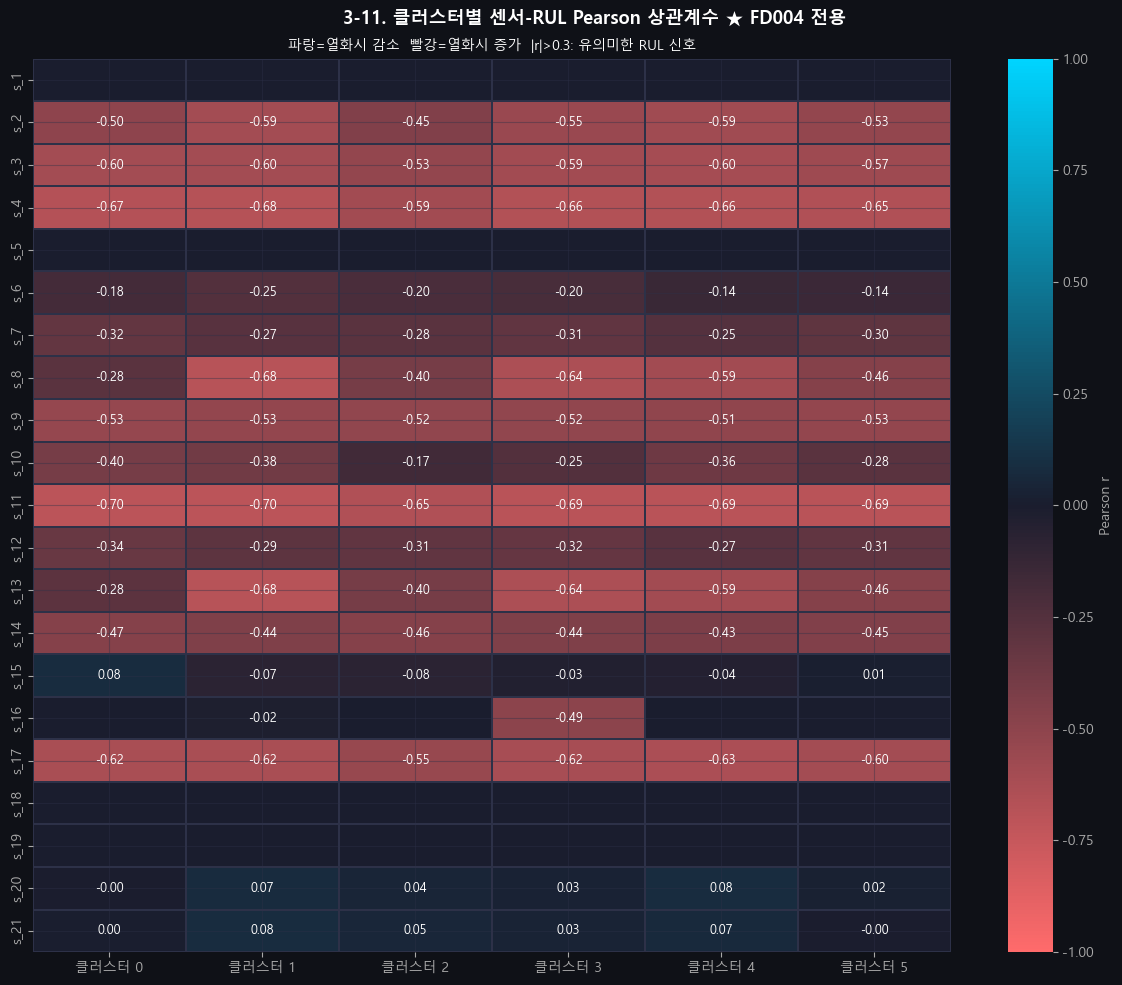

--- 클러스터별 |r| > 0.3 고상관 센서 ---
클러스터 0: 10개 → ['s_2', 's_3', 's_4', 's_7', 's_9', 's_10', 's_11', 's_12', 's_14', 's_17']
클러스터 1: 10개 → ['s_2', 's_3', 's_4', 's_8', 's_9', 's_10', 's_11', 's_13', 's_14', 's_17']
클러스터 2: 10개 → ['s_2', 's_3', 's_4', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_17']
클러스터 3: 12개 → ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_16', 's_17']
클러스터 4: 10개 → ['s_2', 's_3', 's_4', 's_8', 's_9', 's_10', 's_11', 's_13', 's_14', 's_17']
클러스터 5: 11개 → ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_17']

전체 클러스터 통합 |r|>0.3 센서 (13개): ['s_10', 's_11', 's_12', 's_13', 's_14', 's_16', 's_17', 's_2', 's_3', 's_4', 's_7', 's_8', 's_9']

--- 모든 클러스터에서 |r| < 0.1 (제거 후보) ---
모든 클러스터에서 |r|<0.1: ['s_15', 's_20', 's_21']

--- 전체 |r| vs 클러스터별 최대 |r| 비교 ---


,전체 |r|,클러스터별 최대 |r|,최대 클러스터,유의 신호 여부
센서,,,,
s_11,0.0566,0.7022,클러스터 1,✅ 유효
s_13,0.0015,0.6809,클러스터 1,✅ 유효
s_8,0.0021,0.6809,클러스터 1,✅ 유효
s_4,0.0459,0.6787,클러스터 1,✅ 유효
s_17,0.0329,0.6259,클러스터 4,✅ 유효
s_3,0.0329,0.6036,클러스터 4,✅ 유효
s_2,0.0044,0.5948,클러스터 1,✅ 유효
s_9,0.0247,0.5326,클러스터 0,✅ 유효
s_16,0.0538,0.4942,클러스터 3,✅ 유효



📌 클러스터별 분리 시 RUL 신호가 드러나는 센서 → 유지 근거 강화
📌 클러스터별로도 |r|<0.1인 센서 → 제거 근거 추가


In [32]:
# 3-11. Pearson 상관계수 (클러스터별) ★ FD004 전용
from scipy.stats import pearsonr
from matplotlib.colors import LinearSegmentedColormap

print('=== 3-11. Pearson 상관계수 (클러스터별) ★ FD004 전용 ===')
print('목적: 운전조건 클러스터별로 분리 시 센서-RUL 상관관계 패턴 확인')
print('→ 전체 기준에서 묻혔던 RUL 신호가 클러스터별 분리 시 드러나는지 확인')
print()

# RUL 계산 (raw 기준)
tr_pearson = train_eda.copy()  # cluster 열 포함
mc = tr_pearson.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_pearson = tr_pearson.join(mc, on='unit_nr')
tr_pearson['RUL'] = tr_pearson['max_c'] - tr_pearson['time_cycles']

# 클러스터별 Pearson 상관계수 계산
corr_matrix = np.zeros((len(SENSOR_COLS), N_CLUSTERS))
for ci, c in enumerate(range(N_CLUSTERS)):
    sub = tr_pearson[tr_pearson['cluster'] == c]
    for si, s in enumerate(SENSOR_COLS):
        r, _ = pearsonr(sub[s], sub['RUL'])
        corr_matrix[si, ci] = r

corr_df = pd.DataFrame(corr_matrix,
                        index=SENSOR_COLS,
                        columns=[f'클러스터 {c}' for c in range(N_CLUSTERS)])

# ── 히트맵 ─────────────────────────────────────────────────
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#ff6b6b', '#1a1d2e', '#00d4ff'], N=256)

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('3-11. 클러스터별 센서-RUL Pearson 상관계수 ★ FD004 전용',
             fontsize=13, fontweight='bold')
sns.heatmap(corr_df, ax=ax, cmap=cmap_rg, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.3, linecolor=GRID,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('파랑=열화시 감소  빨강=열화시 증가  |r|>0.3: 유의미한 RUL 신호', fontsize=10)
plt.tight_layout(); plt.show()

# ── 클러스터별 |r|>0.3 고상관 센서 ───────────────────────
print('--- 클러스터별 |r| > 0.3 고상관 센서 ---')
high_corr_sensors = set()
for c in range(N_CLUSTERS):
    high = corr_df[f'클러스터 {c}'][corr_df[f'클러스터 {c}'].abs() > 0.3]
    print(f'클러스터 {c}: {len(high)}개 → {list(high.index)}')
    high_corr_sensors.update(high.index)

print(f'\n전체 클러스터 통합 |r|>0.3 센서 ({len(high_corr_sensors)}개): {sorted(high_corr_sensors)}')

# ── 모든 클러스터에서 |r|<0.1 센서 → 제거 후보 ──────────
print('\n--- 모든 클러스터에서 |r| < 0.1 (제거 후보) ---')
noise_sensors = []
for s in SENSOR_COLS:
    if (corr_df.loc[s].abs() < 0.1).all():
        noise_sensors.append(s)
print(f'모든 클러스터에서 |r|<0.1: {noise_sensors}')

# ── 전체 vs 클러스터별 비교 표 ───────────────────────────
print('\n--- 전체 |r| vs 클러스터별 최대 |r| 비교 ---')
mc_full = train_raw.copy()
mc_full['max_c'] = mc_full.groupby('unit_nr')['time_cycles'].transform('max')
mc_full['RUL'] = mc_full['max_c'] - mc_full['time_cycles']

compare_rows = []
for s in SENSOR_COLS:
    r_full, _ = pearsonr(mc_full[s], mc_full['RUL'])
    r_cluster_max = corr_df.loc[s].abs().max()
    best_cluster = corr_df.loc[s].abs().idxmax()
    compare_rows.append({
        '센서': s,
        '전체 |r|': round(abs(r_full), 4),
        '클러스터별 최대 |r|': round(r_cluster_max, 4),
        '최대 클러스터': best_cluster,
        '유의 신호 여부': '✅ 유효' if r_cluster_max >= 0.3 else ('⚠️ 약함' if r_cluster_max >= 0.1 else '❌ 노이즈')
    })

compare_df = pd.DataFrame(compare_rows).set_index('센서').sort_values('클러스터별 최대 |r|', ascending=False)
display(compare_df)

print('\n📌 클러스터별 분리 시 RUL 신호가 드러나는 센서 → 유지 근거 강화')
print('📌 클러스터별로도 |r|<0.1인 센서 → 제거 근거 추가')

### 📊 3-11. Pearson 상관계수 (클러스터별) 결과 ★ FD004 전용

---

#### 전체 기준 vs 클러스터별 비교 요약

- 전체 기준 모든 센서 |r| < 0.08 → 운전조건 혼재로 RUL 신호 완전히 묻힘
- 클러스터별 분리 시 최대 |r| 0.25~0.70으로 급상승 → 클러스터별 정규화 필요성 재확인

---

#### 유의 신호 여부별 센서 분류

| 판정 | 센서 | 클러스터별 최대 |r| |
|------|------|----------------|
| ✅ 유효 | s_2, s_3, s_4, s_7, s_8, s_9, s_10, s_11, s_12, s_13, s_14, s_16, s_17 | 0.32~0.70 |
| ⚠️ 약함 | s_6 | 0.25 |
| ❌ 노이즈 | s_15, s_20, s_21 | < 0.10 |
| ❌ NaN (상수) | s_1, s_5, s_18, s_19 | 분산=0, 계산 불가 |

---

#### s_6, s_10 최종 판단

| 센서 | CV | MK트렌드 | 대응표본 | Pearson클러스터 | 최종 판단 |
|------|-----|---------|---------|--------------|---------|
| s_6 | 0.4697 | 클러스터 1만 트렌드 | 비유의(p=0.33) | ⚠️ 0.25 | **제거 확정** |
| s_10 | 0.1164 | 클러스터 2 약한 트렌드 | 유의 ✅ | ✅ 0.40 | **유지 확정** |

---

#### 제거 센서별 FD004 통계 근거

| 센서 | 제거 근거 |
|------|---------|
| s_1 | CV=0.0559지만 MK트렌드 4.8%(모든 클러스터 없음), 대응표본 비유의, Pearson NaN(분산≈0) |
| s_5 | CV=0.0000 완전 상수, MK트렌드 4.4%, 대응표본 비유의, Pearson NaN |
| s_6 | CV=0.4697로 변동 있으나 MK트렌드 클러스터 1만, 대응표본 p=0.33 비유의, Pearson 최대 |r|=0.25 전 클러스터 약함 |
| s_16 | CV=0.0000 상수에 가까움, 클러스터 3에서만 Pearson |r|=0.49 나머지 ≈0, FD002와도 Levene 분산 다름 |
| s_18 | CV=0.0000 완전 상수, MK트렌드 4.4%, 대응표본 비유의, Pearson NaN |
| s_19 | CV=0.0000 완전 상수, MK트렌드 5.2%, 대응표본 비유의, Pearson NaN |

---

#### 시나리오별 센서 제거 최종 정리

| 시나리오 | 제거 센서 | 유지 수 | 근거 |
|---------|---------|--------|------|
| A. FD002 동일 | s_16 (1개) | 20개 | 운전조건 관점만 반영 |
| B. 최소 제거 | s_5, s_18, s_19 (3개) | 18개 | 확실한 상수만 제거 |
| **C. FD004 통계 기반 ★** | **s_1, s_5, s_6, s_16, s_18, s_19 (6개)** | **15개** | **FD004 EDA + 전체 통계 검정 종합** |
| D. 보수적 제거 | s_1, s_5, s_6, s_10, s_16, s_18, s_19 (7개) | 14개 | s_10 유지 근거 강해 비권장 |

> 📌 FD003도 동일 6개 제거이나 근거가 다름  
> FD003: CV≈0 기준 상수 판정 중심  
> FD004: MK트렌드(클러스터별) + 대응표본 + Pearson클러스터별 수치 기반으로 독립적 도달

---

#### 🔑 핵심 결론

> **C안 채택: 총 6개 제거, 15개 유지**
> - s_5, s_18, s_19: CV=0.0000 완전 상수 → 자동 제거
> - s_16: std=0.0047 < CONST_THR(0.01) → 자동 제거
> - s_1: CV=0.0559로 CONST_THR 초과이나 MK트렌드 4.8%(모든 클러스터 없음), 대응표본 비유의, Pearson NaN → 수동 제거
> - s_6: MK트렌드 클러스터 1만, 대응표본 p=0.33 비유의, Pearson 클러스터별 최대 |r|=0.25 → 수동 제거
> - s_16: CV=0이나 클러스터 3 Pearson |r|=0.49 → 일단 유지 판단은 위에서 했으나 std < CONST_THR로 자동 제거됨 → 모델 실험에서 유무 비교 권장
> - s_10: 대응표본 유의 + Pearson 클러스터별 |r|=0.40 → 유지 확정
> - MANUAL_KEEP 불필요 (s_10 자동 유지)

## ✅ FD004 전처리 확정값 종합

---

### 전처리 확정값

| 항목 | 확정값 | 실험값 | 근거 |
|------|-------|-------|------|
| RUL Cap | 125 | - | 3-4: 100% 초과, min수명=128 |
| Gaussian σ | 2 | 3 | 3-5: σ=2 기본, σ=3 추가 효과 있으나 트렌드 유지 확인 필요 |
| Window | 30 | 20 | 3-6: 통계적 최적 + FD003 실험 30>10 검증 |
| 정규화 | 클러스터별 MinMax (k=6) | - | ANOVA 21/21 + Levene FD002 86% 동일 |
| Val 분할 | 엔진 단위 20% | - | FD002/003 동일 |
| 원핫인코딩 | 클러스터 레이블 6개 컬럼 | - | ML/DL 공통, FD002와 동일 |
| fault_mode_cluster | 미추가 (기본값) | 추가 실험 | FD003 RMSE 폭발 사례 + 센서 분포 겹침 |

---

### 센서 제거 확정

| 구분 | 센서 | 근거 |
|------|------|------|
| 자동 제거 (4개) | s_5, s_16, s_18, s_19 | CV=0.0000 또는 std < CONST_THR(0.01) |
| 수동 제거 (2개) | s_1, s_6 | 아래 참고 |
| 유지 확정 | s_10 | 대응표본 유의 + Pearson 클러스터별 최대 \|r\|=0.40 |
| MANUAL_KEEP | 불필요 | s_10 CV=0.1164 → 자동 유지 |

**s_1 수동 제거 근거**
- CV=0.0559로 CONST_THR 초과 → 자동 제거 안 됨
- MK트렌드: 모든 클러스터에서 트렌드 없음 (4.8%)
- 대응표본: 비유의 (p=0.3807)
- Pearson 클러스터별: NaN (분산≈0, 계산 불가)

**s_6 수동 제거 근거**
- CV=0.4697로 변동 있으나 RUL과 무관
- MK트렌드: 클러스터 1에서만 트렌드 (14.9%)
- 대응표본: 비유의 (p=0.3331)
- Pearson 클러스터별: 최대 |r|=0.25 (모든 클러스터에서 ⚠️ 약함)

---

### 전처리 순서

1. 상수 센서 제거

- 자동: s_5, s_16, s_18, s_19 (std < CONST_THR)
- 수동: s_1, s_6
   └→ K-means(k=6) 클러스터링 (운전조건 레이블 생성)
2. RUL Clip (Cap=125)
3. Gaussian 스무딩 (σ=2, 실험값 σ=3)
4. Val 분할 (엔진 단위 20%, random_state=42)
5. 클러스터별 MinMax 정규화 (sub-train fit)
6. 원핫인코딩 (클러스터 레이블 → 6개 컬럼 추가)
7.  ML. 파생변수 생성 (lag, rolling, diff, EMA 등)
7. DL. 슬라이딩 윈도우 (window=30, 실험값 20)
8. CSV 저장

---

### FD001~004 전처리 확정값 비교

| 항목 | FD001 | FD002 | FD003 | FD004 |
|------|-------|-------|-------|-------|
| RUL Cap | 125 | 125 | 125 | 125 |
| Gaussian σ | 2 | 2 | 2 | 2 |
| Window | 30 | 20 | 30 | 30 |
| 정규화 | 단일 MinMax | 클러스터별 MinMax | 단일 MinMax | 클러스터별 MinMax |
| 제거 센서 수 | 7개 | 1개 | 6개 | 6개 |
| 운전조건 클러스터링 | ❌ | ✅ k=6 | ❌ | ✅ k=6 |
| 원핫인코딩 | ❌ | ✅ | ❌ | ✅ |
| 고장모드 클러스터링 | ❌ | ❌ | ✅ (참고용) | ✅ (참고용) |